# H2O AutoML — Explainability (모델 설명 가능성)

> `h2o.explain()` 한 줄로 다중 모델 비교 + 리더 모델 해석 시각화

---

**사전 조건**: `01_h2o_automl_demo.ipynb`에서 AutoML 학습이 완료된 상태여야 합니다.

같은 H2O 클러스터 세션에서 이어서 실행하거나, 아래에서 클러스터에 재연결합니다.

In [1]:
'''
wsl는 켤 태마다 내부적으로 사용할 가상 ip 주소를 매번 새롭게 만듦.
->P1) 파이썬 H2O 클라이언트는 기본적으로 고정된 로컬 주소(127.0.0.1)를 바라보고 있는데
   자바 서버는 매번 바뀌는 가상 IP 주소에서 실행되고, 클라이언트는 이를 찾지 못해 연결 오류가 발생함.
->P2) H2O는 "IP 주소가 127.0.0.1(로컬호스트)이 아니면, 파이썬이 알아서 자바 서버(jar)를 띄워주는 기능을 
   절대 실행하지 않겠다"라고 하드코딩되어 있음.
   
Thus, 아래 코드는 1) 진짜 WSL IP를 찾고, 2) 터미널 명령어를 백그라운드에서 실행한 뒤, 3) H2O에 자동으로 연결
'''

import h2o
from h2o.automl import H2OAutoML
import os
import socket
import subprocess
import time

# 1. WSL의 실제 IP(172.x.x.x)를 정확히 가져오는 함수 (127.0.1.1 엉뚱한 주소 방지)
def get_wsl_ip():
    s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
    try:
        # 외부로 연결하는 시늉만 해서, 시스템이 할당한 진짜 가상 IP를 알아냅니다.
        s.connect(('8.8.8.8', 80))
        IP = s.getsockname()[0]
    except Exception:
        IP = '127.0.0.1'
    finally:
        s.close()
    return IP

wsl_ip = get_wsl_ip()
port = "54321"

# 2. 파이썬 가상환경 내부에 있는 h2o.jar 파일의 절대 경로를 자동으로 찾기
import h2o.backend
jar_path = os.path.join(os.path.dirname(h2o.backend.__file__), "bin", "h2o.jar")

# 3. 서버가 이미 떠있는지 확인하고, 없다면 백그라운드에서 터미널 명령어 실행
try:
    # 이미 켜진 서버가 있는지 확인 (연결 시도)
    h2o.connect(url=f"http://{wsl_ip}:{port}")
    print("H2O 클러스터가 이미 실행 중입니다.")
    
except Exception:
    print(f"[{wsl_ip}] 주소로 H2O 서버를 백그라운드에서 부팅합니다... (약 5초 대기)")
    
    # 터미널에서 'java -jar ...' 치는 것과 완전히 동일한 명령어 구성 
    # -Xmx6G(JVM 힙 메모리)로 6기가 할당, 스레드는 default로 시스템의 모든 코어 사용)
    cmd = ["java", "-Xmx6G", "-jar", jar_path, "-ip", wsl_ip, "-port", port]
    
    # 터미널 창 없이 백그라운드에서 조용히 실행 (로그 숨김)
    subprocess.Popen(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    
    # 자바 서버가 완전히 켜질 때까지 5초 기다려줌
    time.sleep(5)
    
    # 생성된 서버에 파이썬 연결
    h2o.init(url=f"http://{wsl_ip}:{port}")

Connecting to H2O server at http://172.31.67.34:54321 ... successful.


H2O_cluster_uptime:,56 mins 49 secs
H2O_cluster_timezone:,Asia/Seoul
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,12 days
H2O_cluster_name:,sm_ple38
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,5.106 Gb
H2O_cluster_total_cores:,20
H2O_cluster_allowed_cores:,20
H2O_cluster_status:,"locked, healthy"


H2O 클러스터가 이미 실행 중입니다.


In [2]:
# 기존 AutoML 프로젝트 재사용 시도, 없으면 새로 학습
try:
    aml = h2o.automl.get_automl("credits_automl")
    credits = h2o.import_file("../datasets/credit_card_transactions.csv")
    y = "is_fraud"
    credits[y] = credits[y].asfactor()
    train, test = credits.split_frame(ratios=[0.8], seed=42)
    print(f"기존 모델 재사용: {aml.leaderboard.nrows}개 모델")
except Exception:
    # 새 세션인 경우: 데이터 로드 + AutoML 재학습 (2분)
    credits = h2o.import_file("../datasets/credit_card_transactions.csv")
    y = "is_fraud"
    credits[y] = credits[y].asfactor()
    train, test = credits.split_frame(ratios=[0.8], seed=42)

    drop_cols = ["Unnamed: 0", "trans_num"]
    x = [c for c in credits.columns if c != y and c not in drop_cols]

    aml = H2OAutoML(max_runtime_secs=120, seed=42, project_name="credits_explain")
    aml.train(x=x, y=y, training_frame=train)
    print(f"학습 완료: {aml.leaderboard.nrows}개 모델")

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
기존 모델 재사용: 22개 모델


---
## 1. h2o.explain() — 원클릭 모델 설명

AutoML 객체를 넘기면 **다중 모델 비교**와 **리더 모델 상세 분석**을 한꺼번에 생성합니다.

생성되는 시각화:
- **Leaderboard** (모델 성능 비교표)
- **Variable Importance** (변수 중요도 히트맵)
- **Model Correlation** (모델 간 예측 상관관계)
- **Partial Dependence Plots** (부분 의존도)
- **SHAP Summary** (리더 모델)

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
StackedEnsemble_AllModels_3_AutoML_1_20260324_160110,0.998286,0.00516747,0.914041,0.0941401,0.0363915,0.00132434,2174,0.003283,StackedEnsemble
StackedEnsemble_AllModels_1_AutoML_1_20260324_160110,0.998276,0.00516747,0.91404,0.0941401,0.0363915,0.00132434,1748,0.003231,StackedEnsemble
StackedEnsemble_AllModels_2_AutoML_1_20260324_160110,0.998276,0.00516747,0.91404,0.0941401,0.0363915,0.00132434,1424,0.00303,StackedEnsemble
StackedEnsemble_BestOfFamily_1_AutoML_1_20260324_160110,0.998051,0.00527051,0.911369,0.0965374,0.0364939,0.00133181,1721,0.002804,StackedEnsemble
StackedEnsemble_BestOfFamily_3_AutoML_1_20260324_160110,0.998051,0.00527051,0.911369,0.0965374,0.0364939,0.00133181,4048,0.002748,StackedEnsemble
StackedEnsemble_BestOfFamily_2_AutoML_1_20260324_160110,0.998051,0.00527051,0.911369,0.0965374,0.0364939,0.00133181,881,0.002775,StackedEnsemble
XGBoost_1_AutoML_1_20260324_160110,0.997793,0.00723801,0.910131,0.0928013,0.0427974,0.00183162,77675,0.001345,XGBoost
XGBoost_2_AutoML_1_20260324_160110,0.99757,0.0129539,0.882537,0.102832,0.0580089,0.00336503,25142,0.000492,XGBoost
XGBoost_3_AutoML_1_20260324_160110,0.996537,0.0350143,0.826795,0.1314,0.0952313,0.00906901,17939,0.000357,XGBoost
XGBoost_grid_1_AutoML_1_20260324_160110_model_1,0.99209,0.00943023,0.778941,0.143837,0.0477482,0.00227989,15738,0.000172,XGBoost


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## StackedEnsemble_AllModels_3_AutoML_1_20260324_160110

,0,1,Error,Rate
0,257616.0,157.0,0.0006,(157.0/257773.0)
1,274.0,1186.0,0.1877,(274.0/1460.0)
Total,257890.0,1343.0,0.0017,(431.0/259233.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

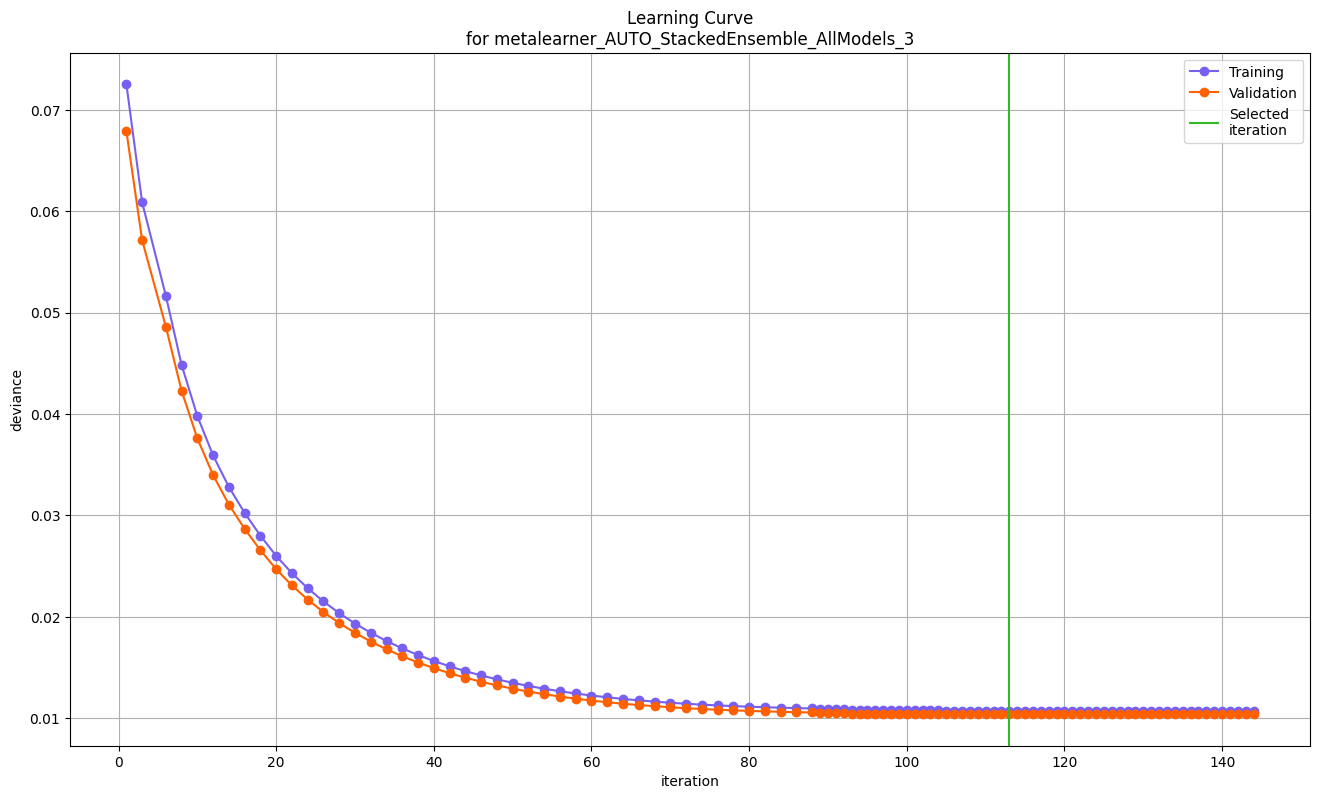

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

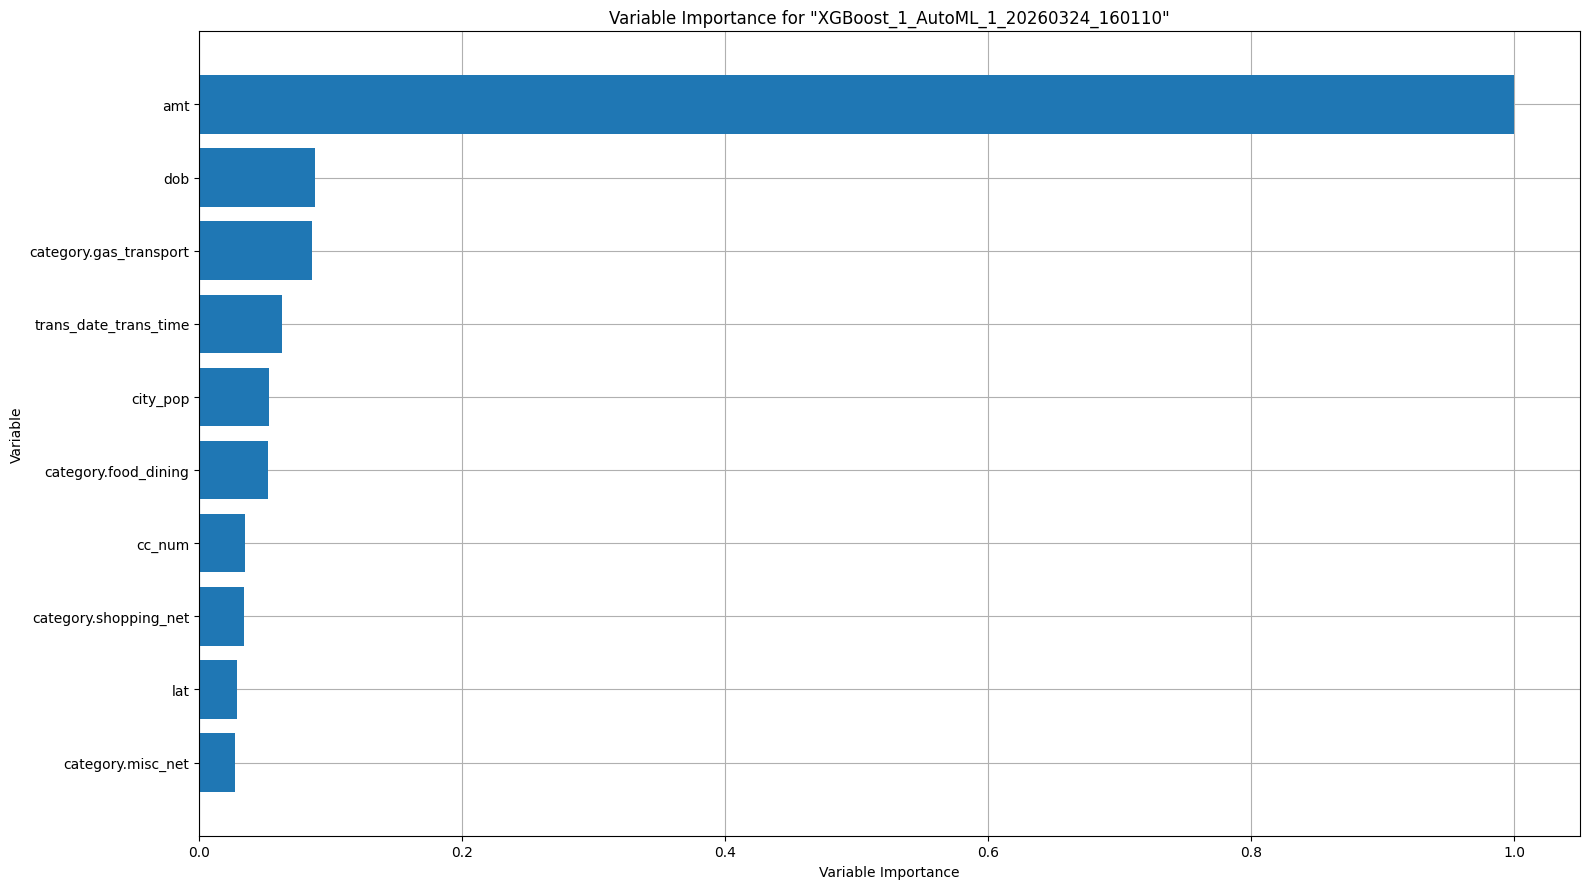

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

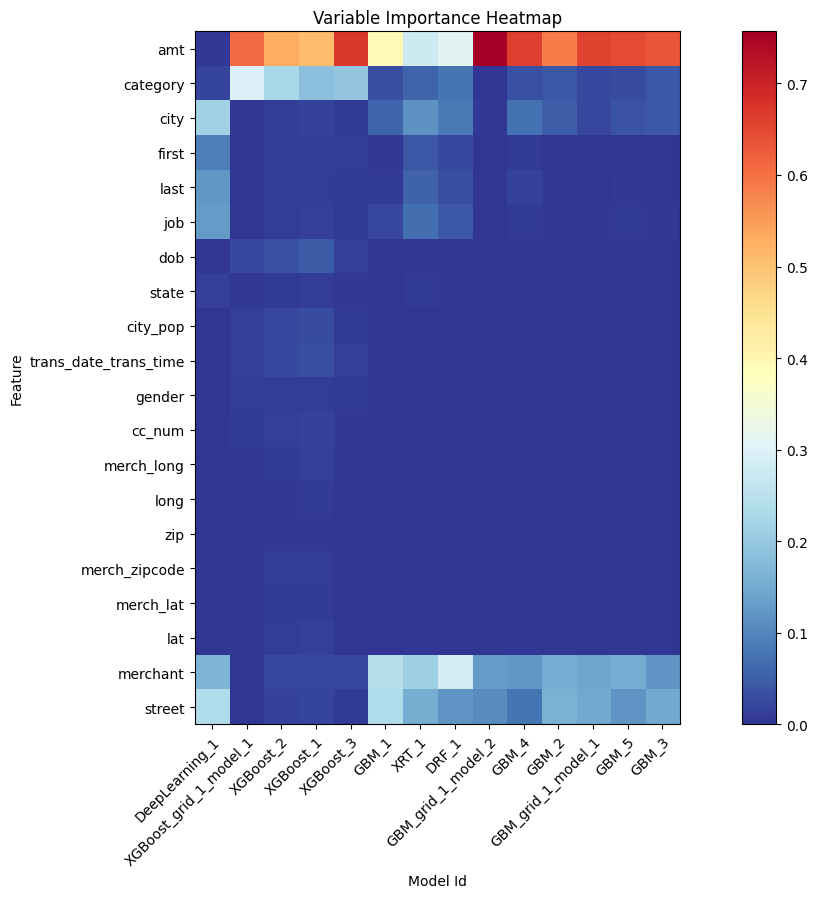

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

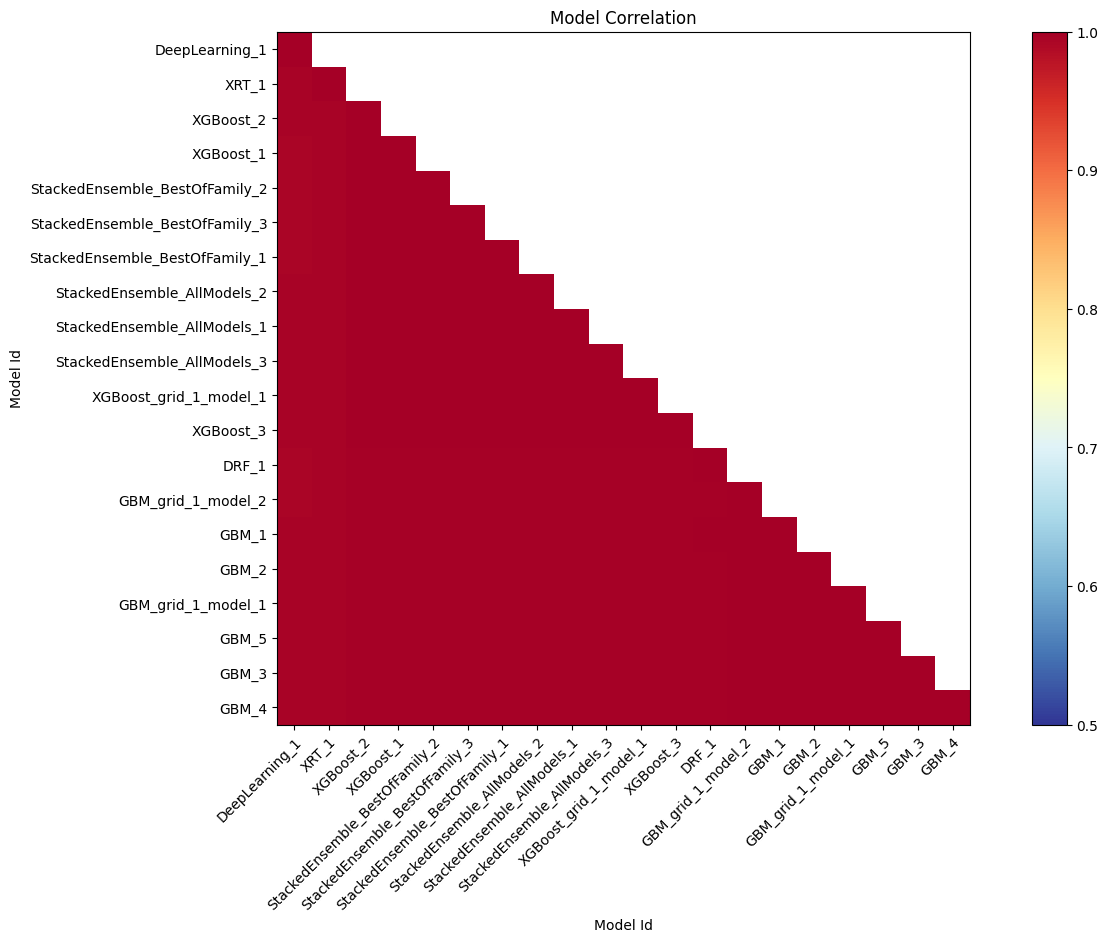

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

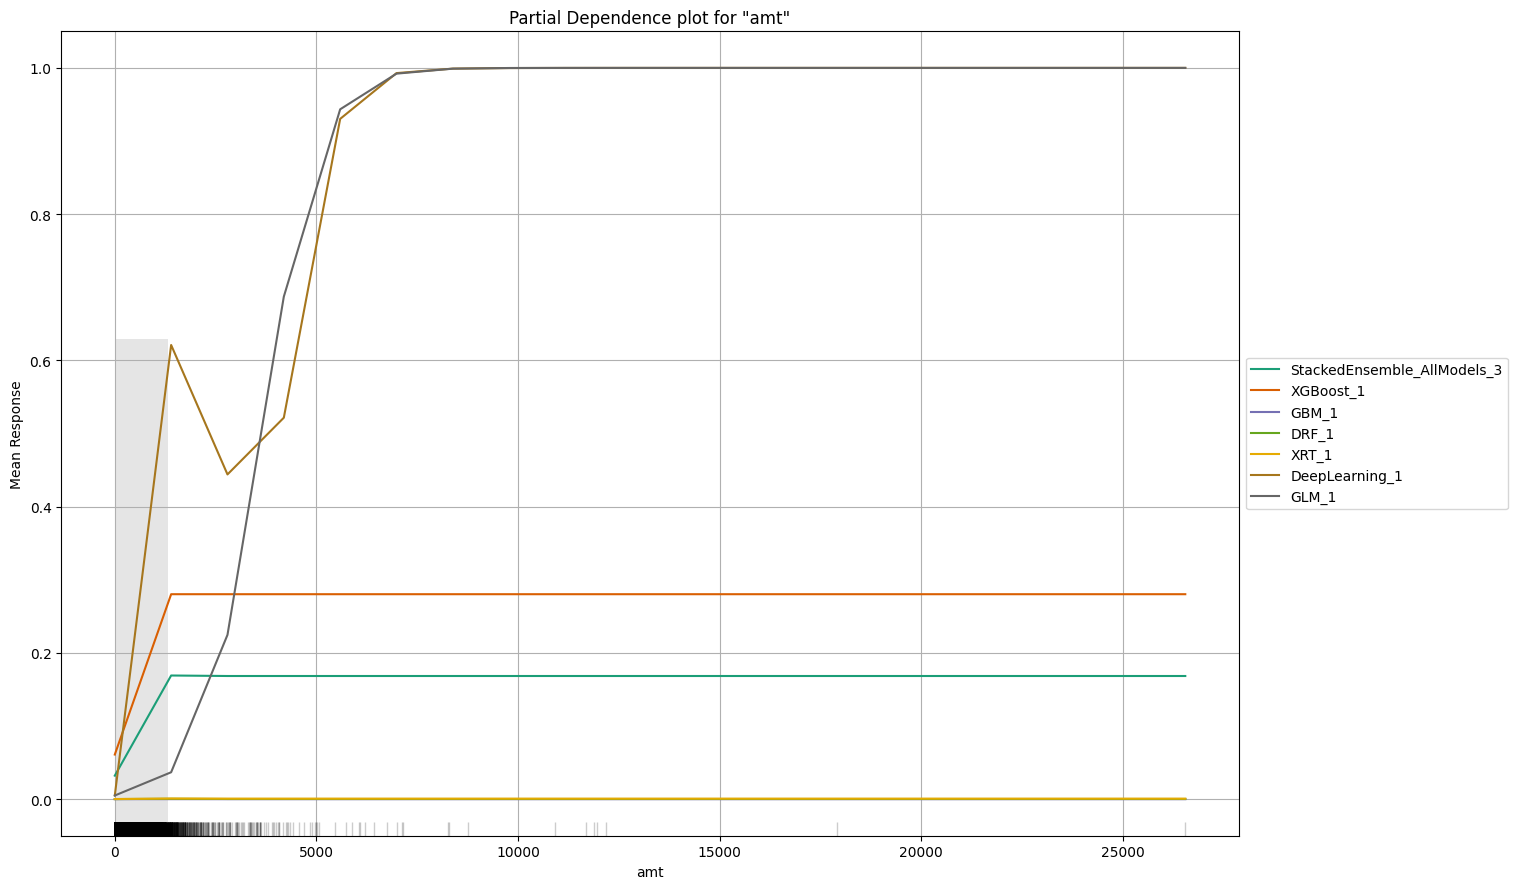

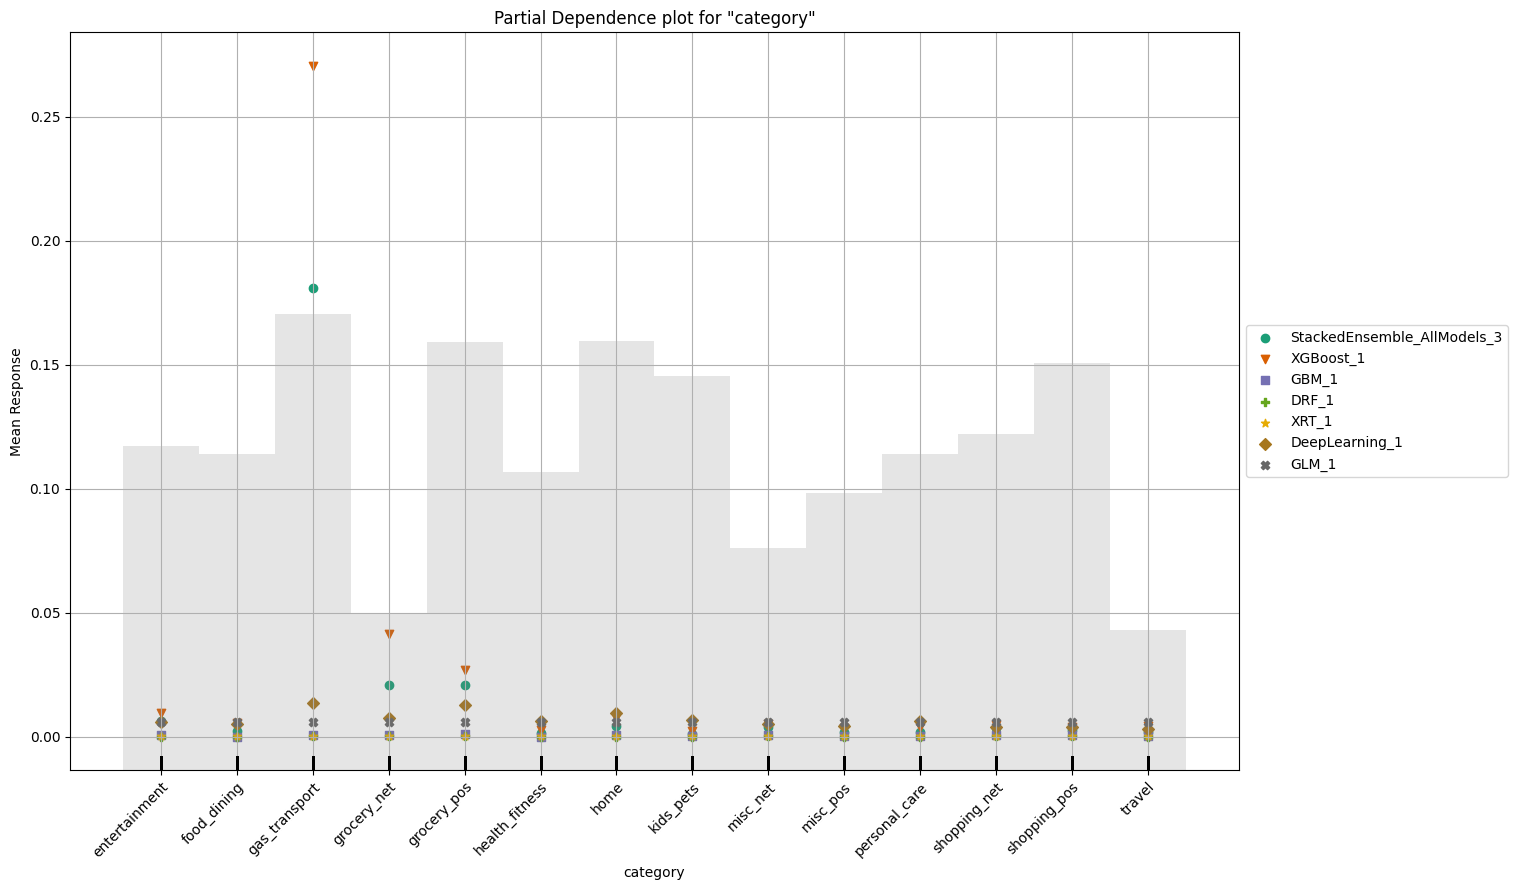

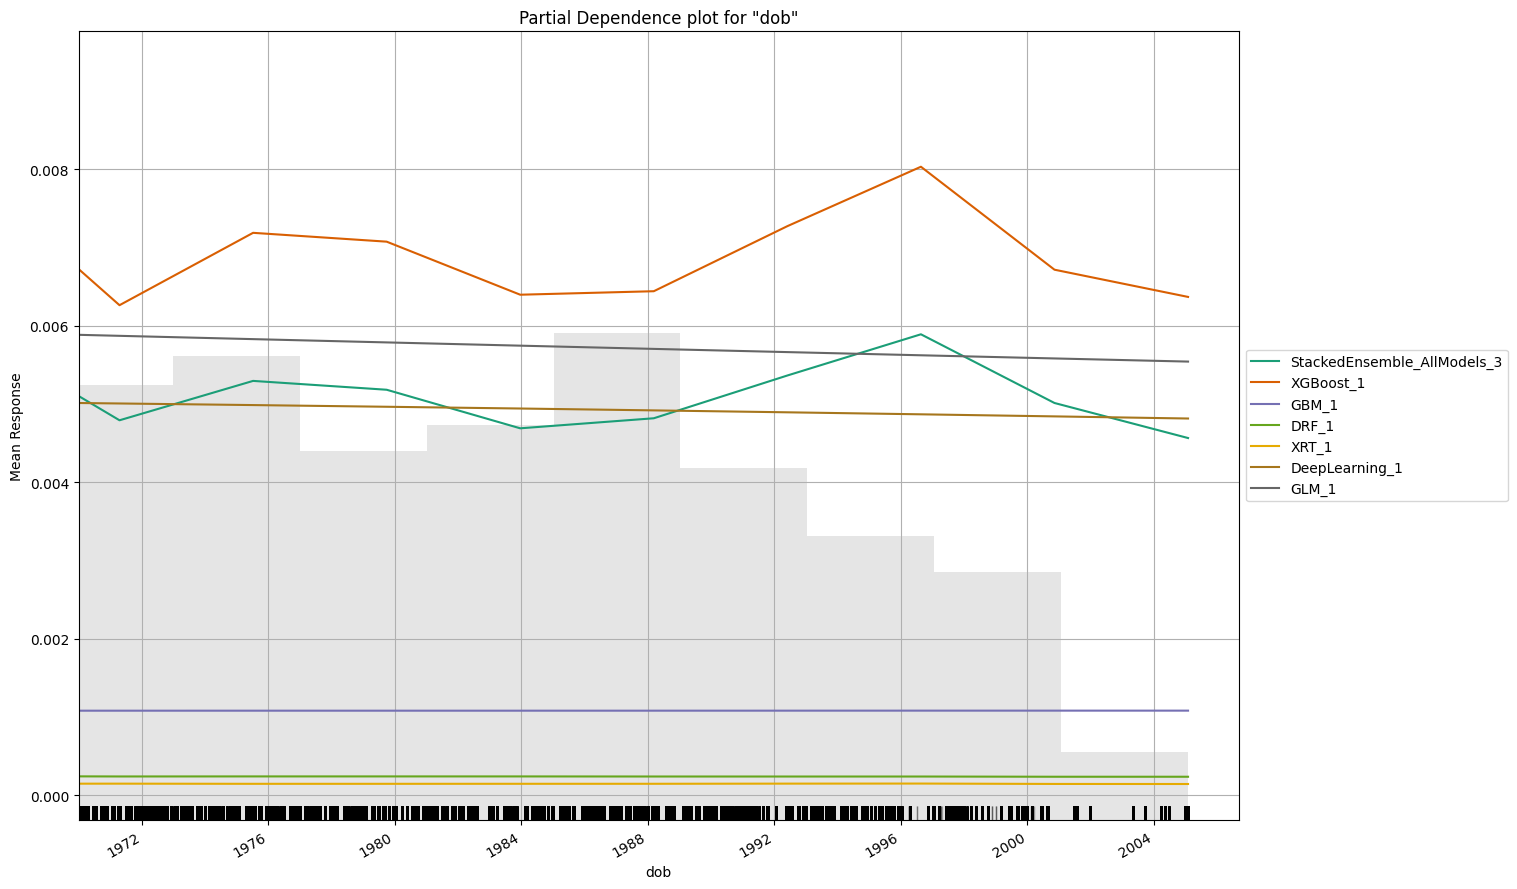

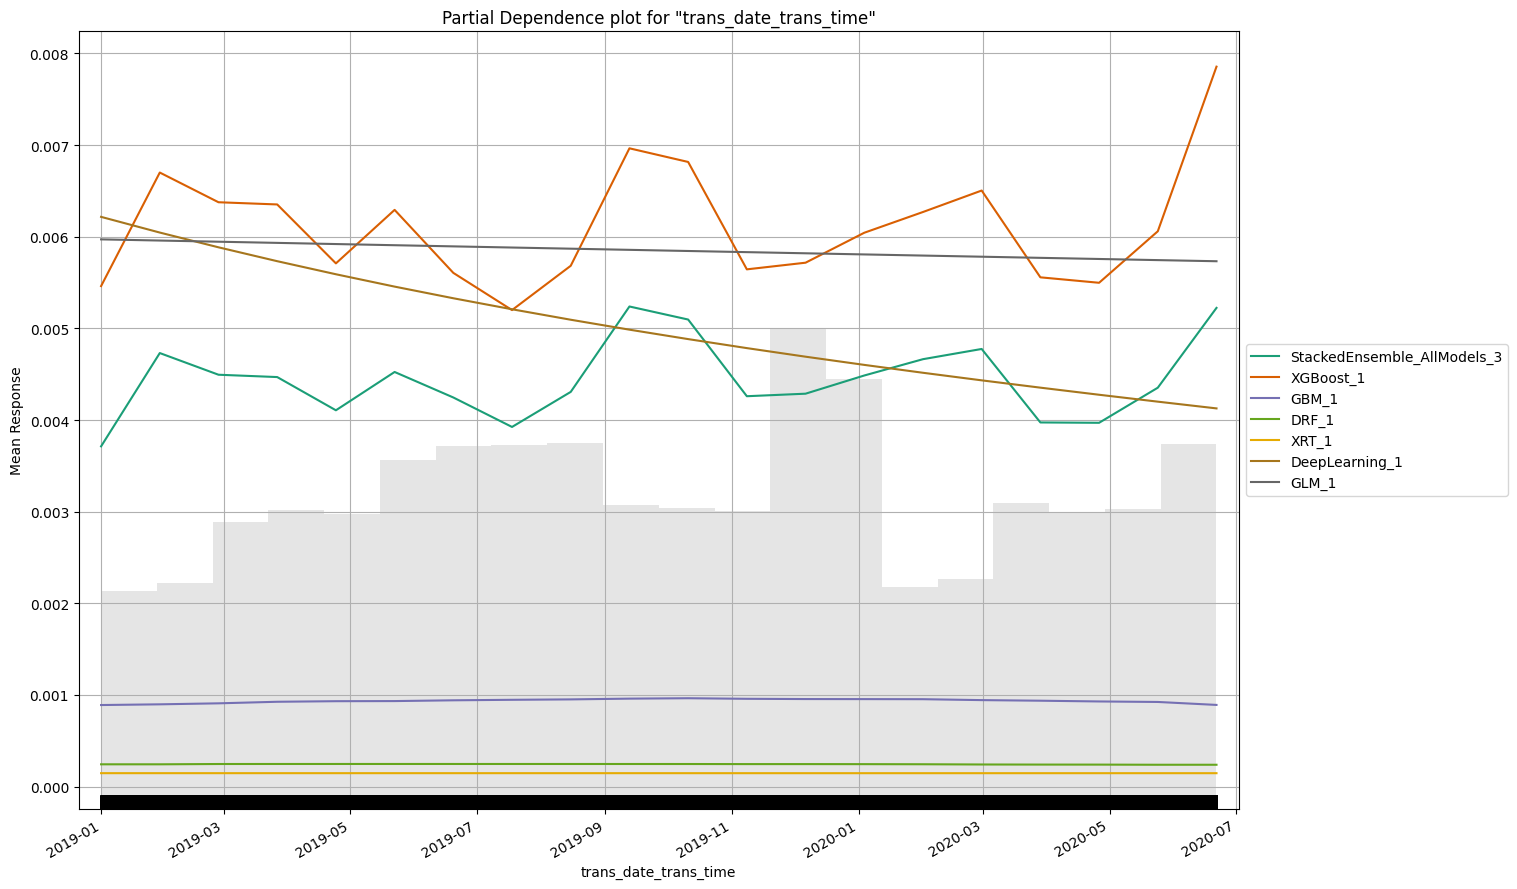

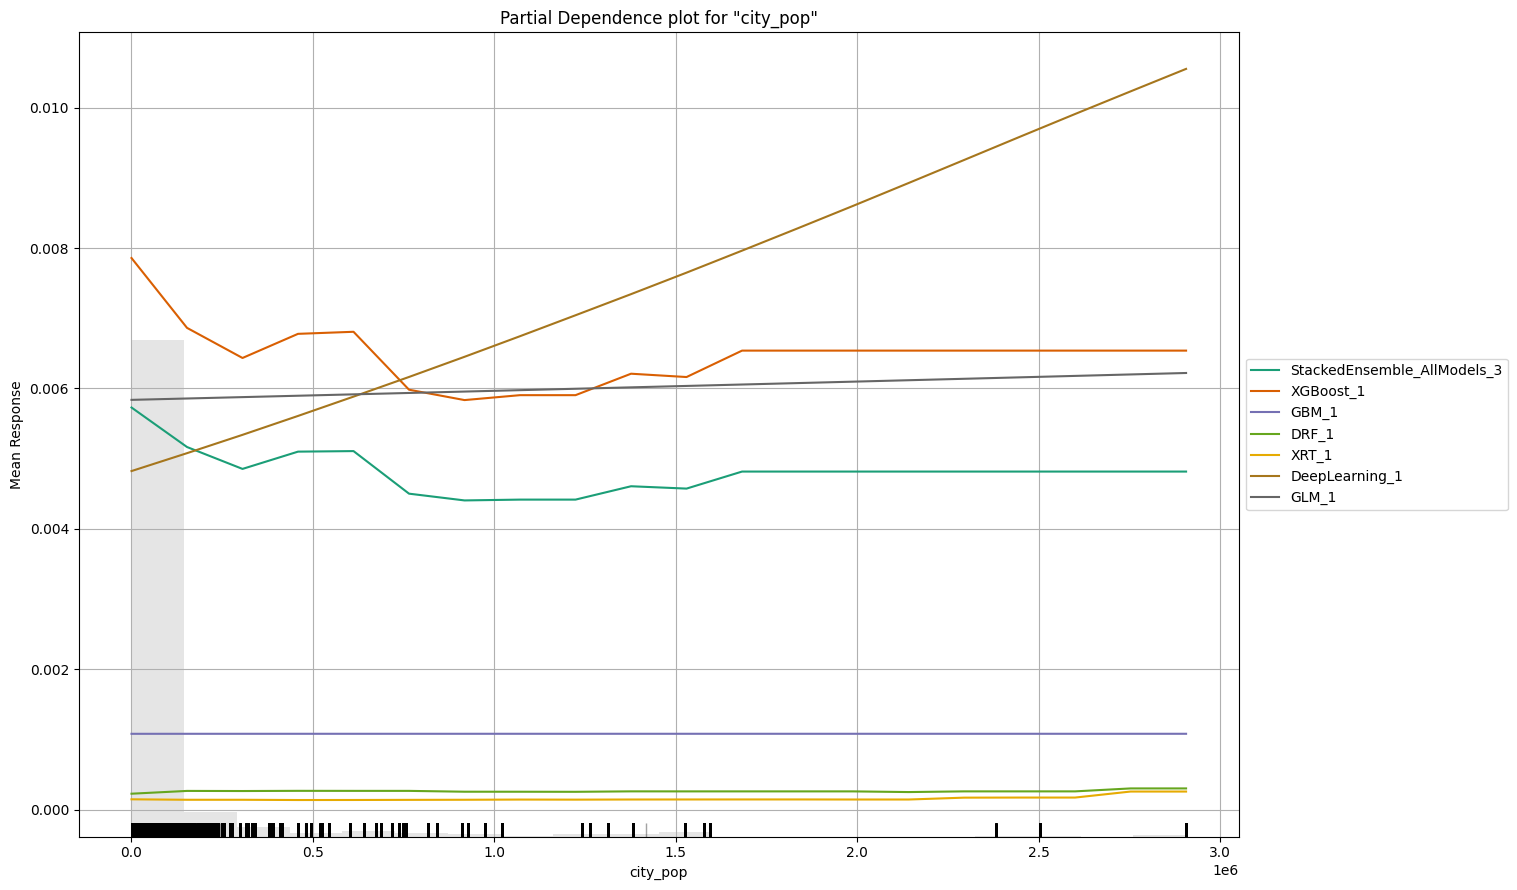

In [3]:
# 한 줄로 모든 설명 시각화 생성
test.names = [str(col) for col in test.names]
explanations = aml.explain(test, exclude_explanations=["shap_summary"])

---
## 2. 개별 시각화

필요한 시각화만 선택적으로 생성할 수도 있습니다.

### 2-1. 변수 중요도 히트맵

여러 모델에 걸쳐 어떤 변수가 공통적으로 중요한지 한눈에 파악합니다.

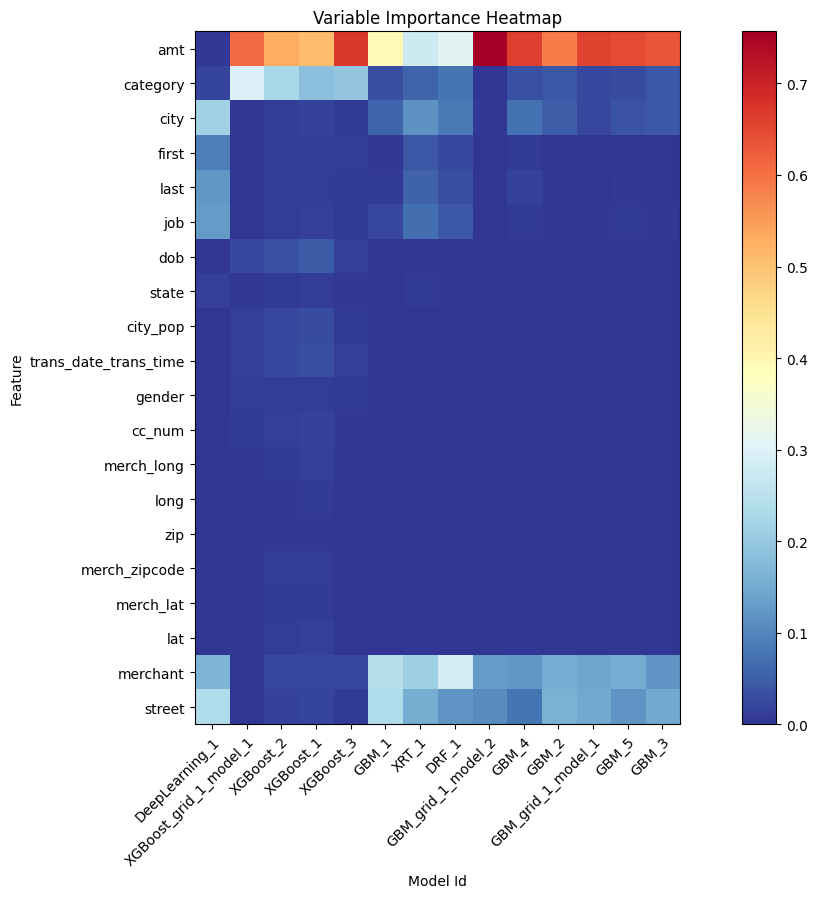

In [4]:
# 변수 중요도 히트맵 (다중 모델 비교)
aml.varimp_heatmap()

### 2-2. 모델 간 상관관계

모델들의 예측이 얼마나 유사한지 보여줍니다. 상관이 낮은 모델들을 앙상블하면 성능이 더 올라갑니다.

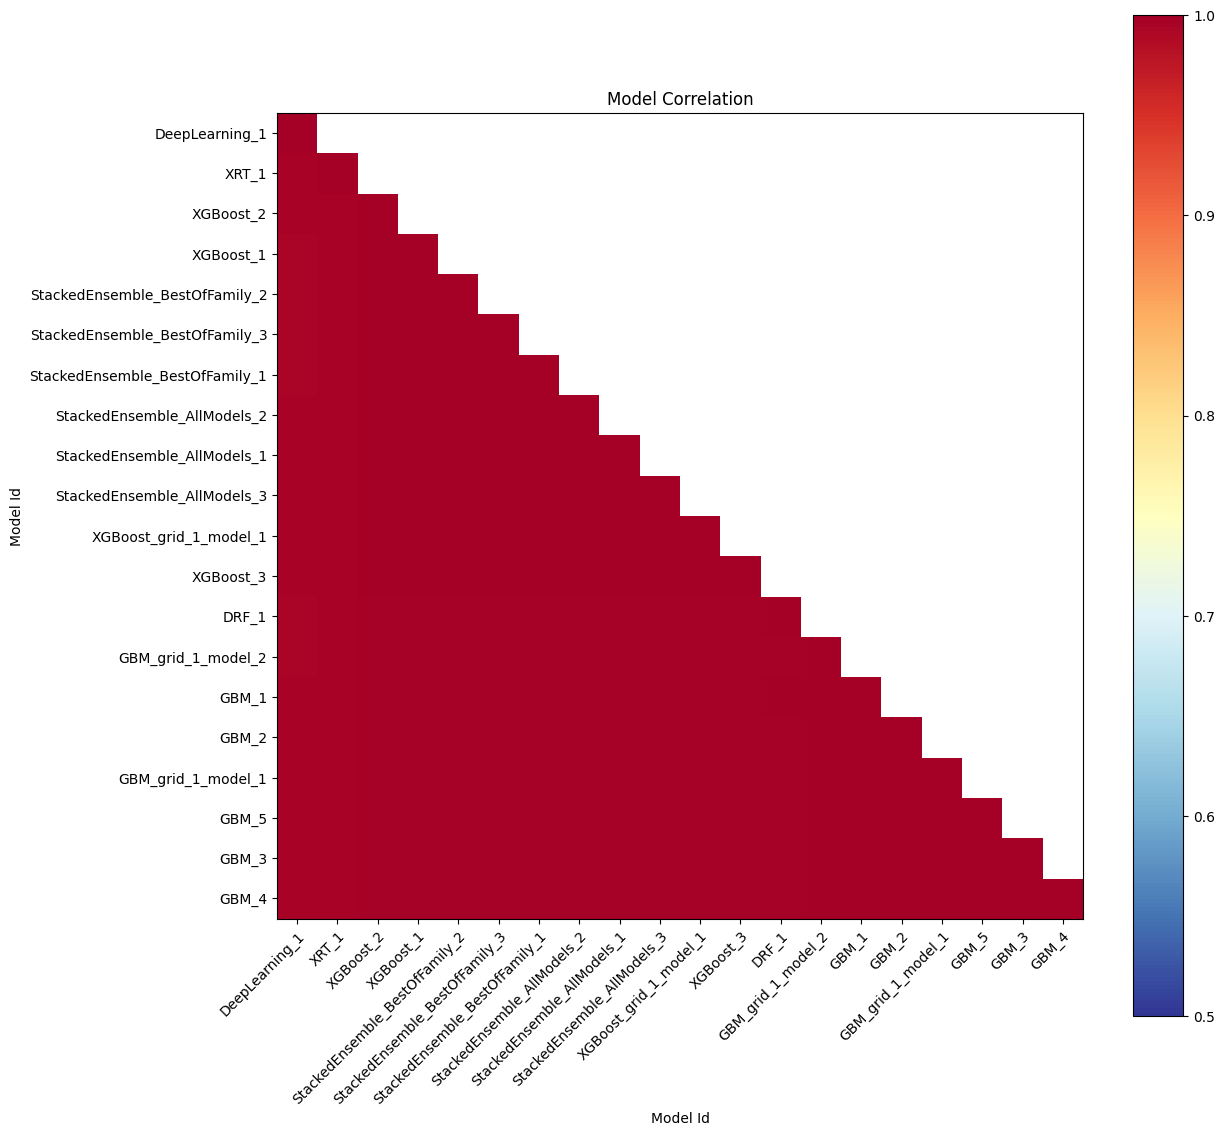

In [5]:
# 모델 상관관계 히트맵
aml.model_correlation_heatmap(test)

### 2-3. 리더 모델 상세 설명

# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## StackedEnsemble_AllModels_3_AutoML_1_20260324_160110

,0,1,Error,Rate
0,257616.0,157.0,0.0006,(157.0/257773.0)
1,274.0,1186.0,0.1877,(274.0/1460.0)
Total,257890.0,1343.0,0.0017,(431.0/259233.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

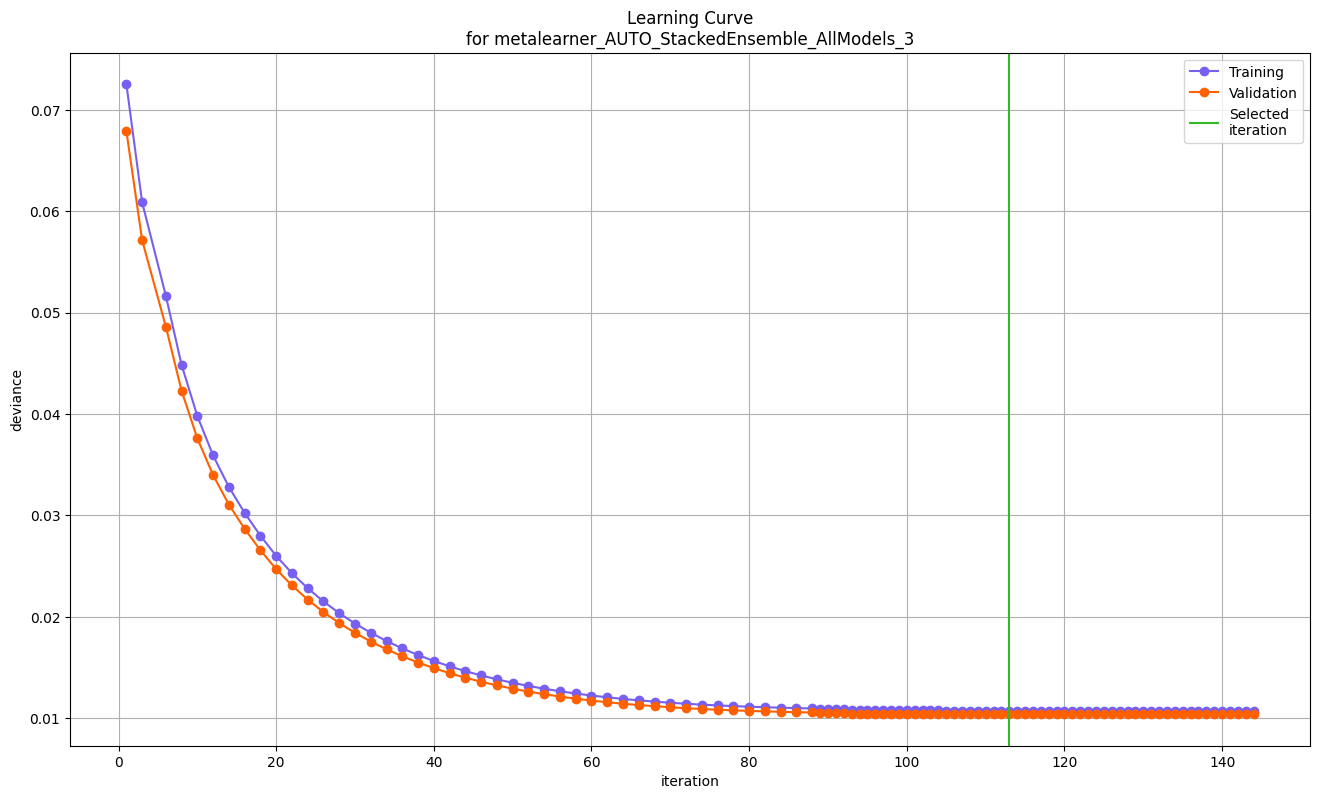

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

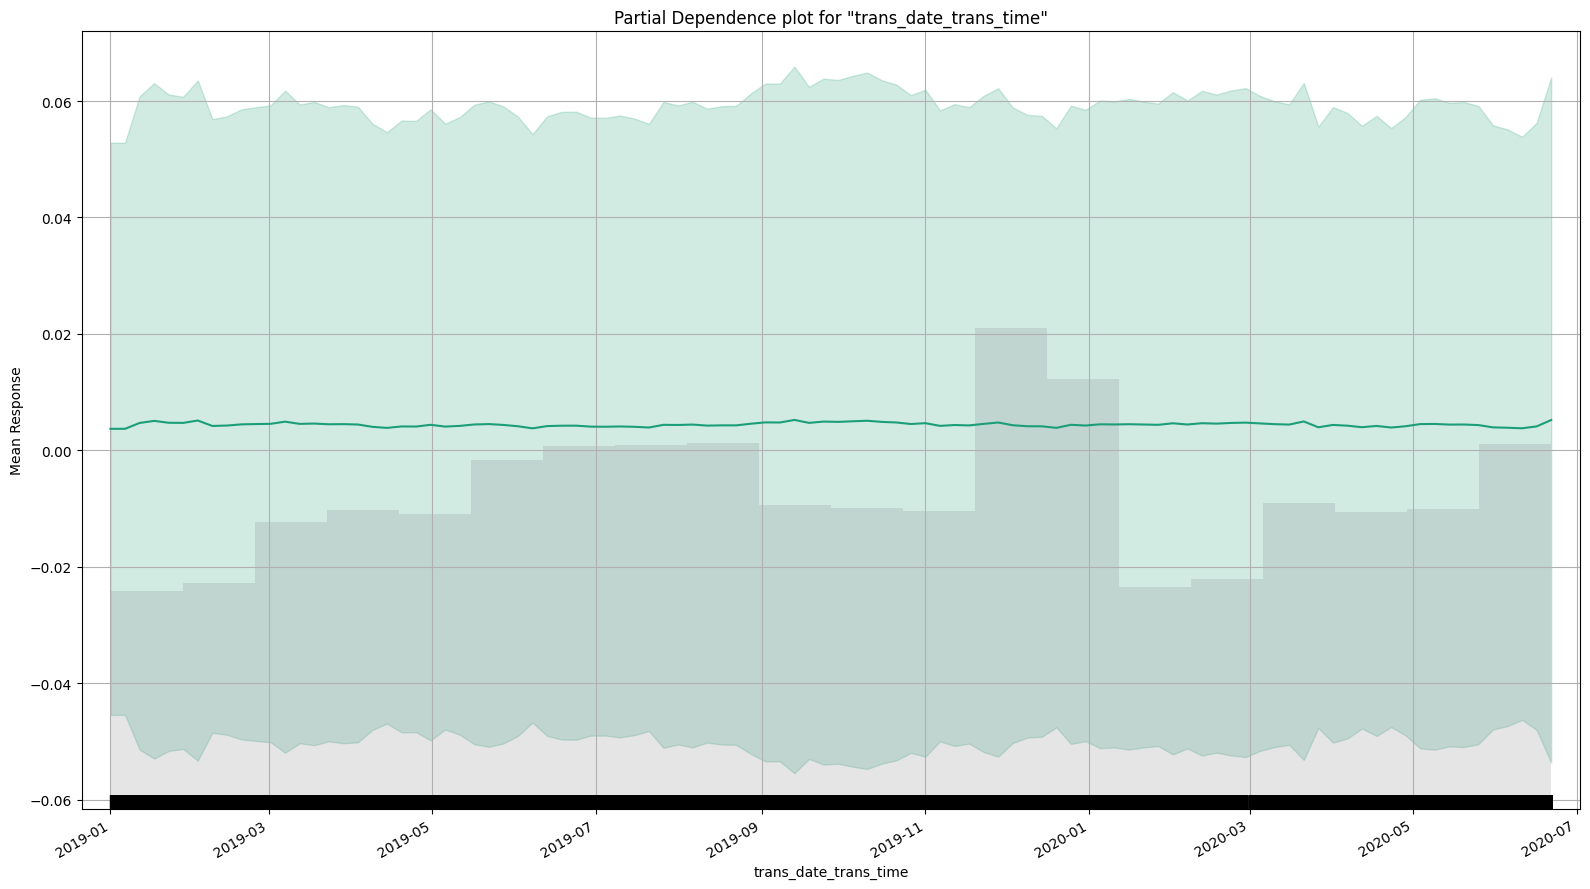

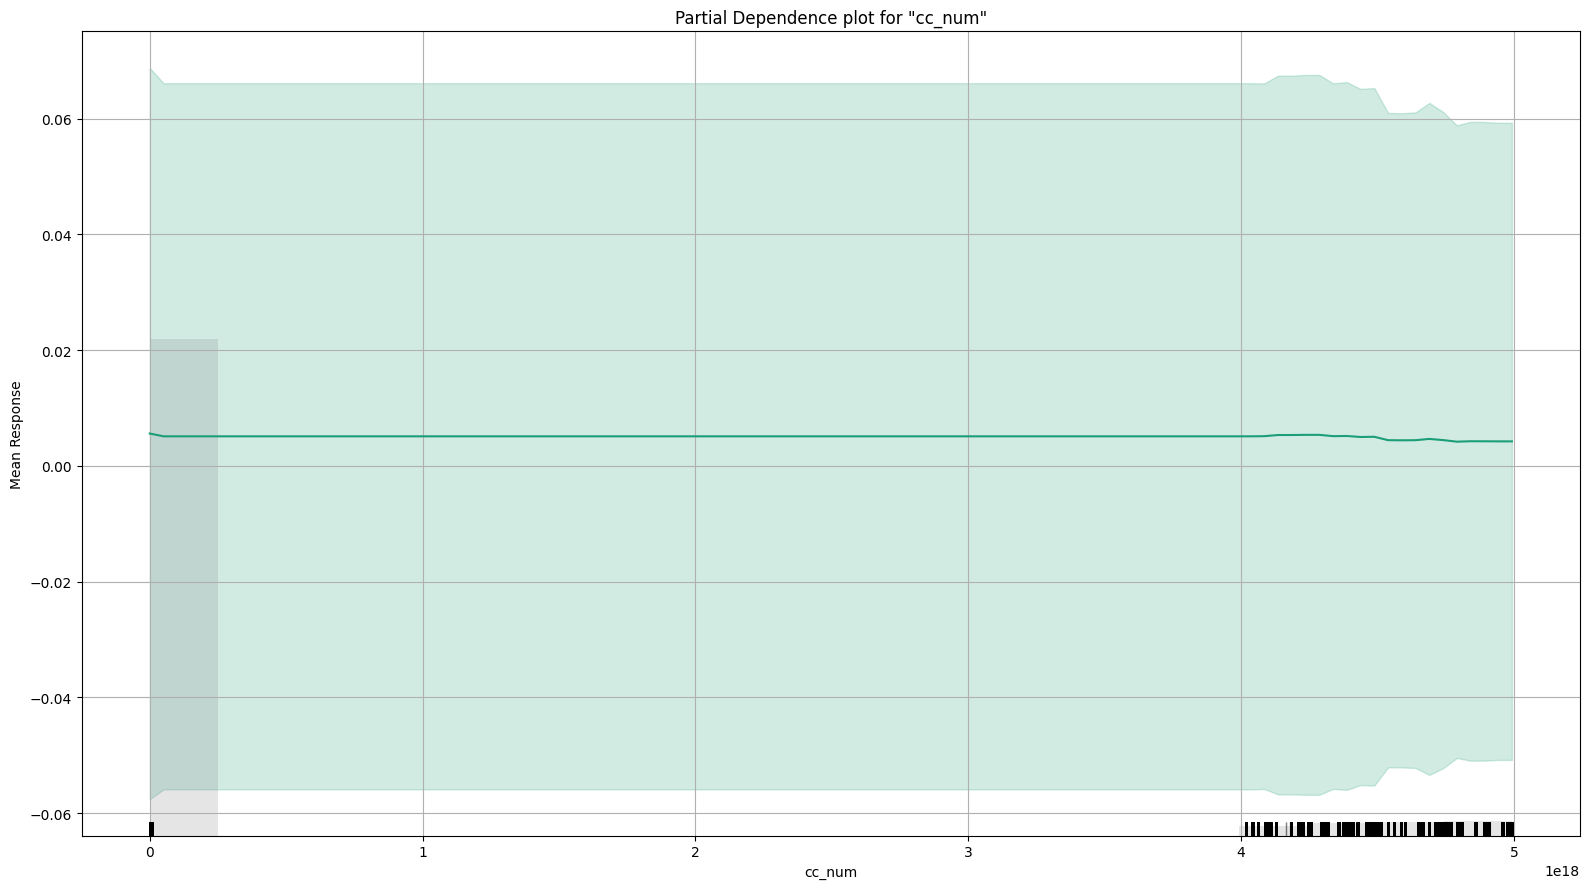

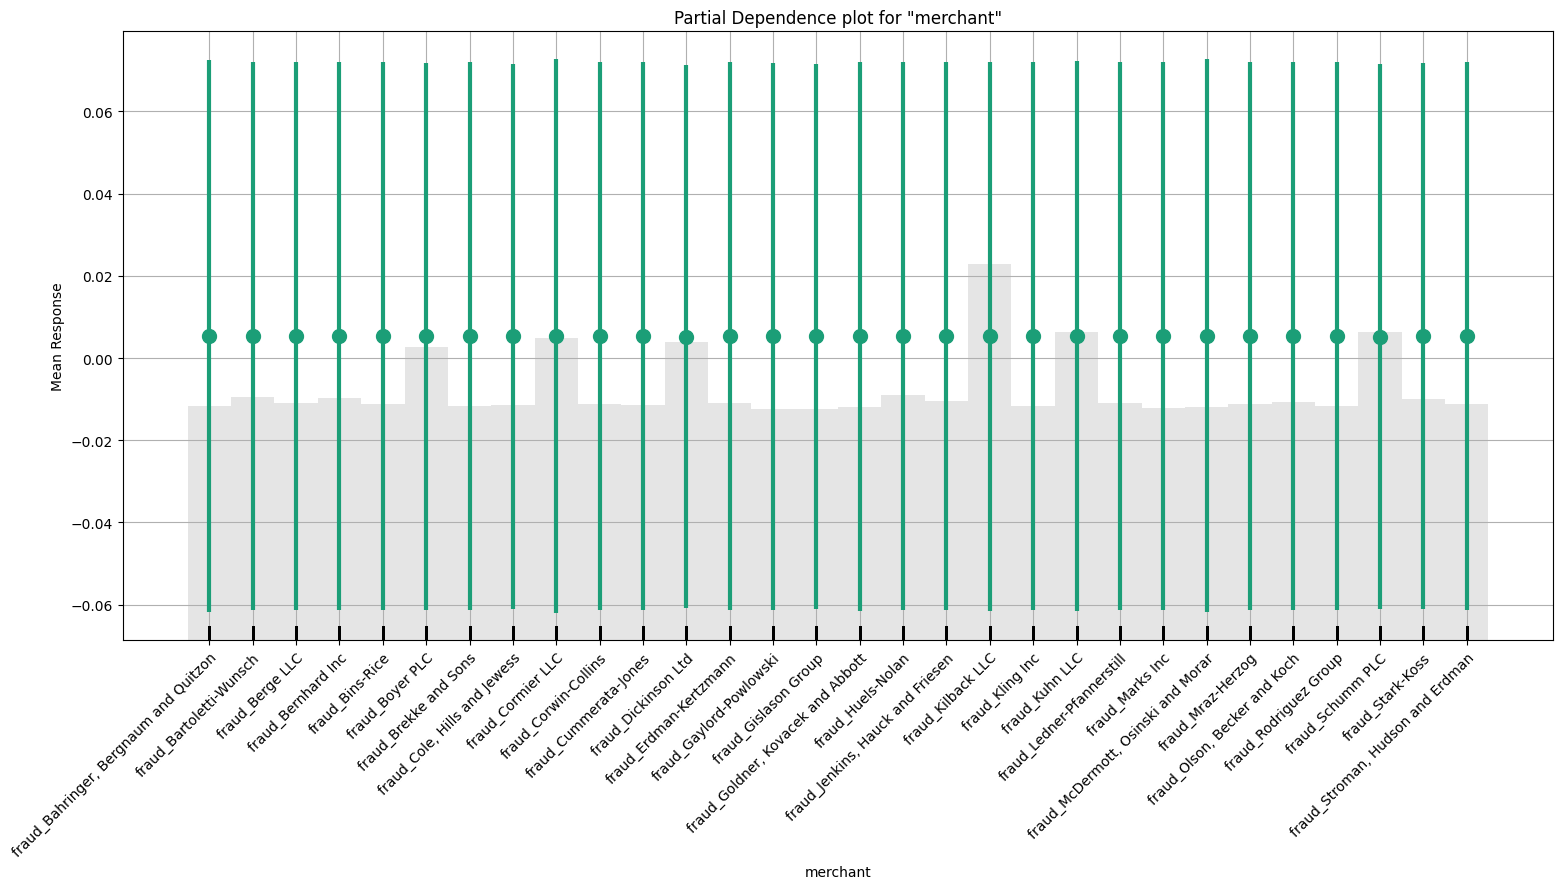

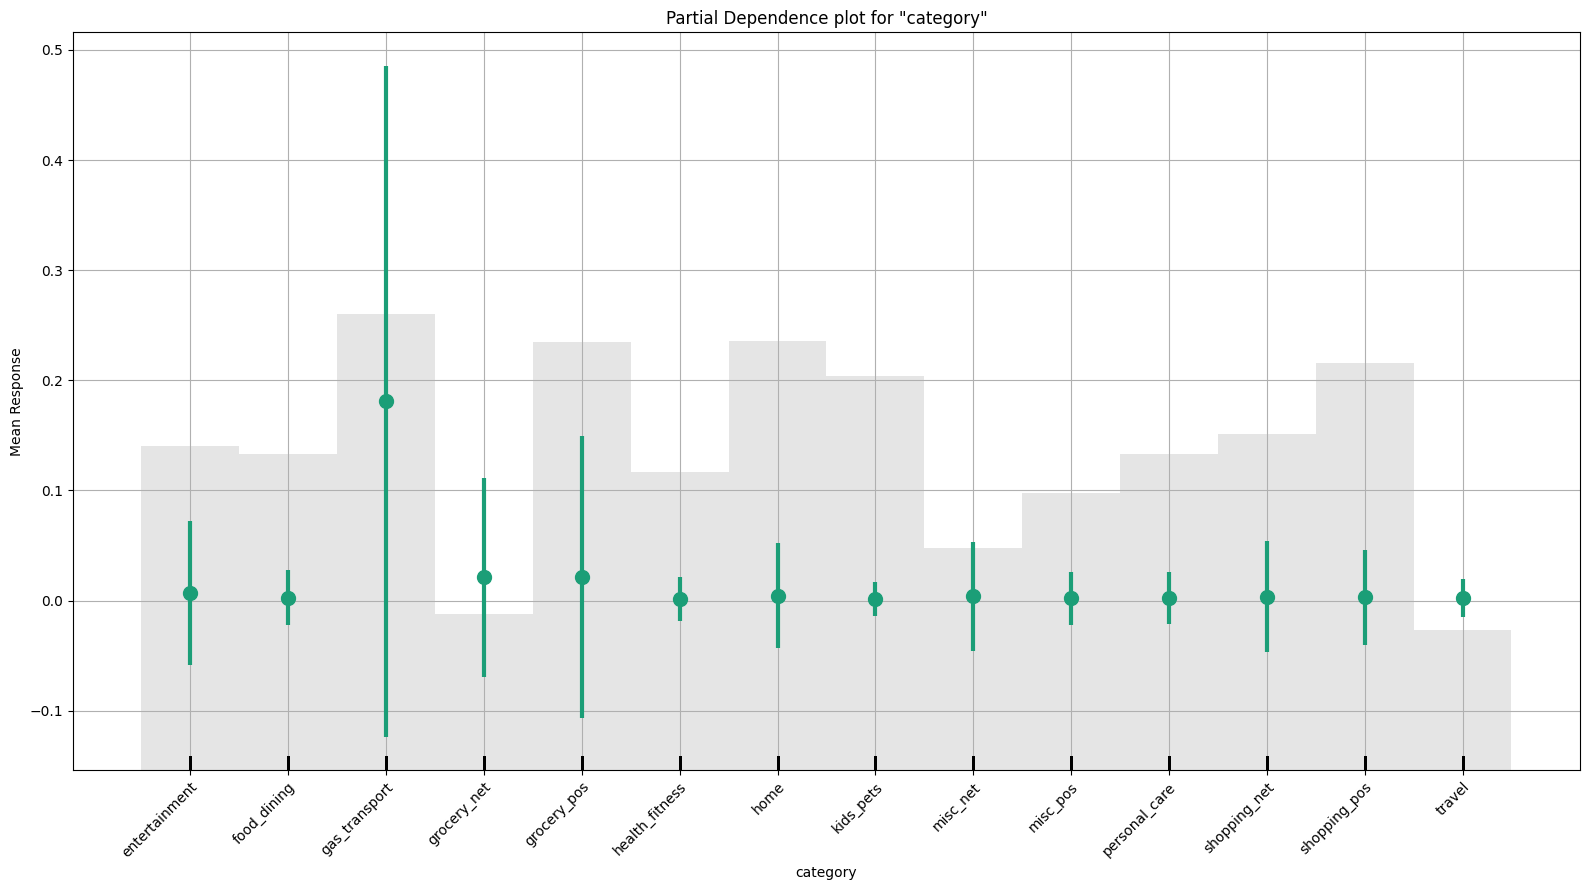

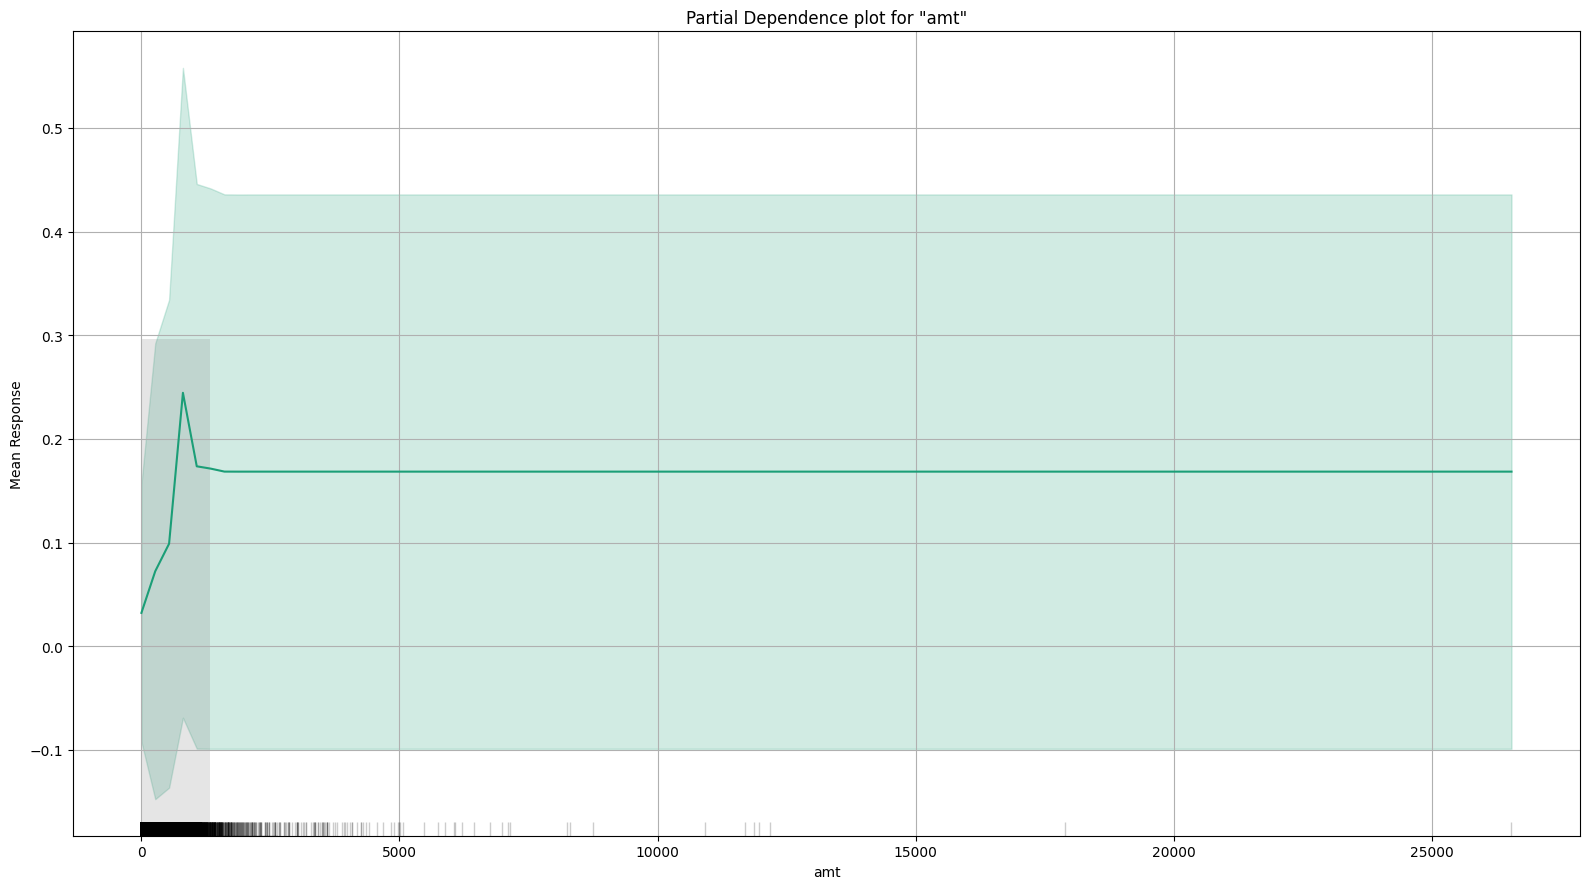

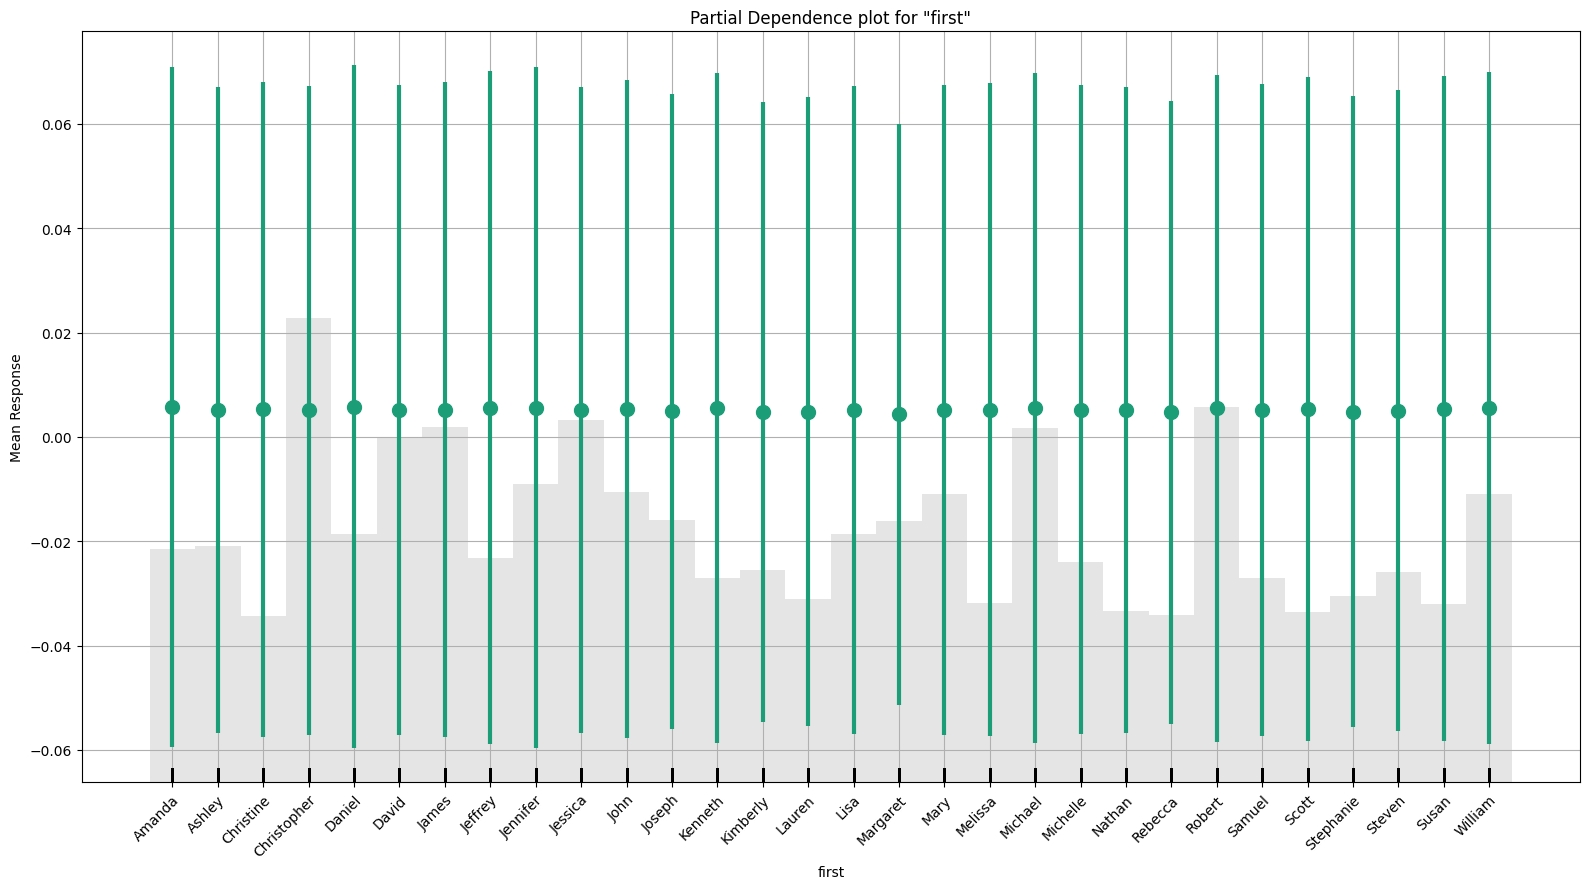

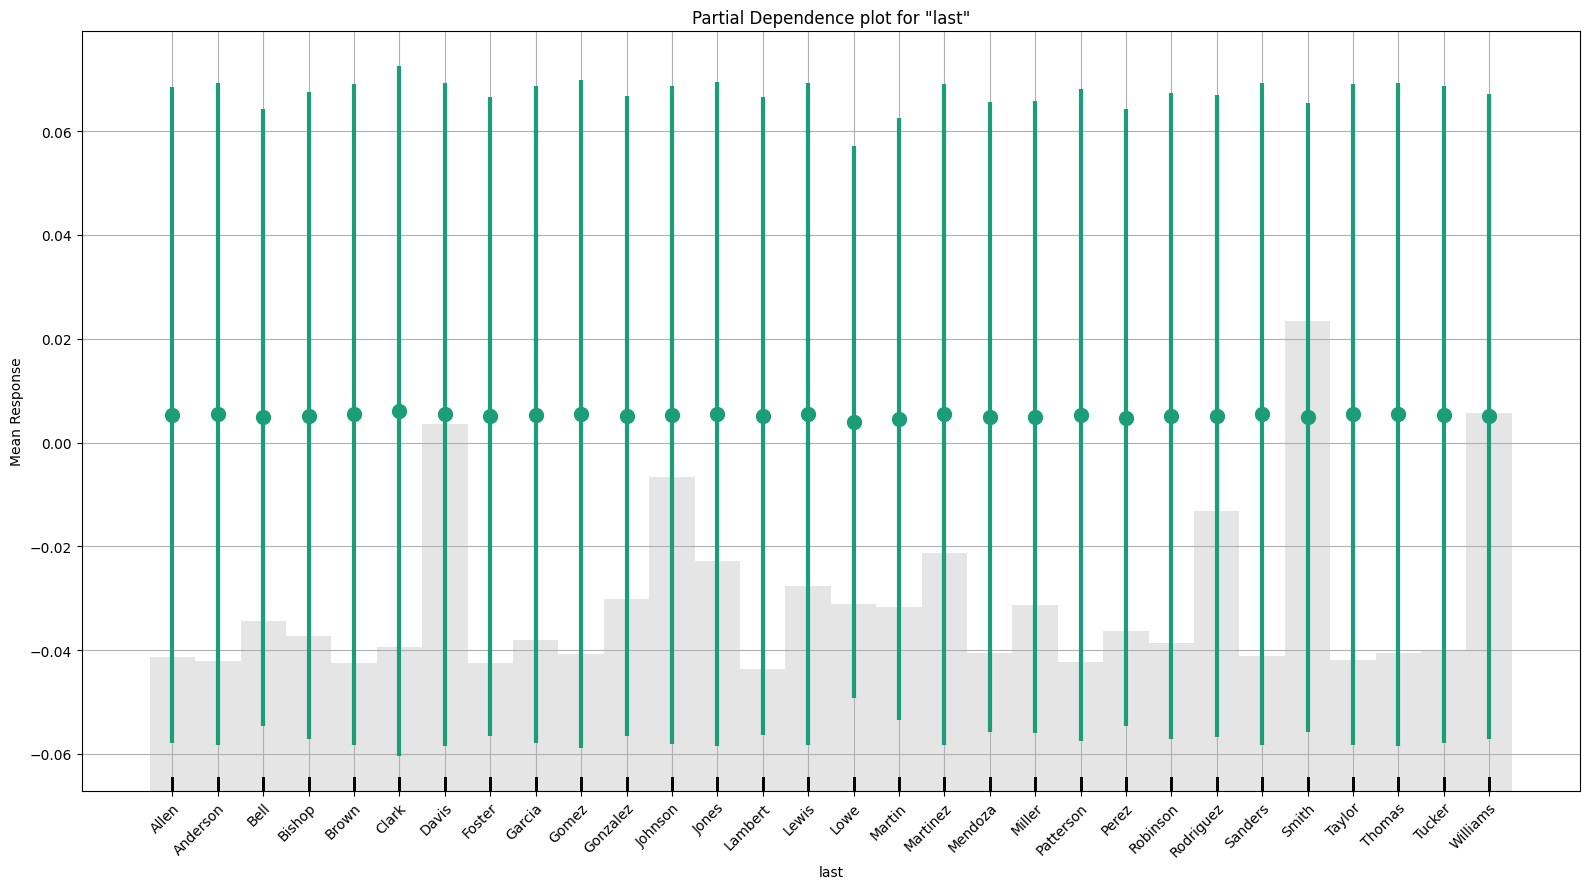

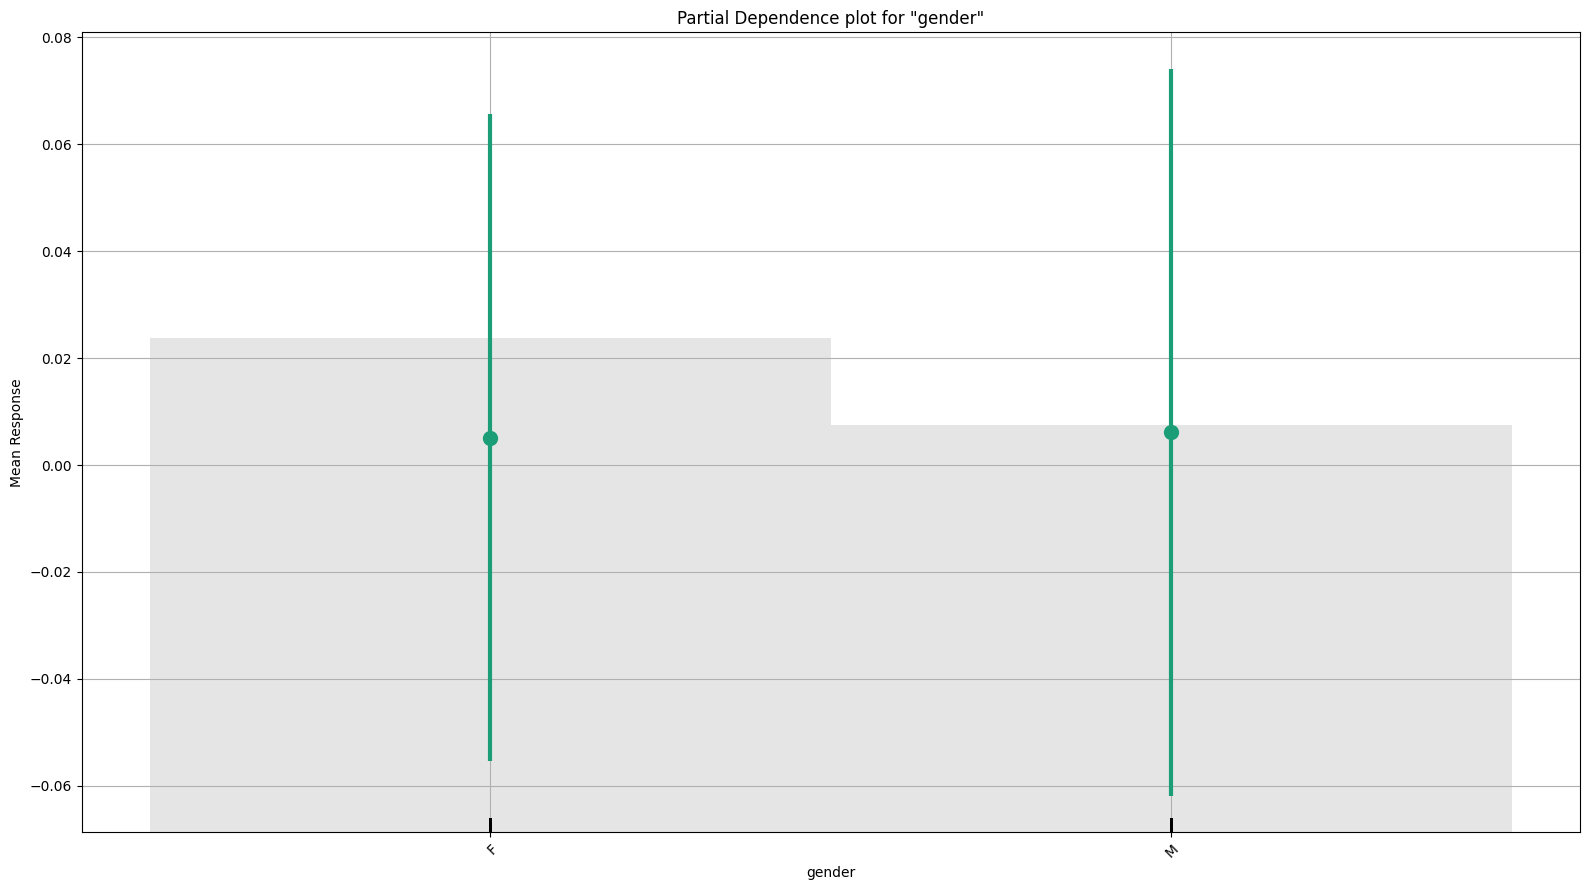

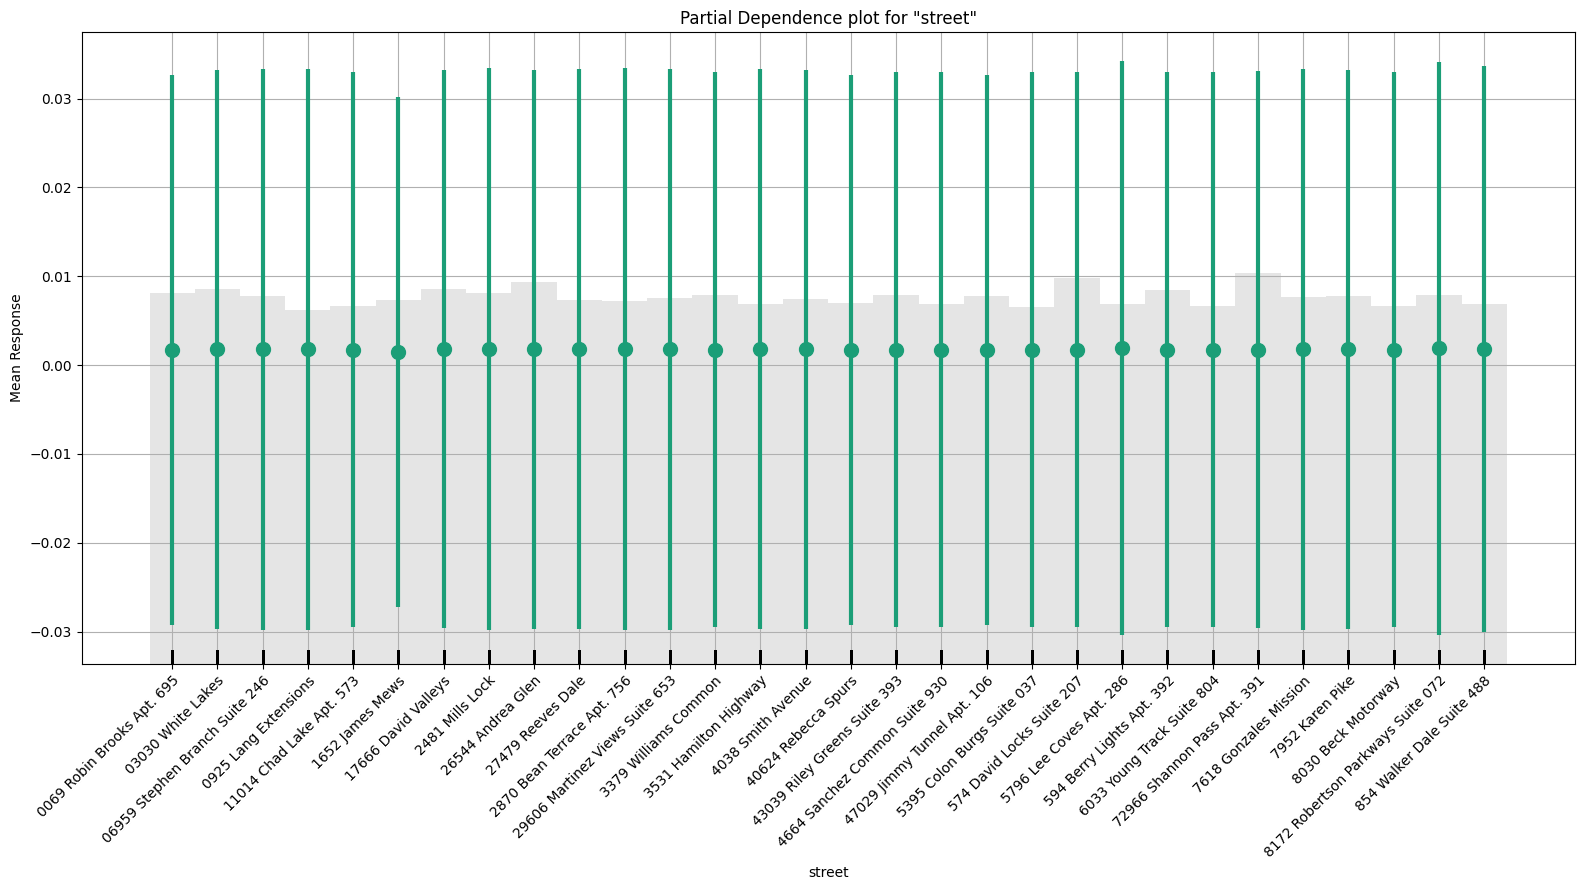

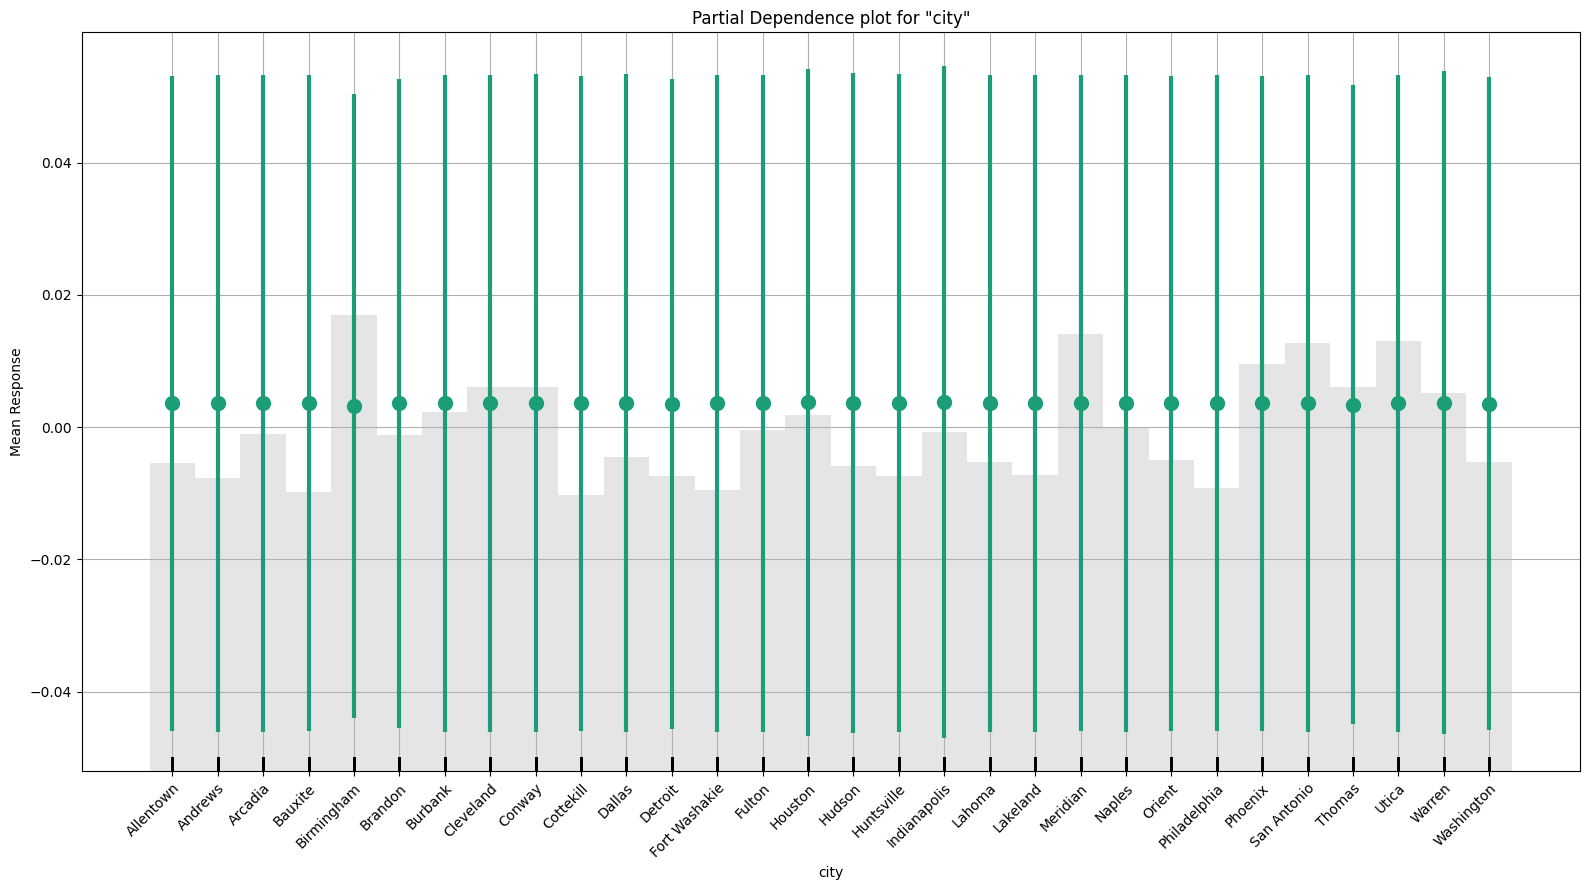

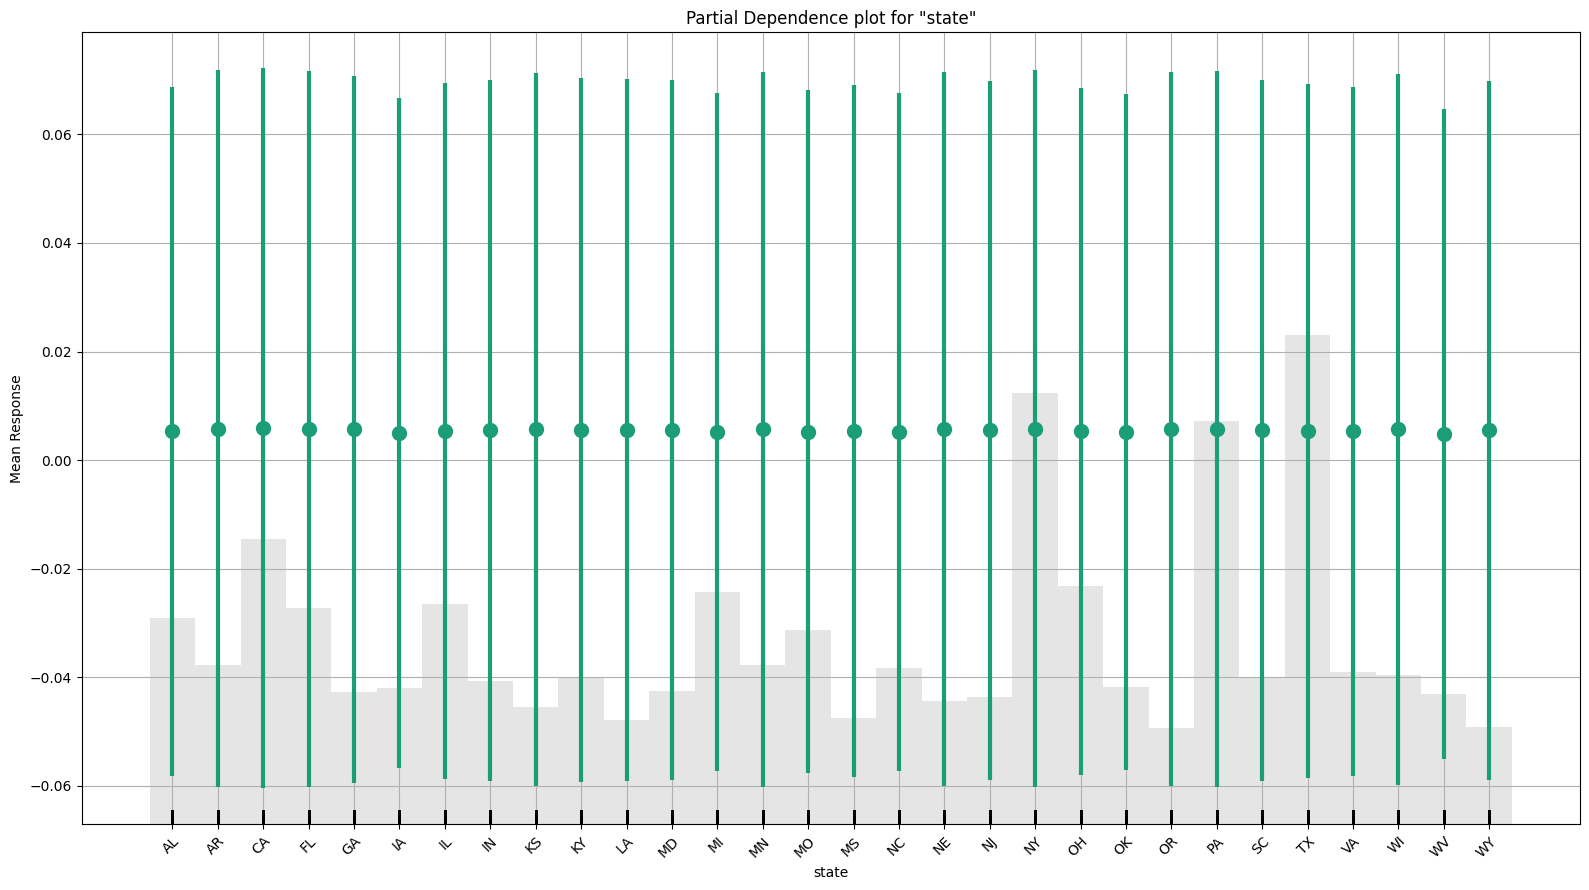

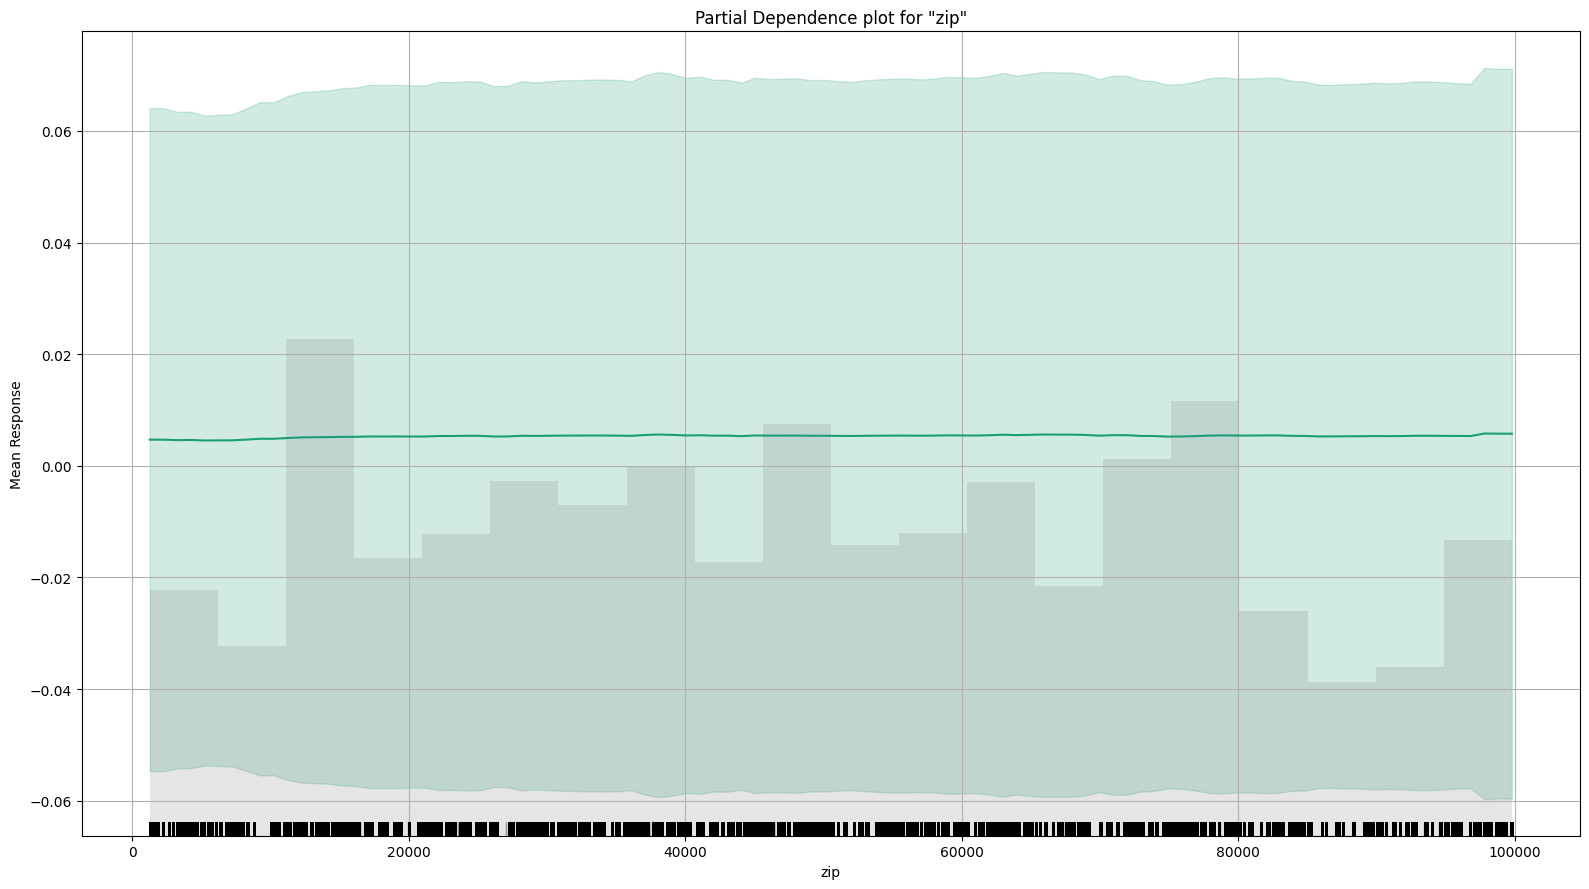

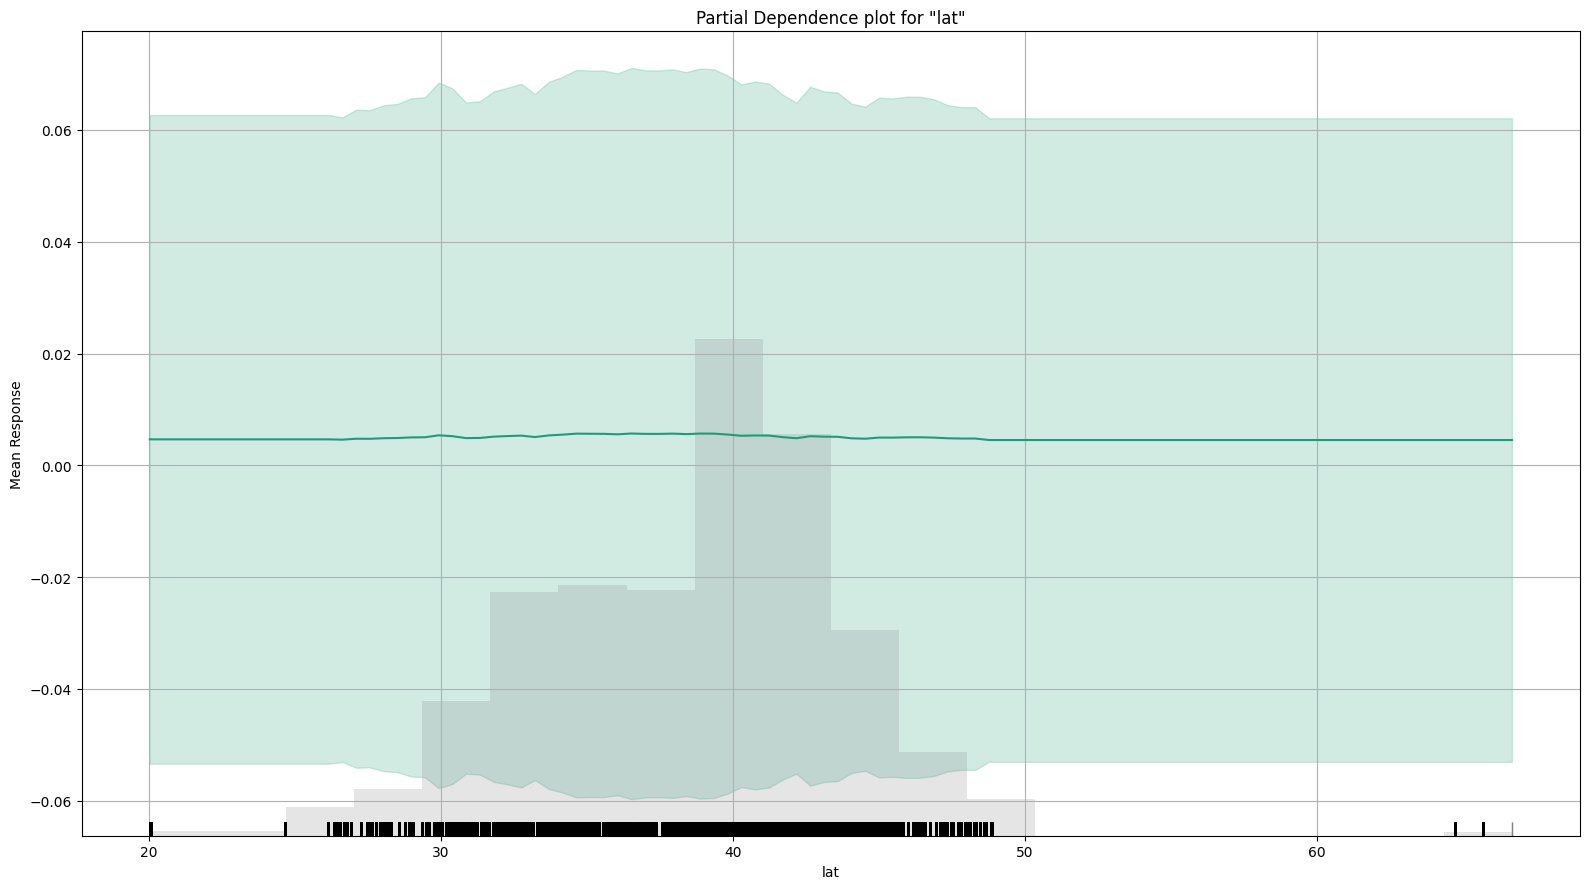

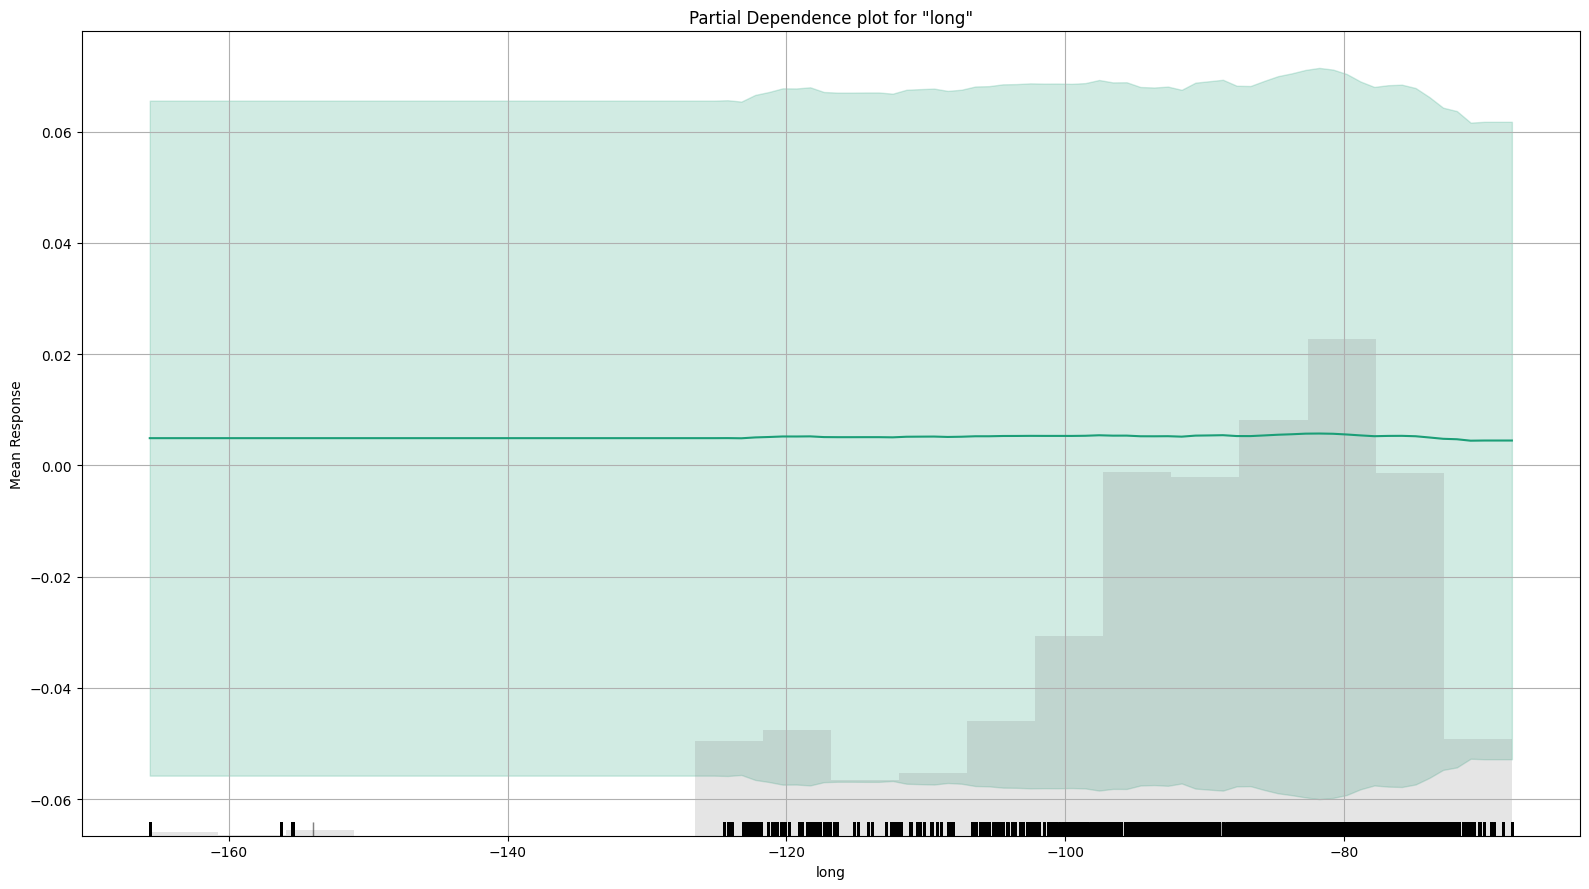

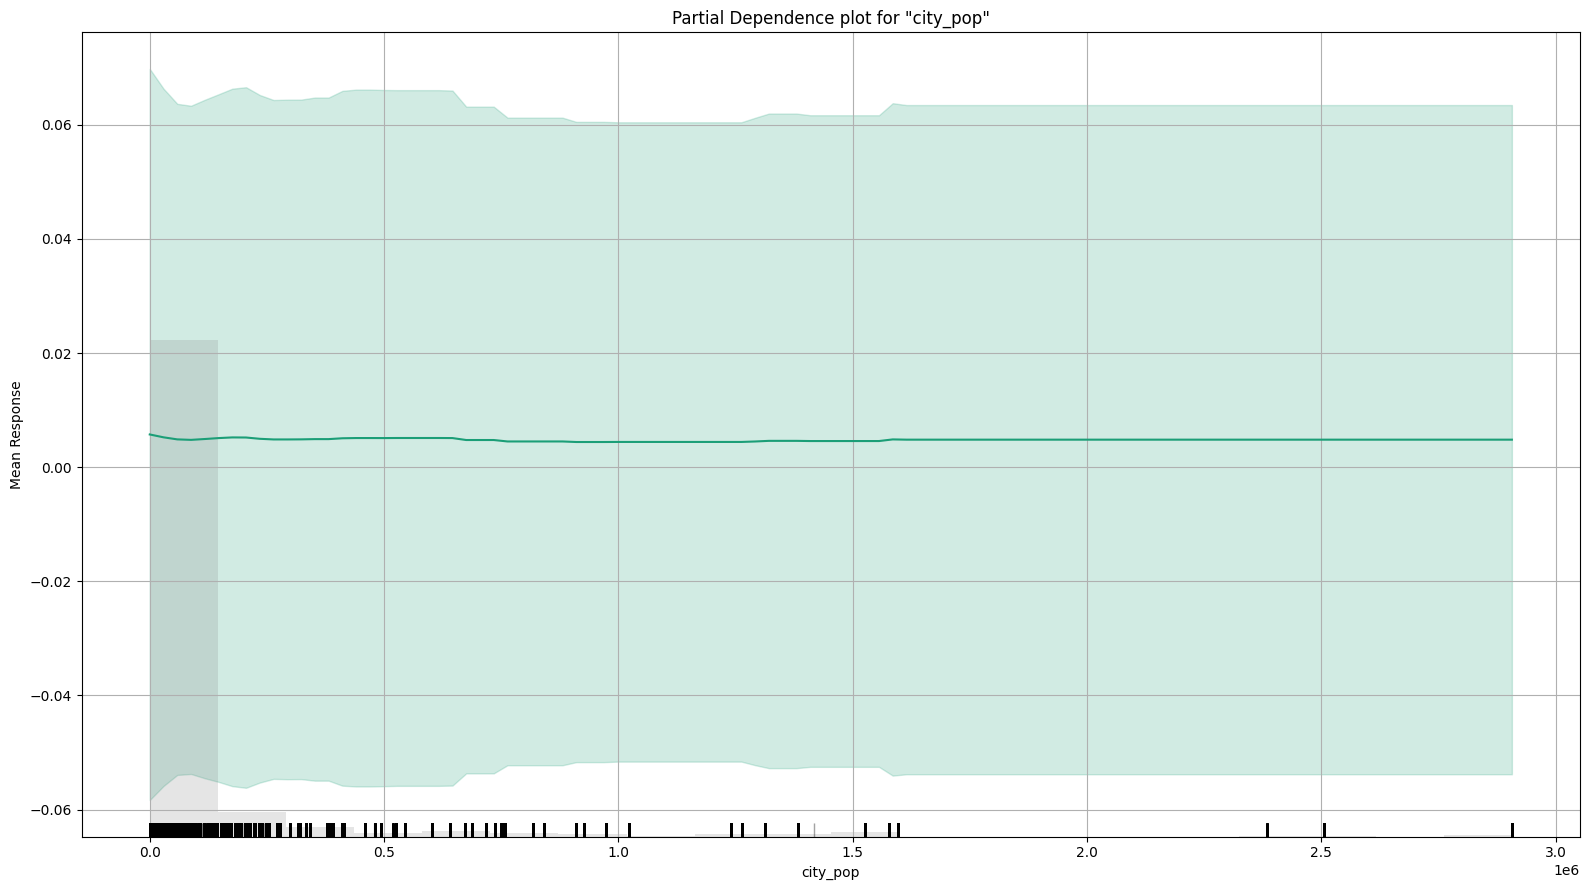

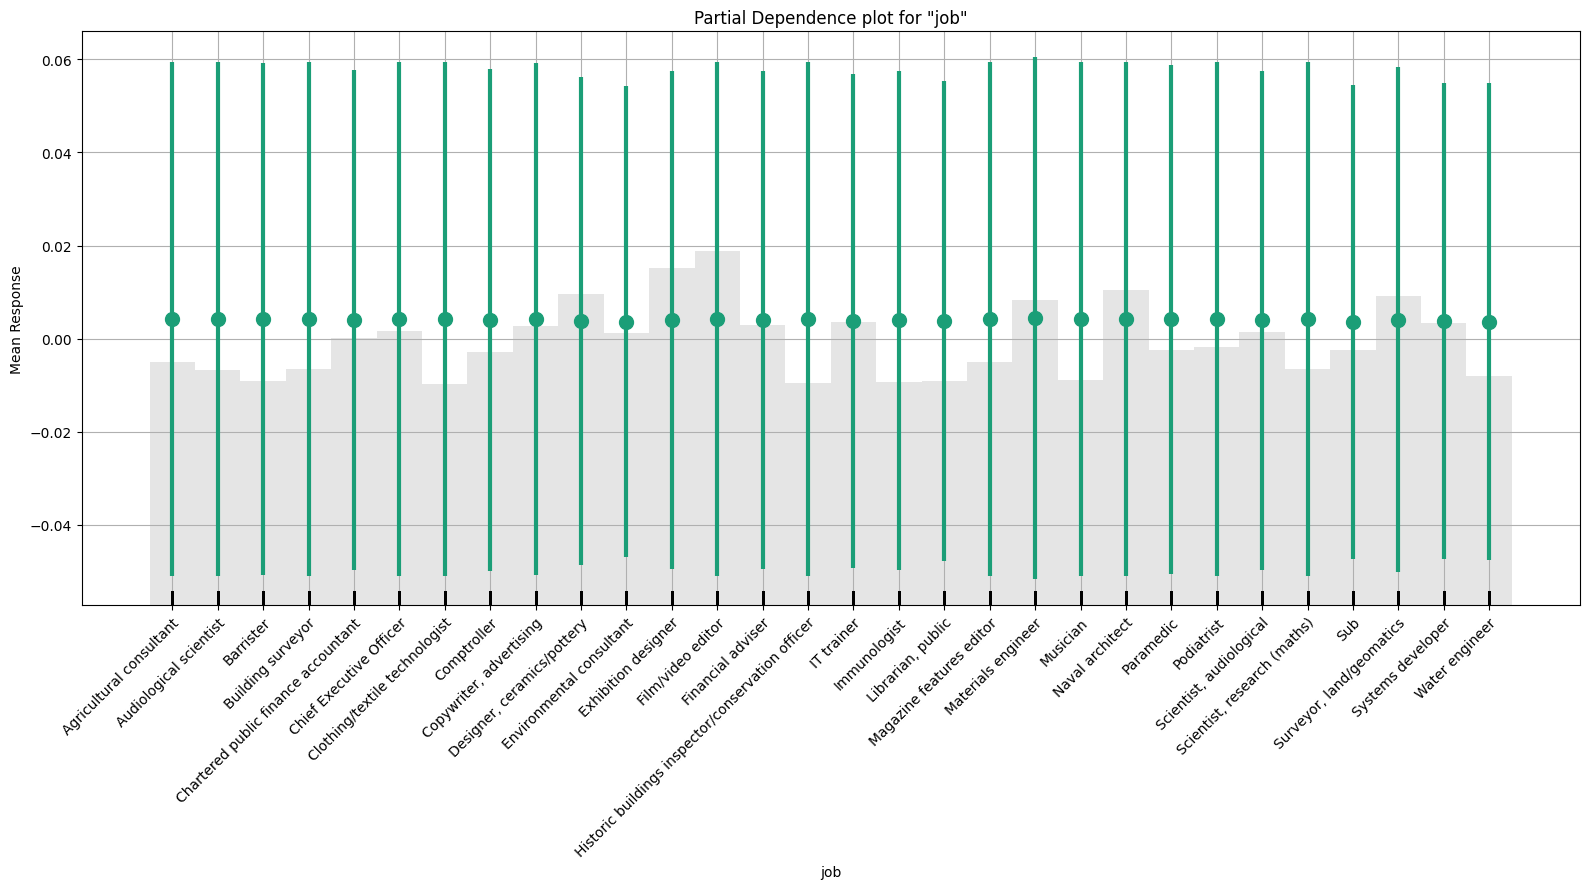

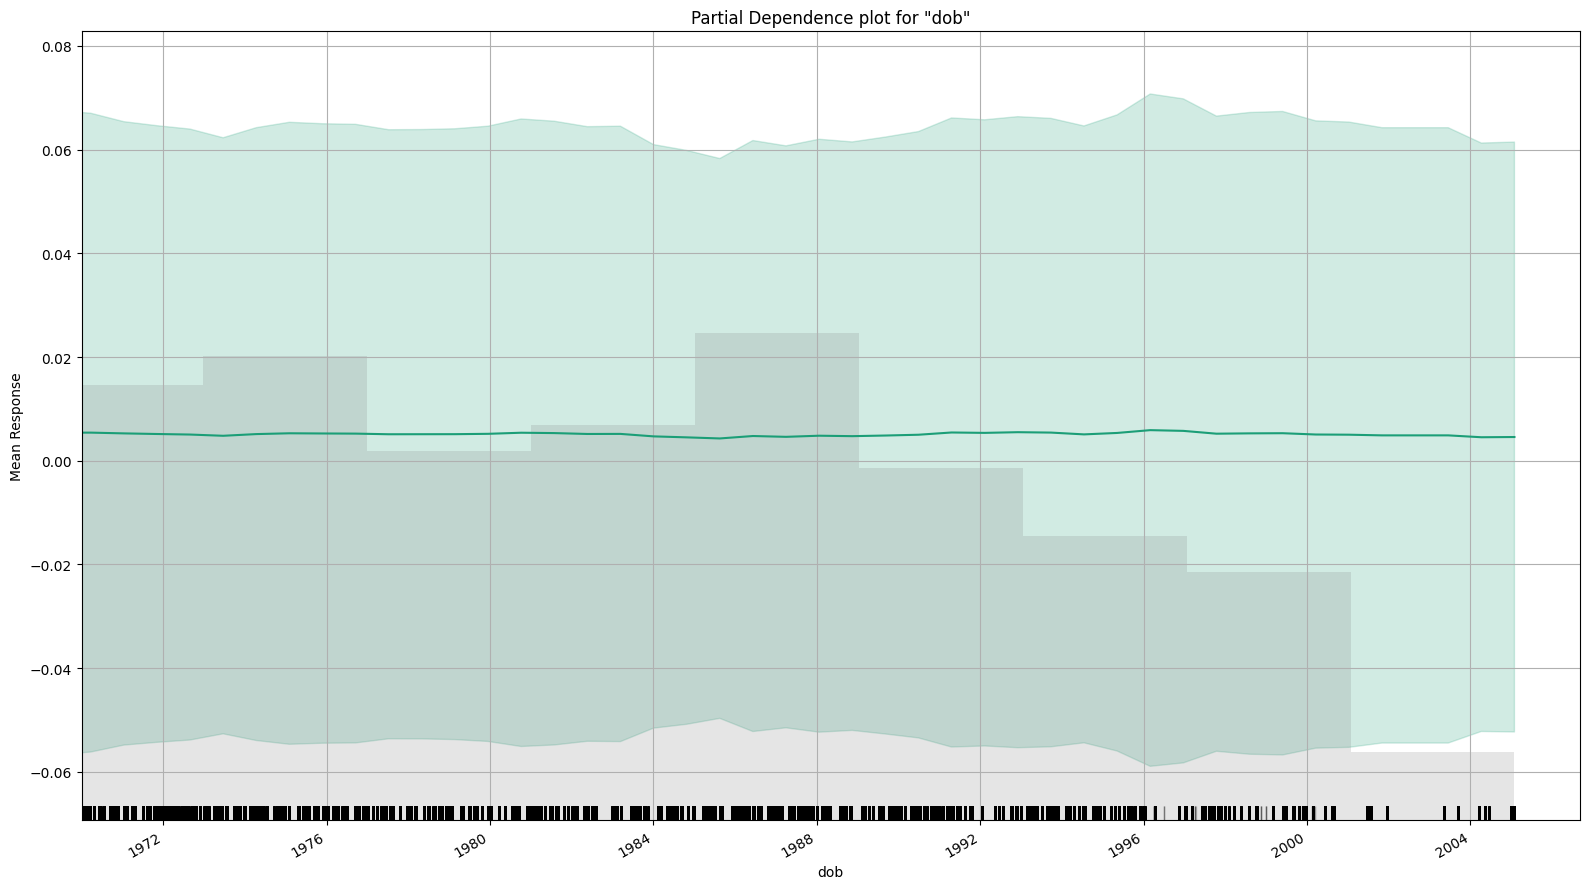

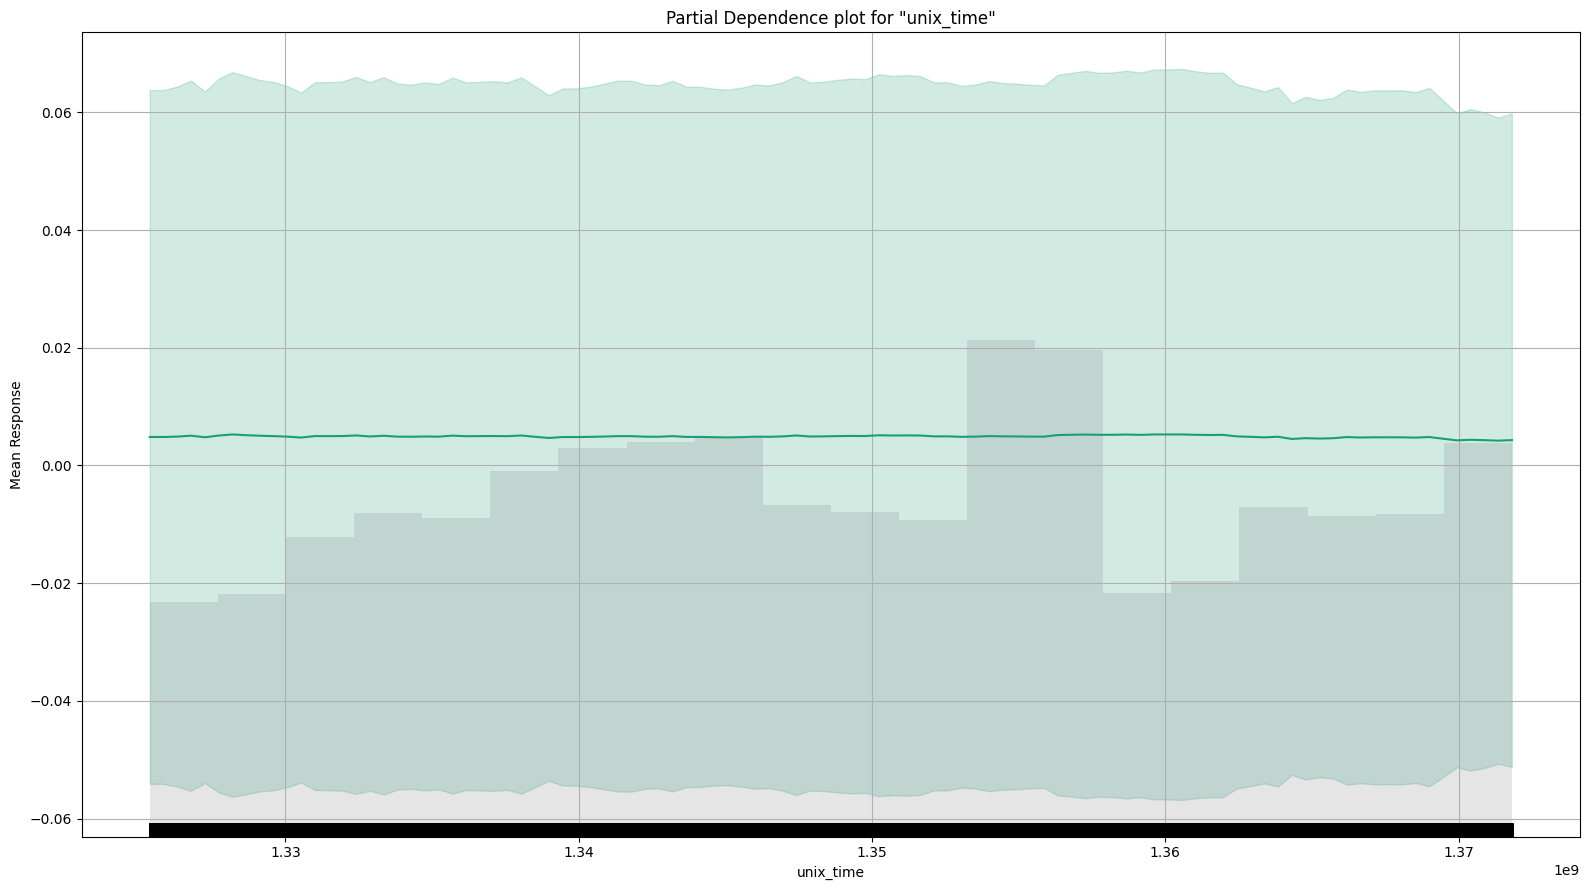

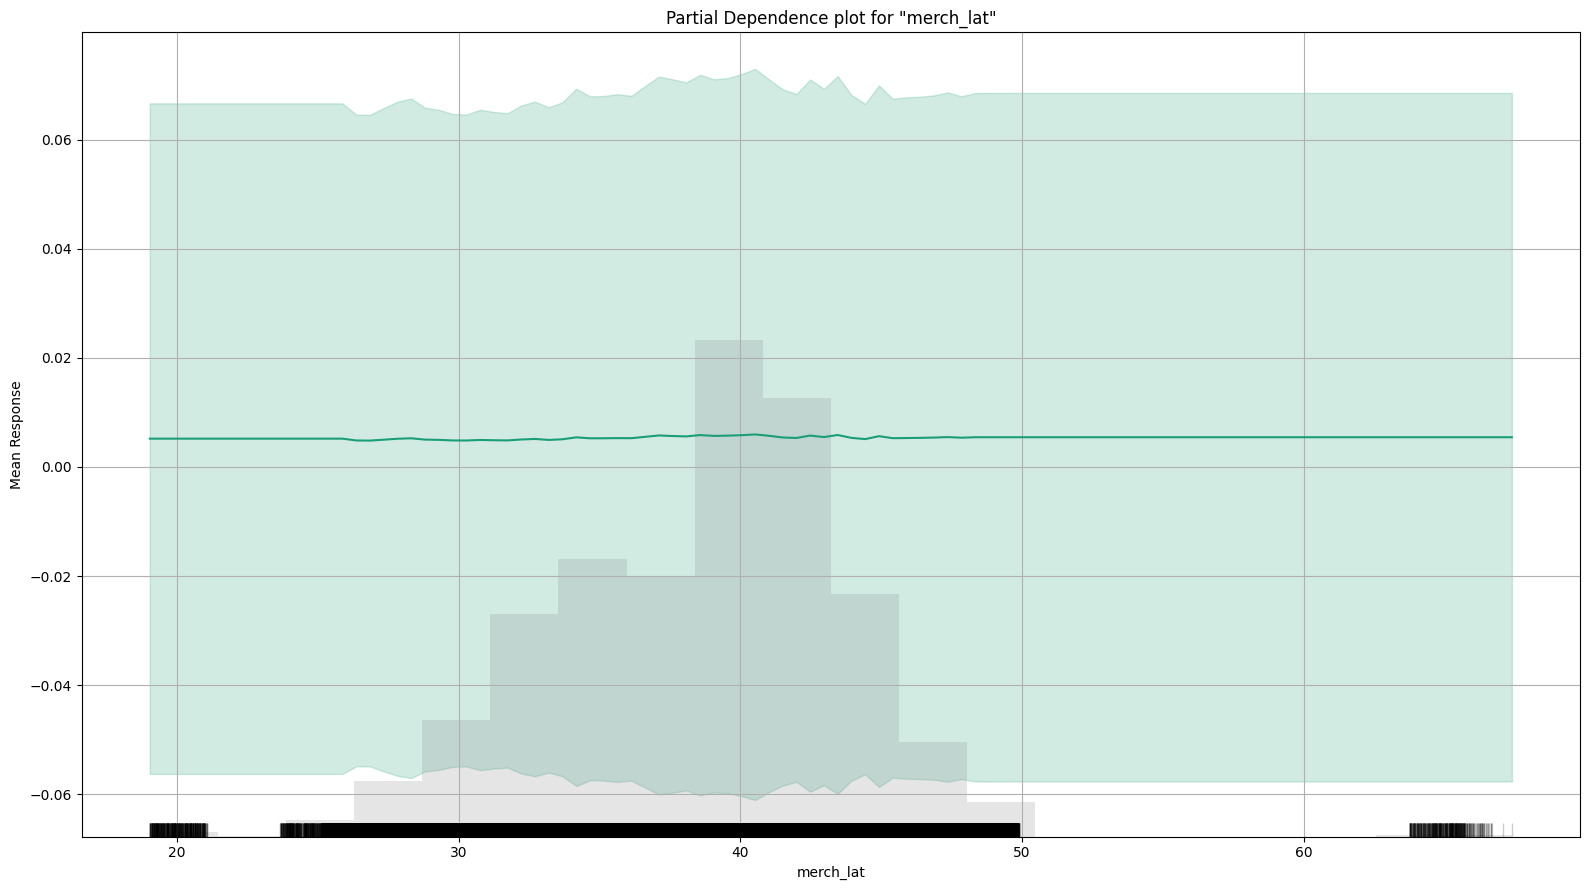

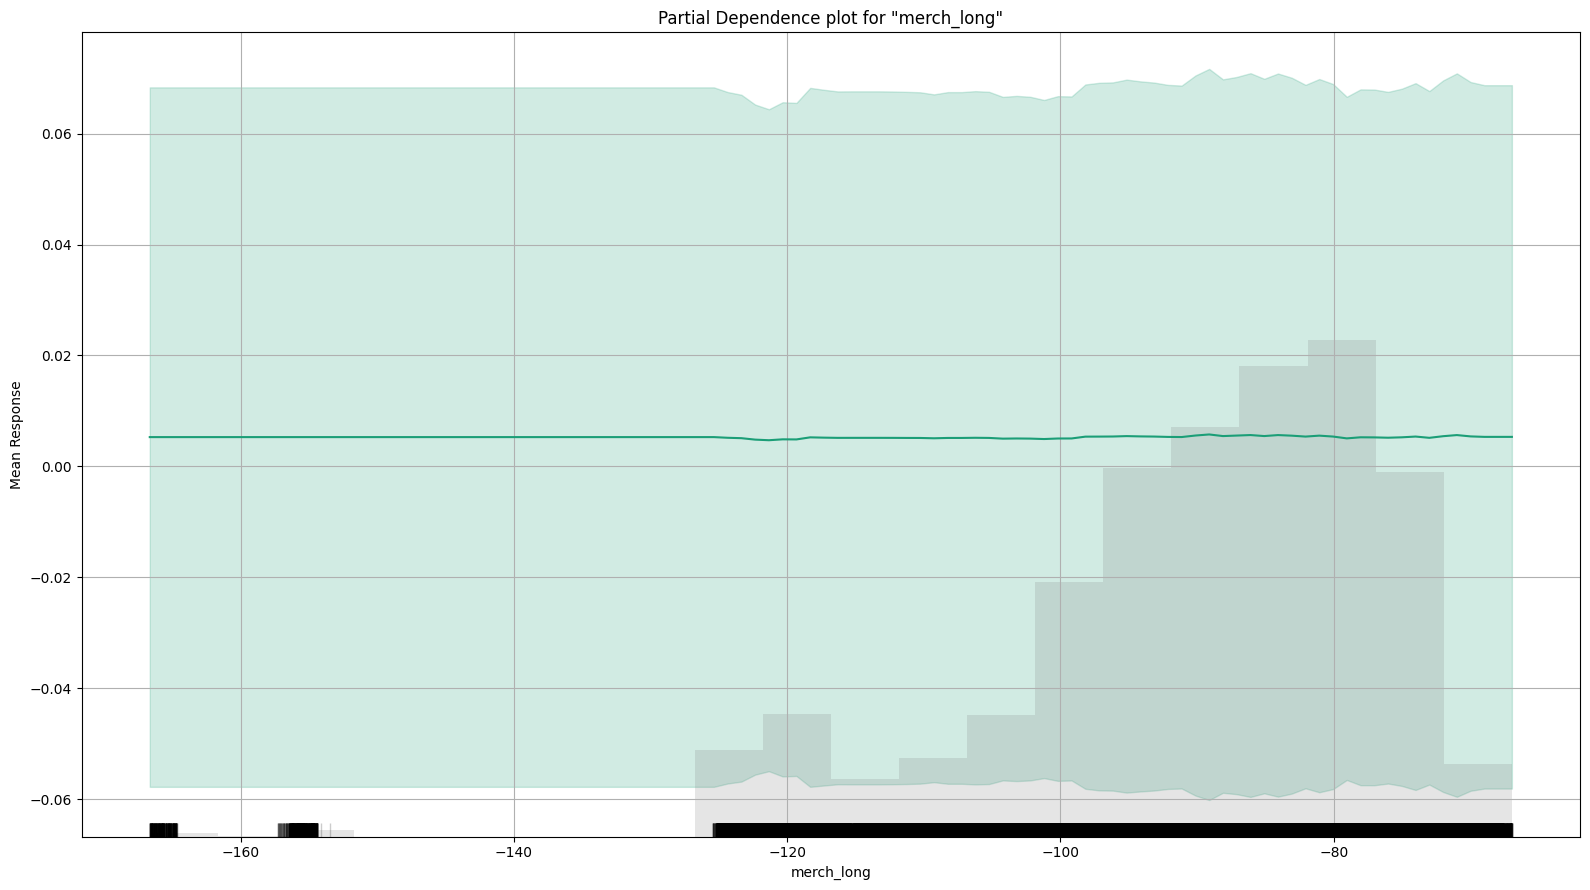

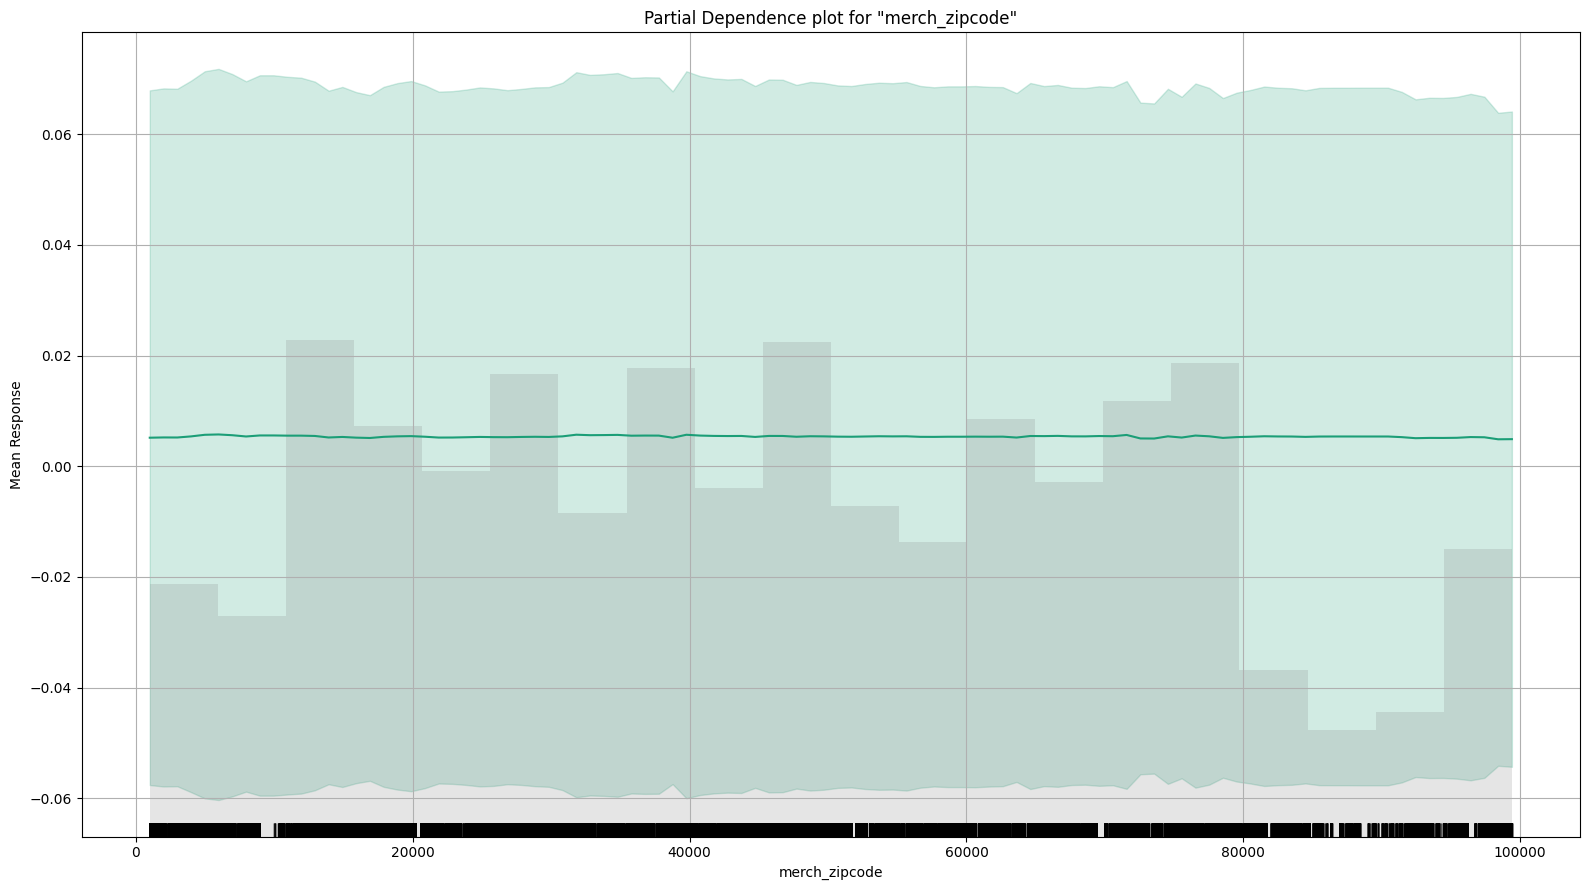

# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## StackedEnsemble_AllModels_3_AutoML_1_20260324_160110

,0,1,Error,Rate
0,257616.0,157.0,0.0006,(157.0/257773.0)
1,274.0,1186.0,0.1877,(274.0/1460.0)
Total,257890.0,1343.0,0.0017,(431.0/259233.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

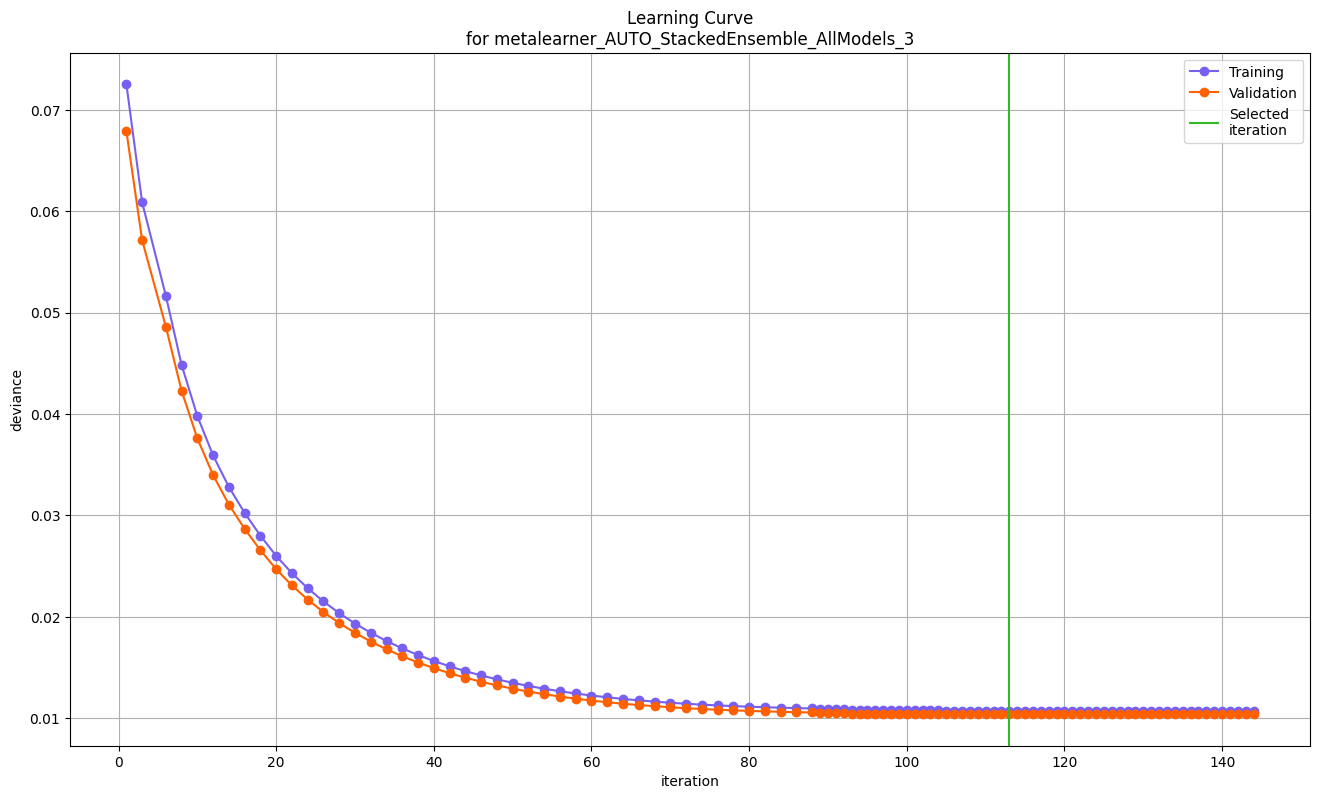

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

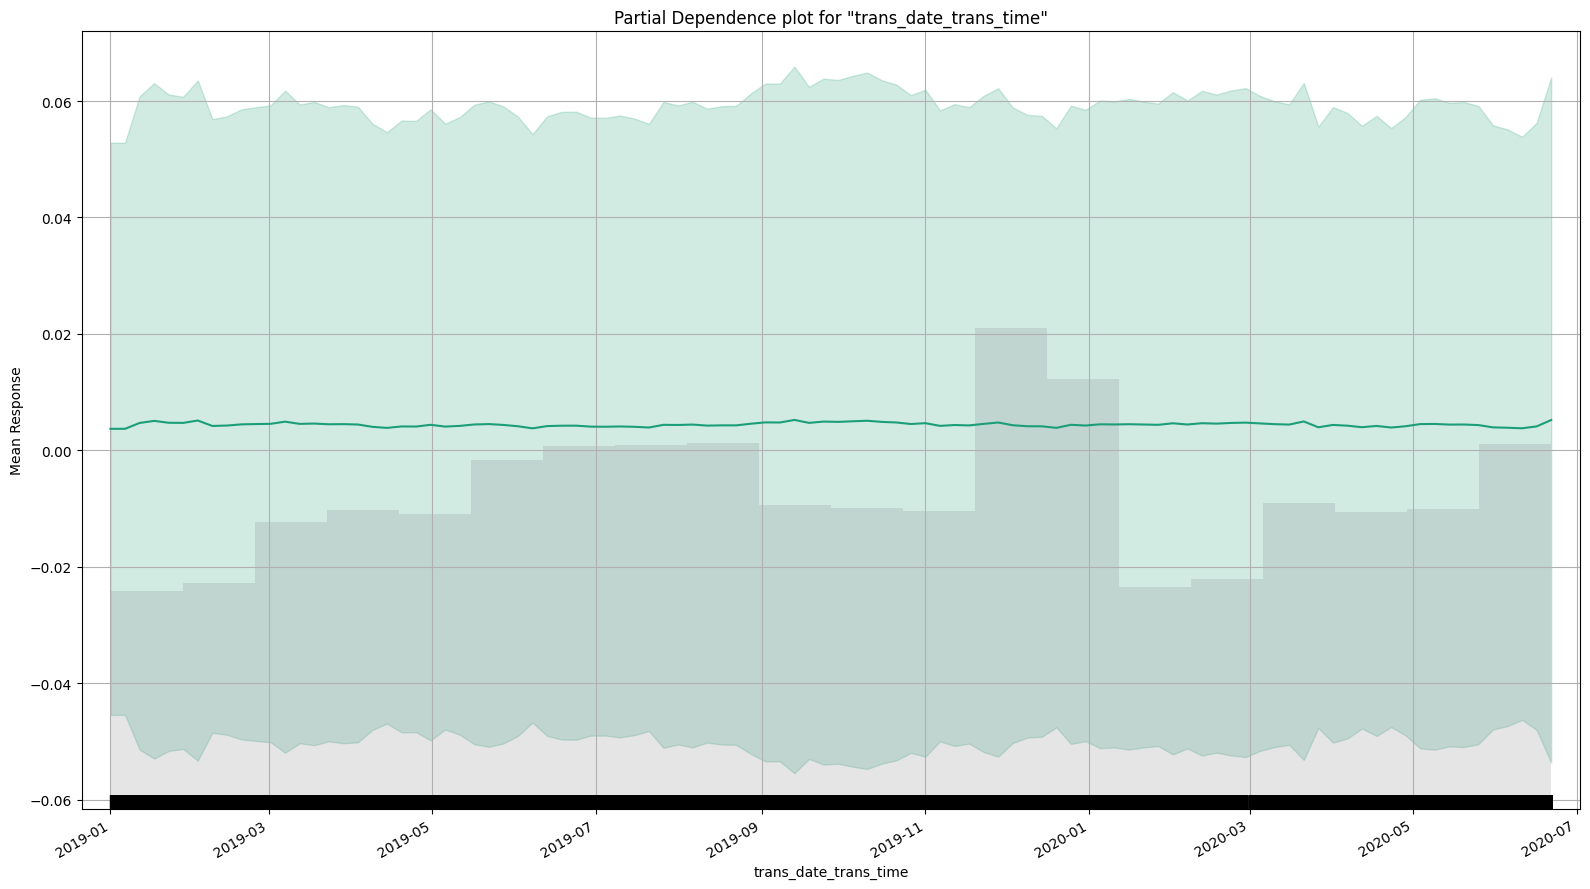

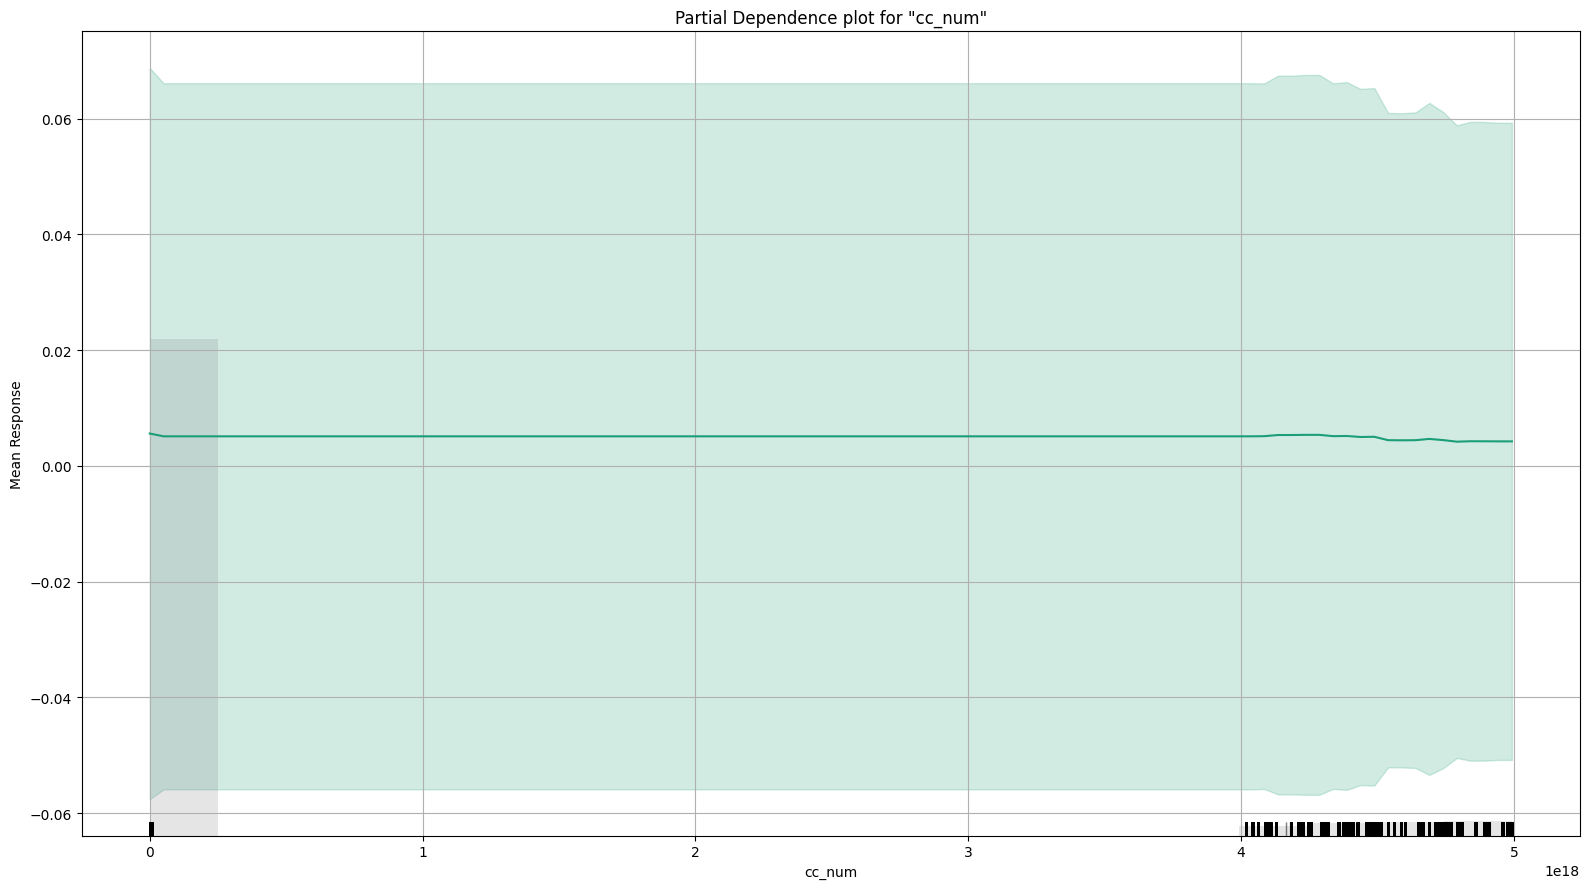

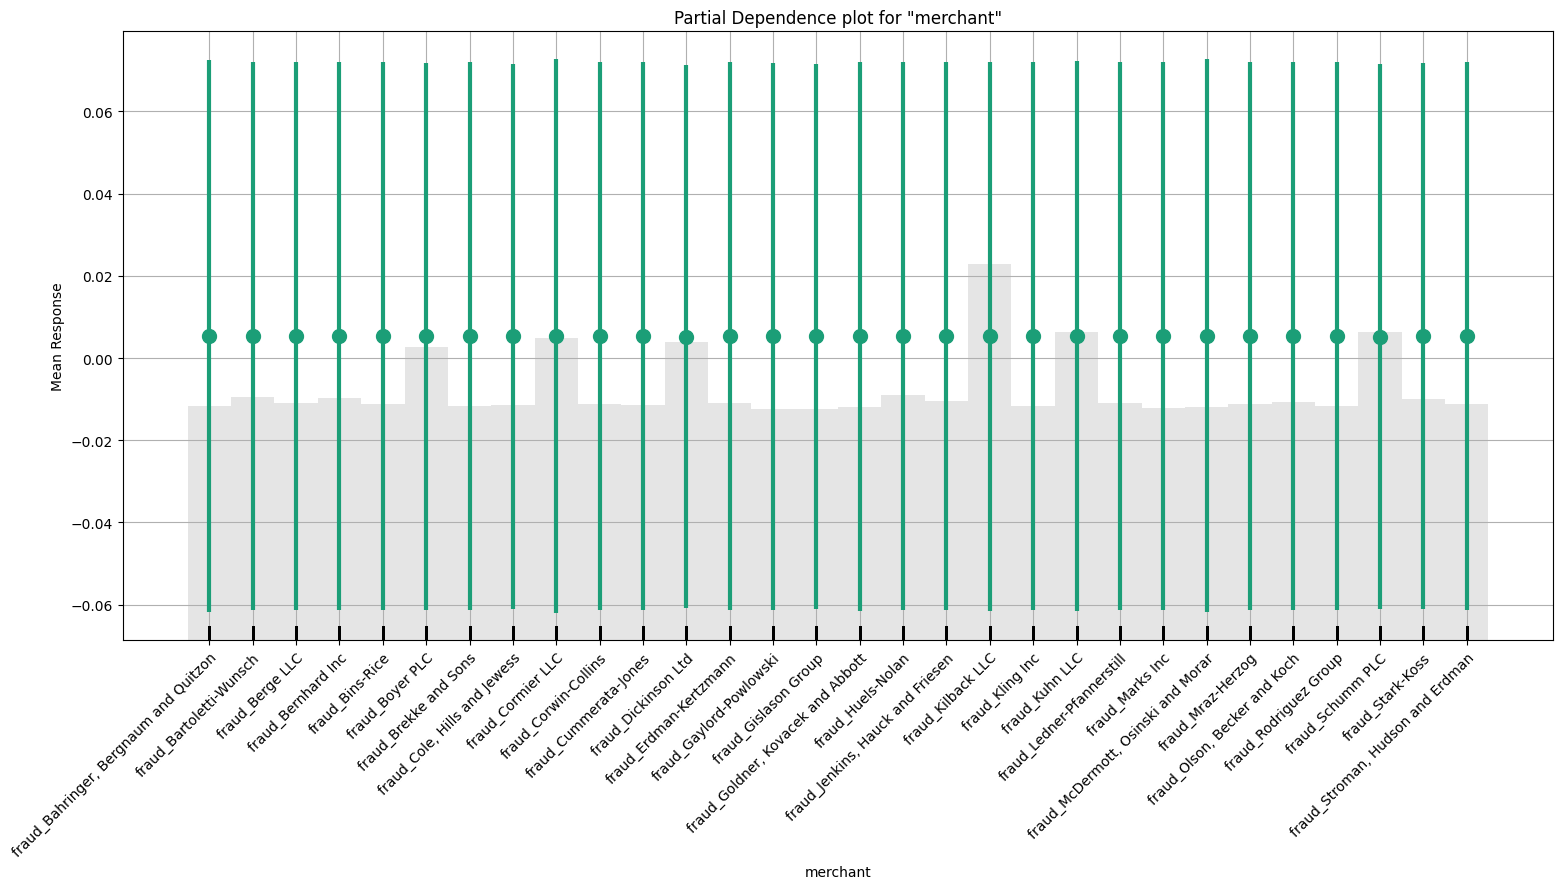

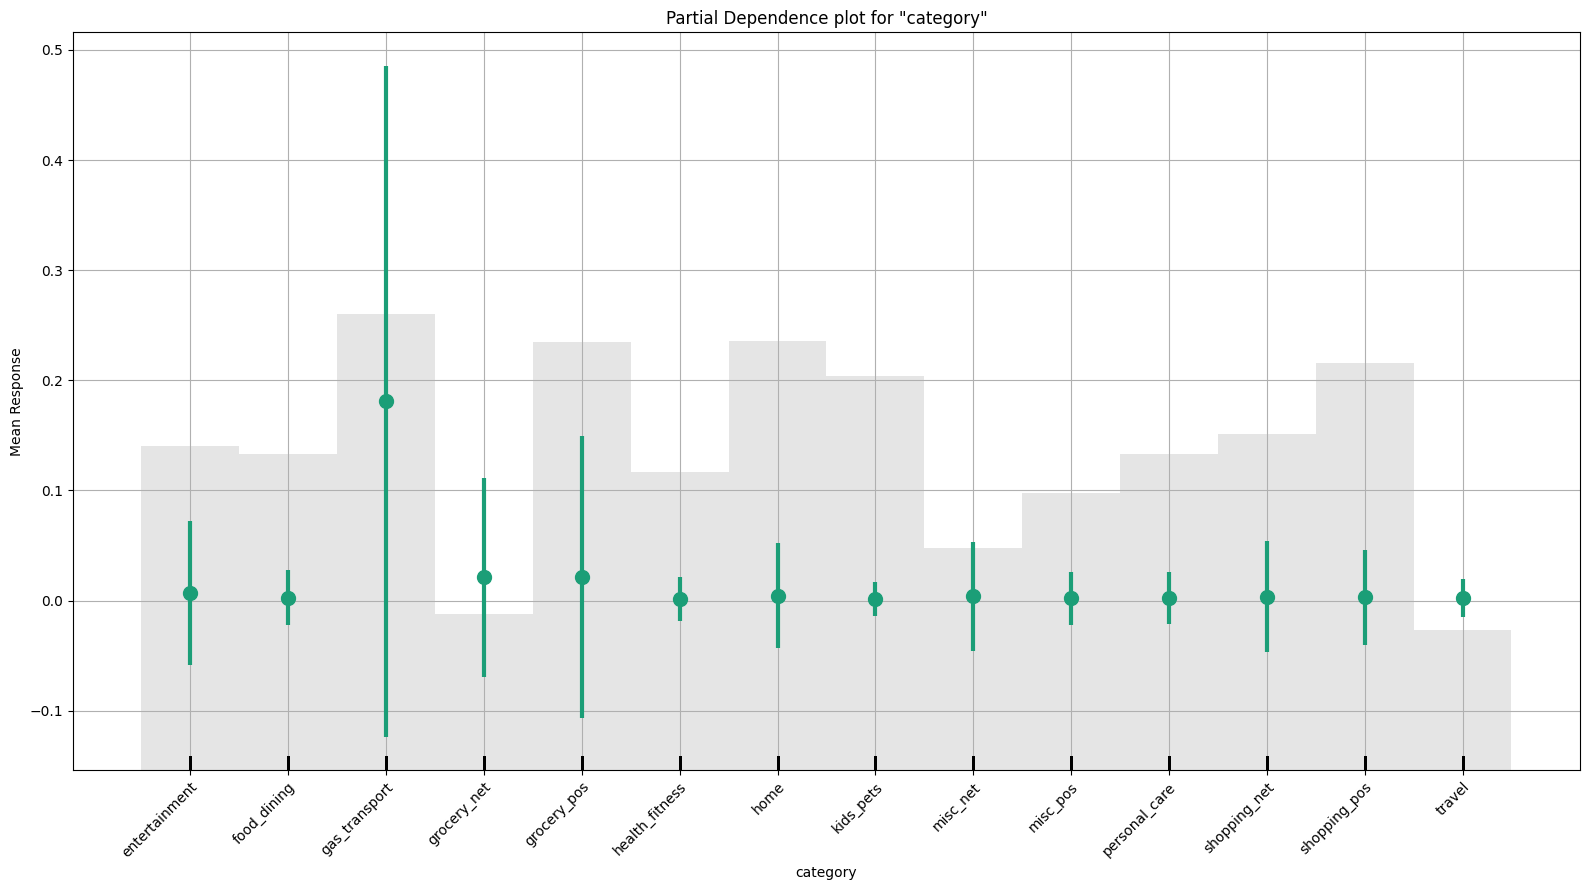

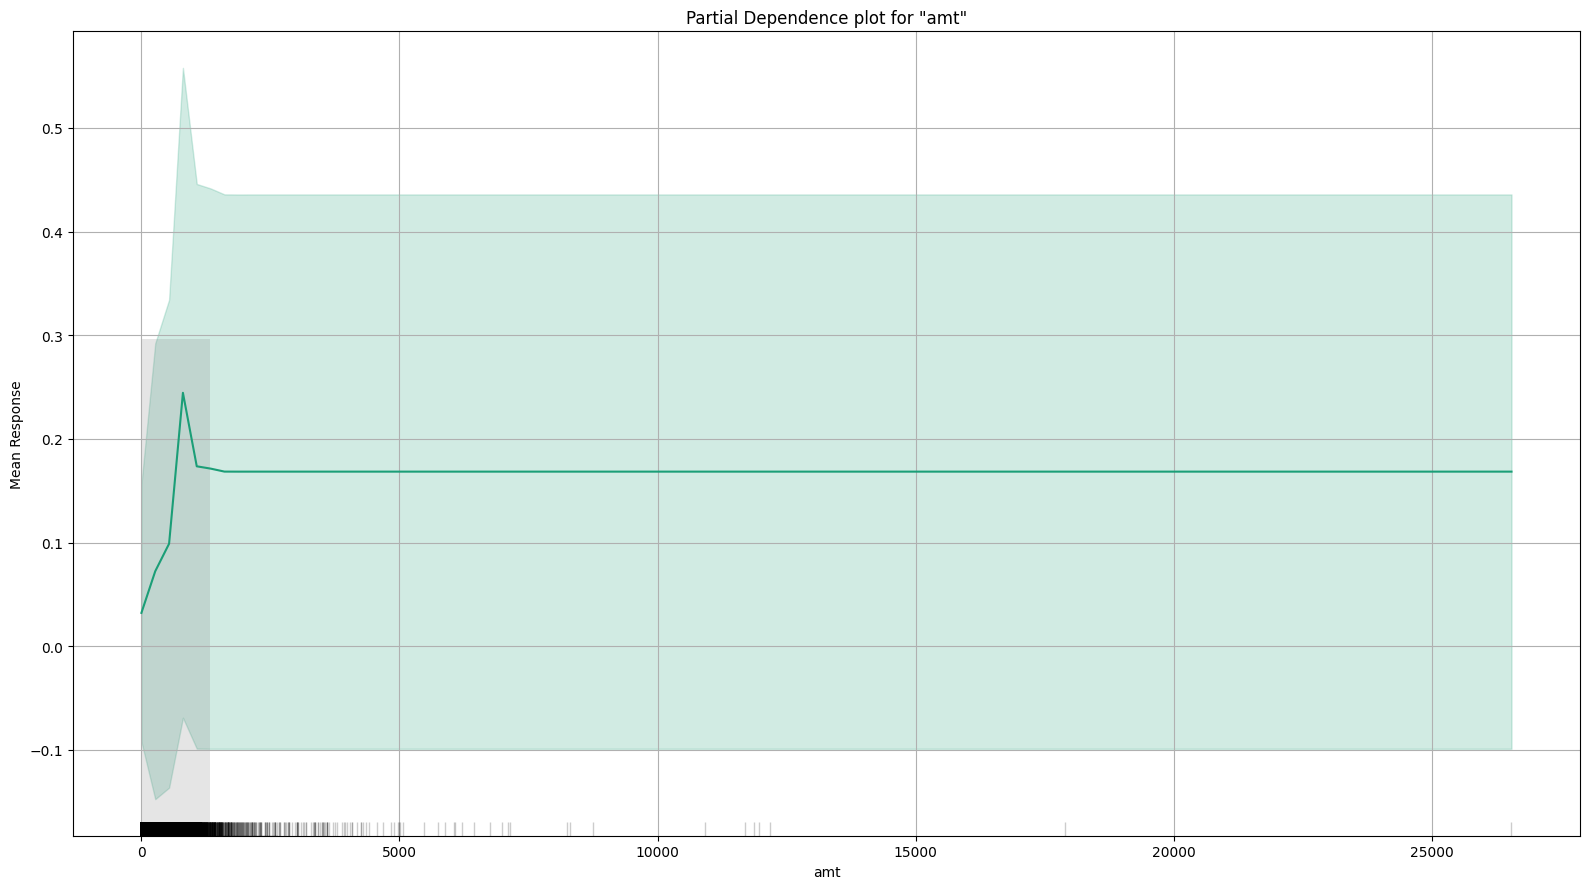

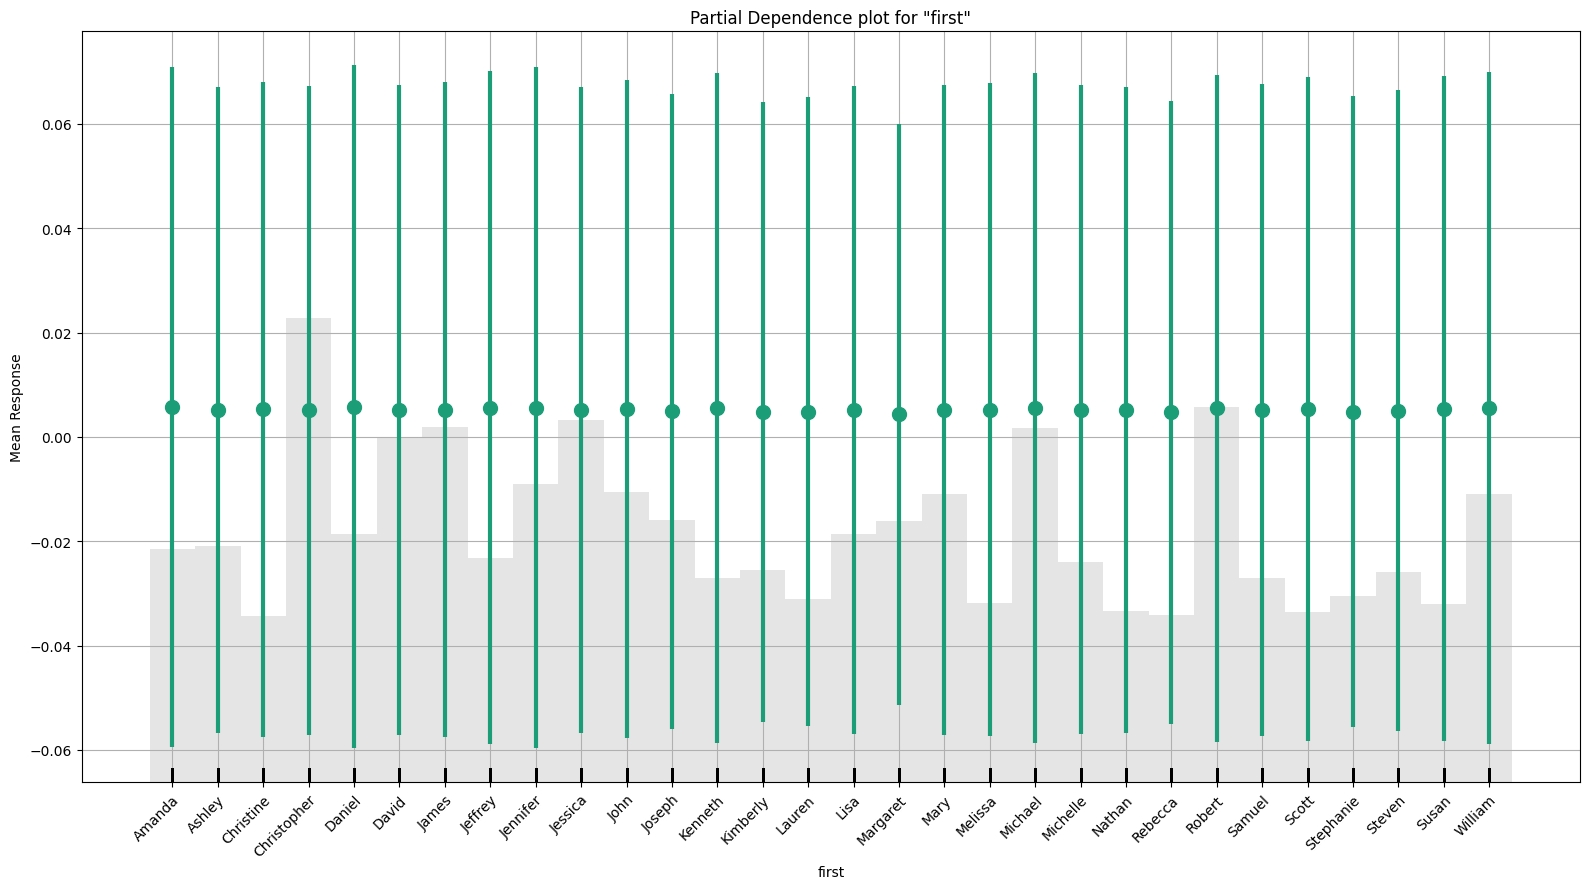

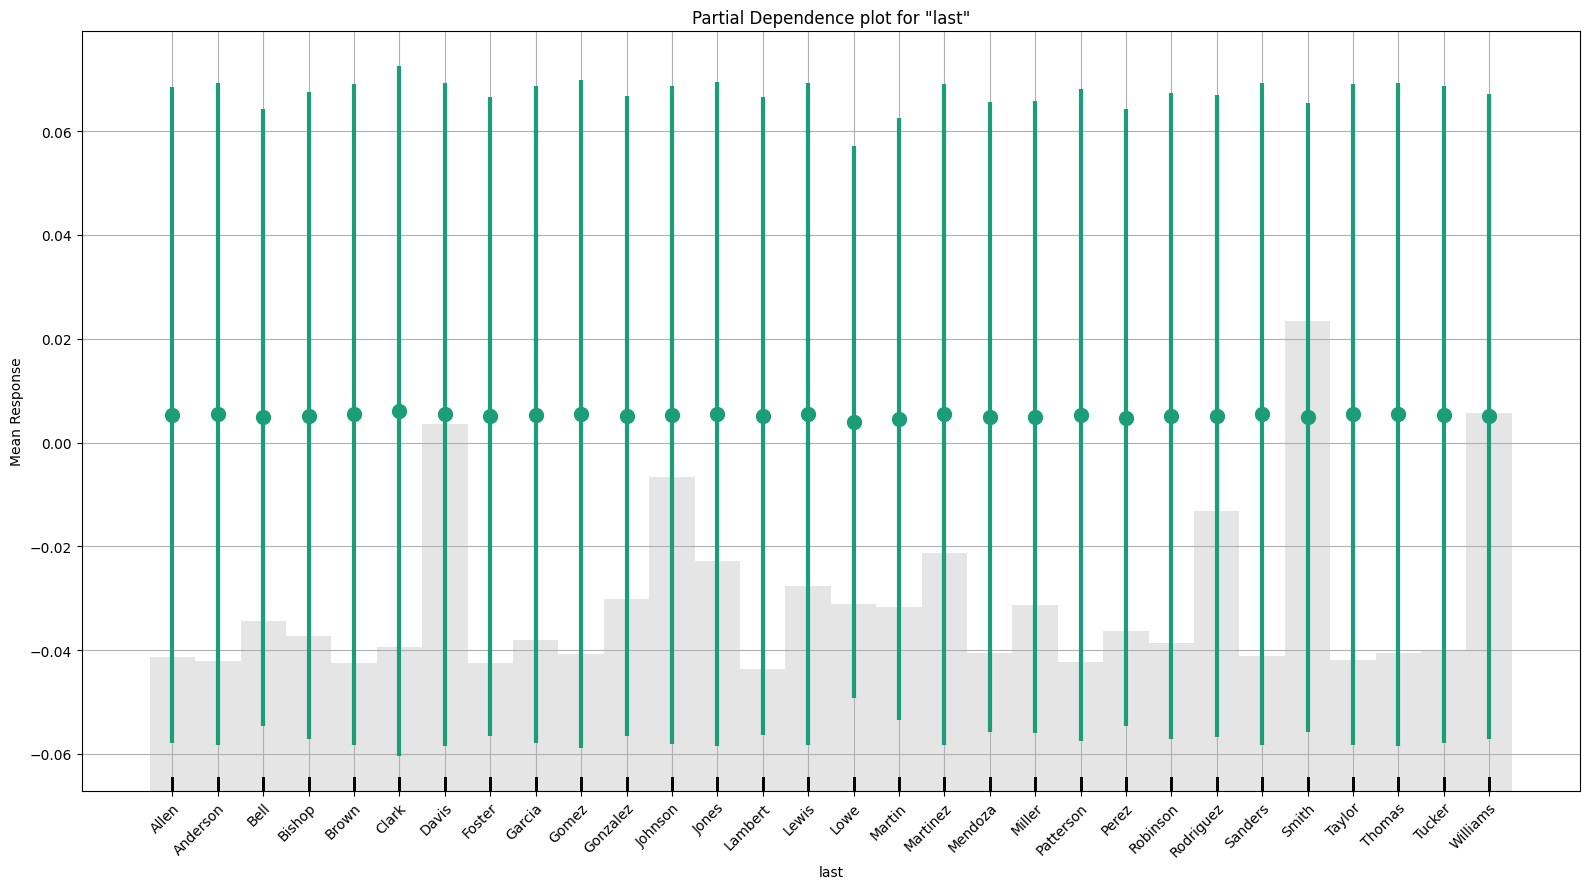

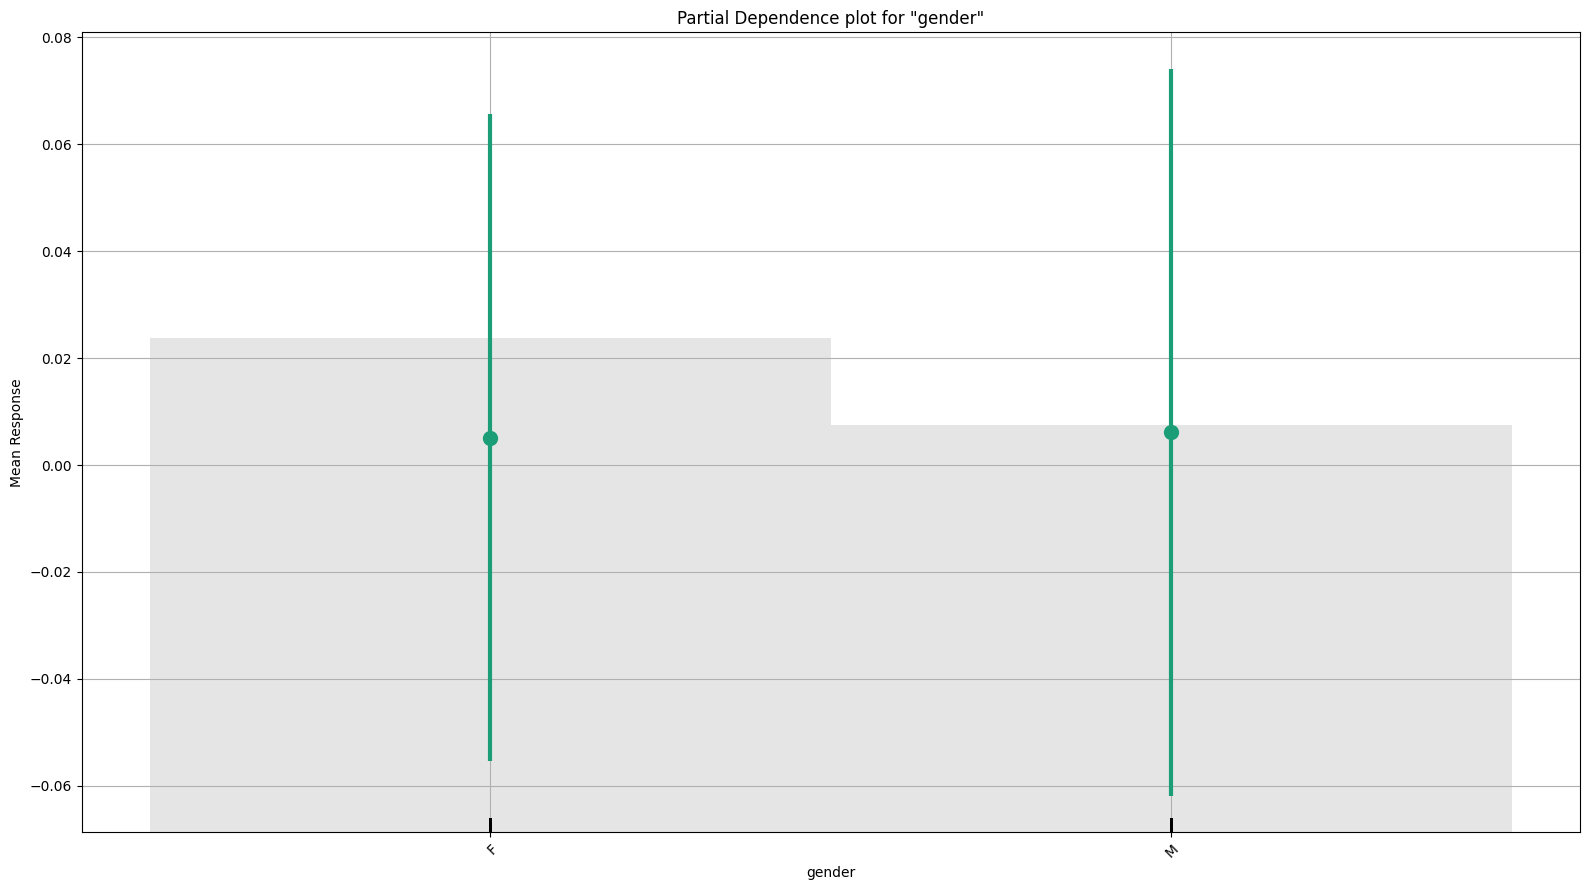

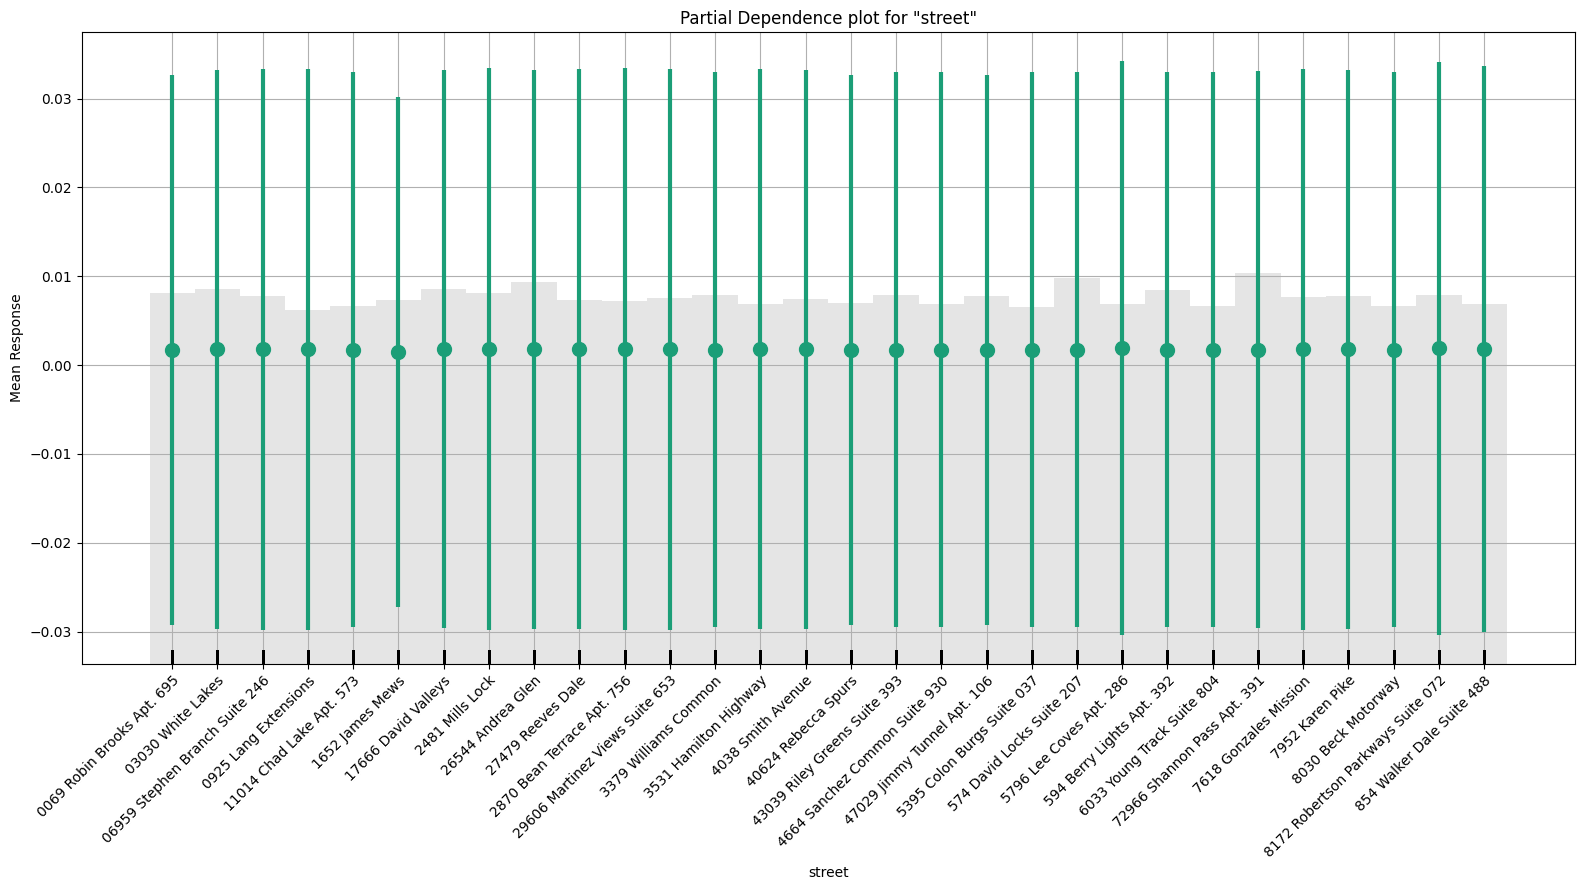

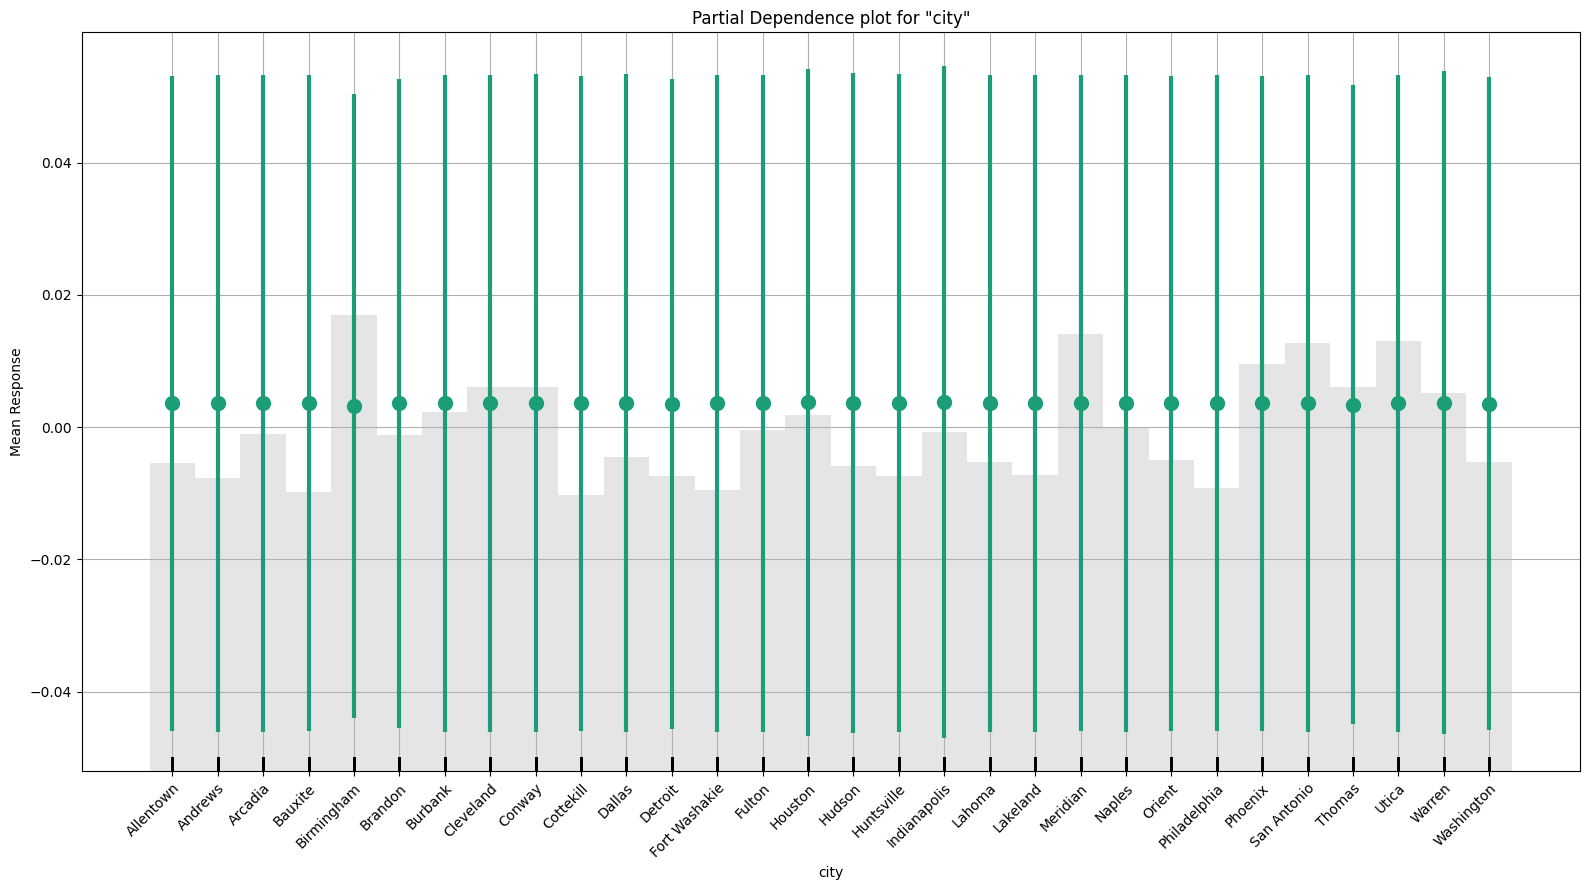

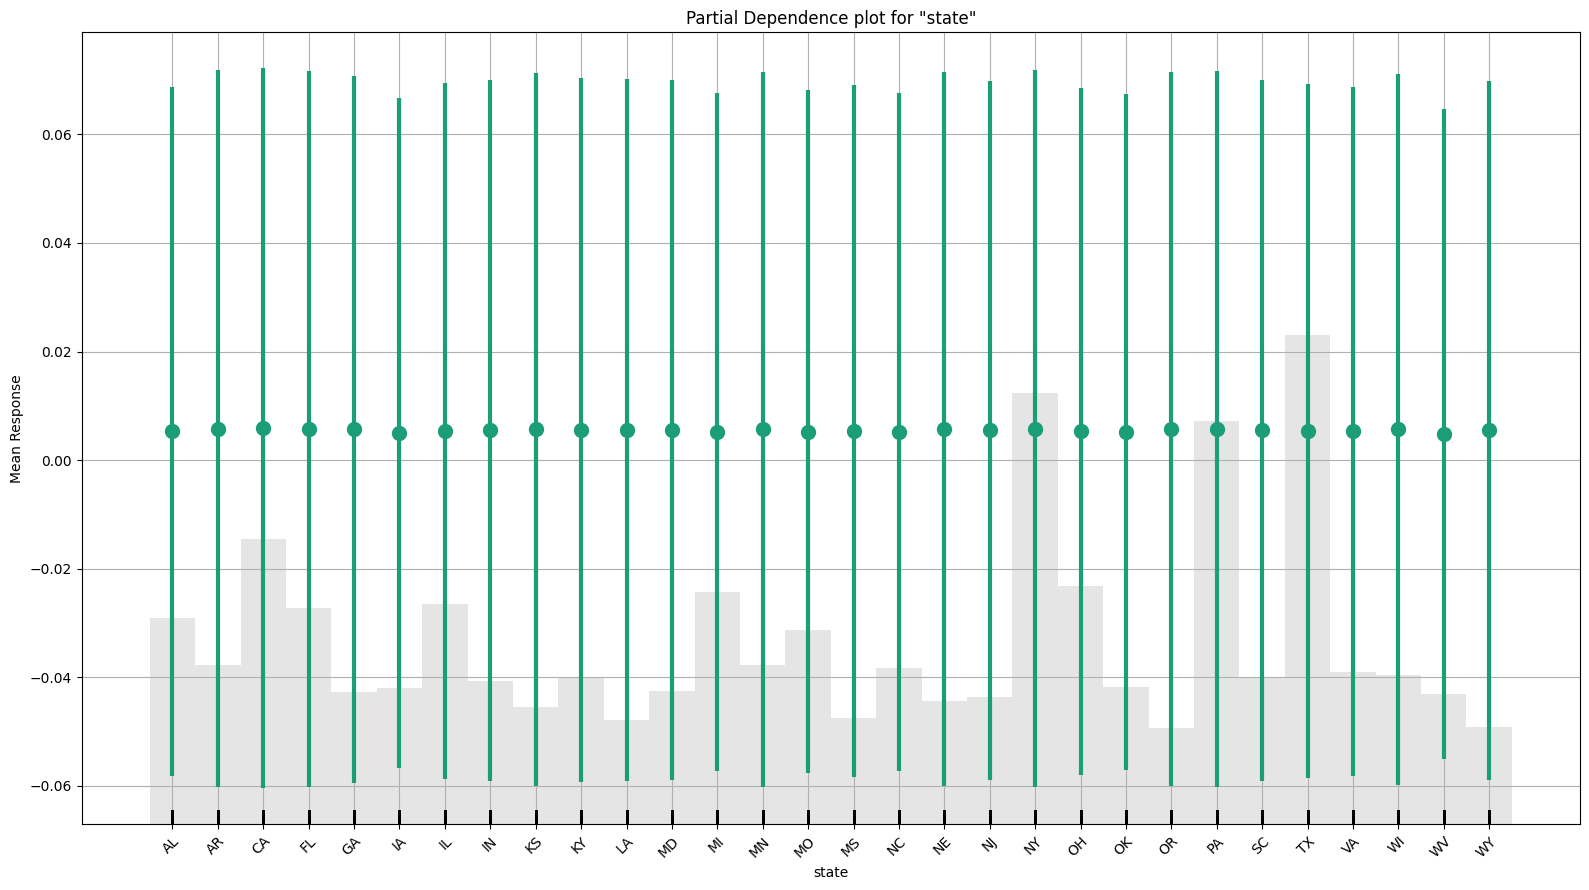

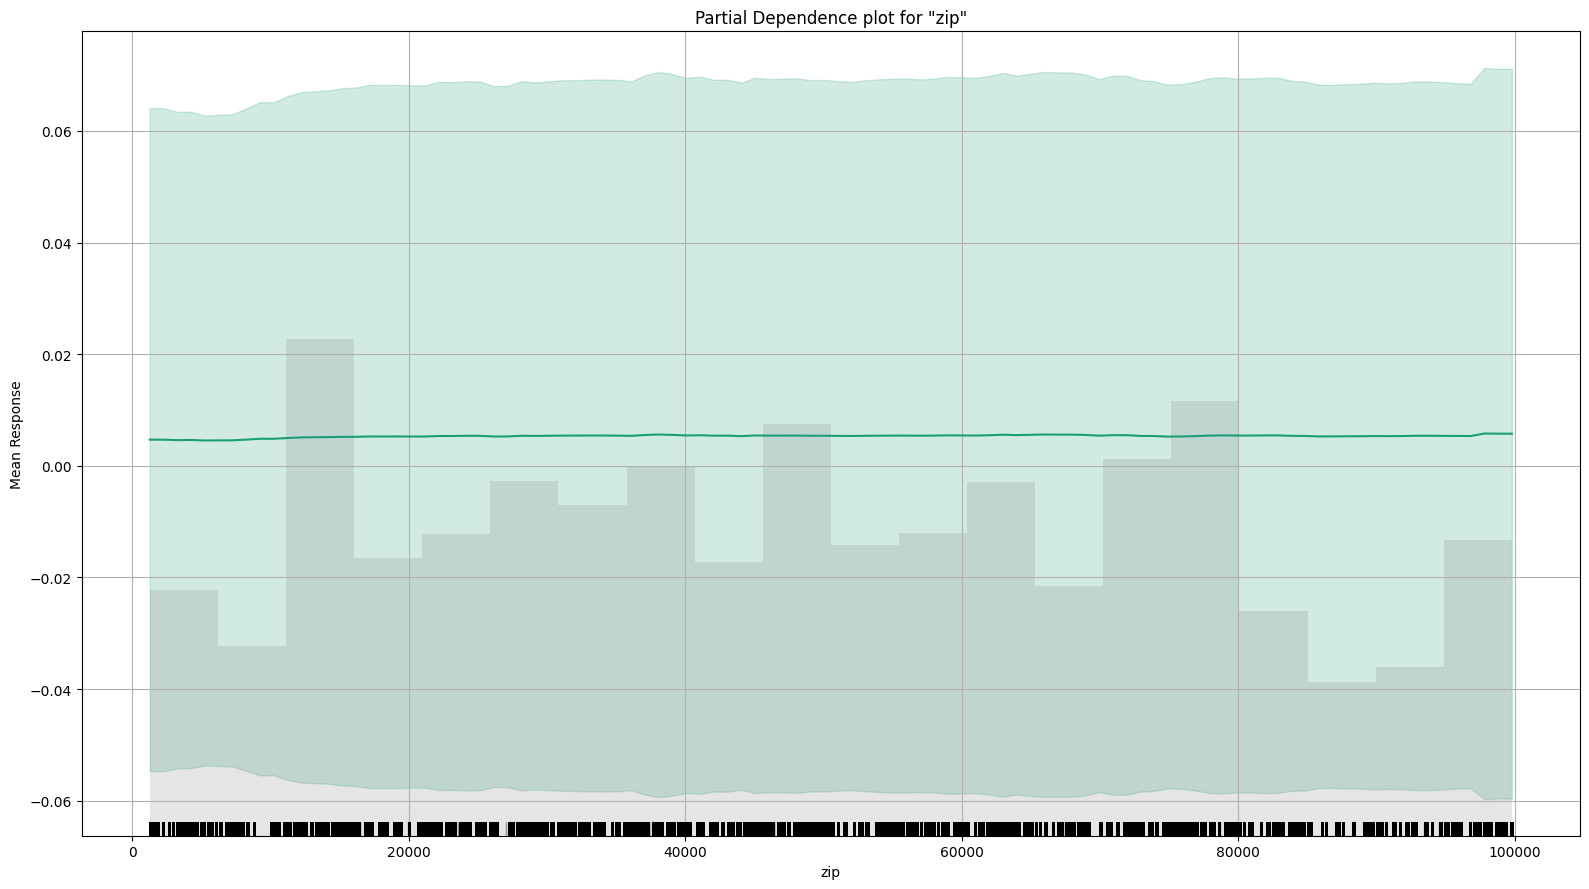

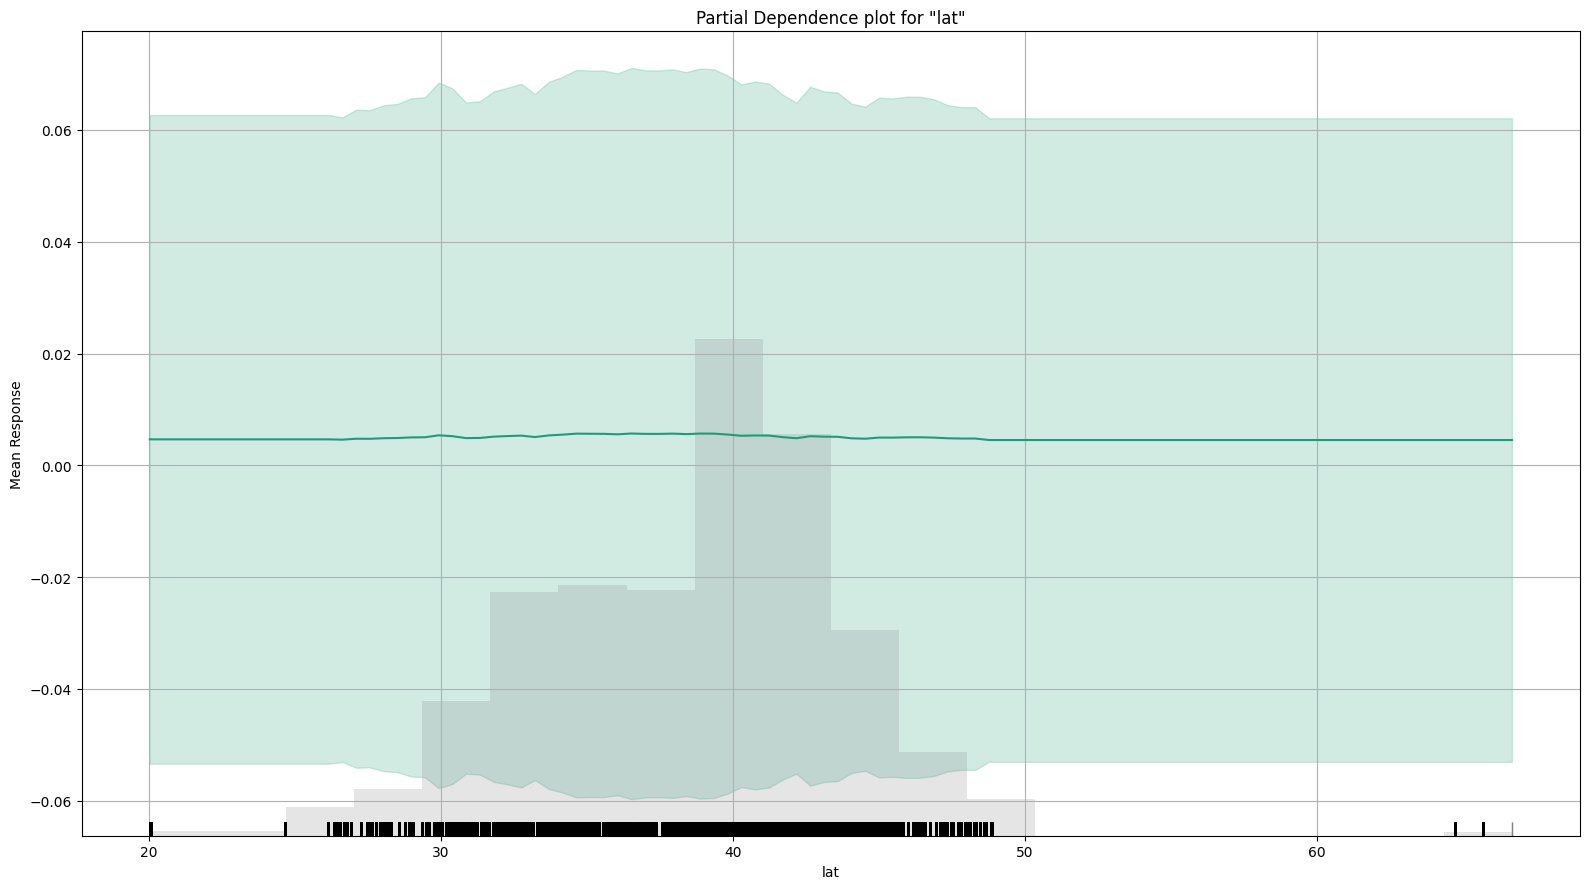

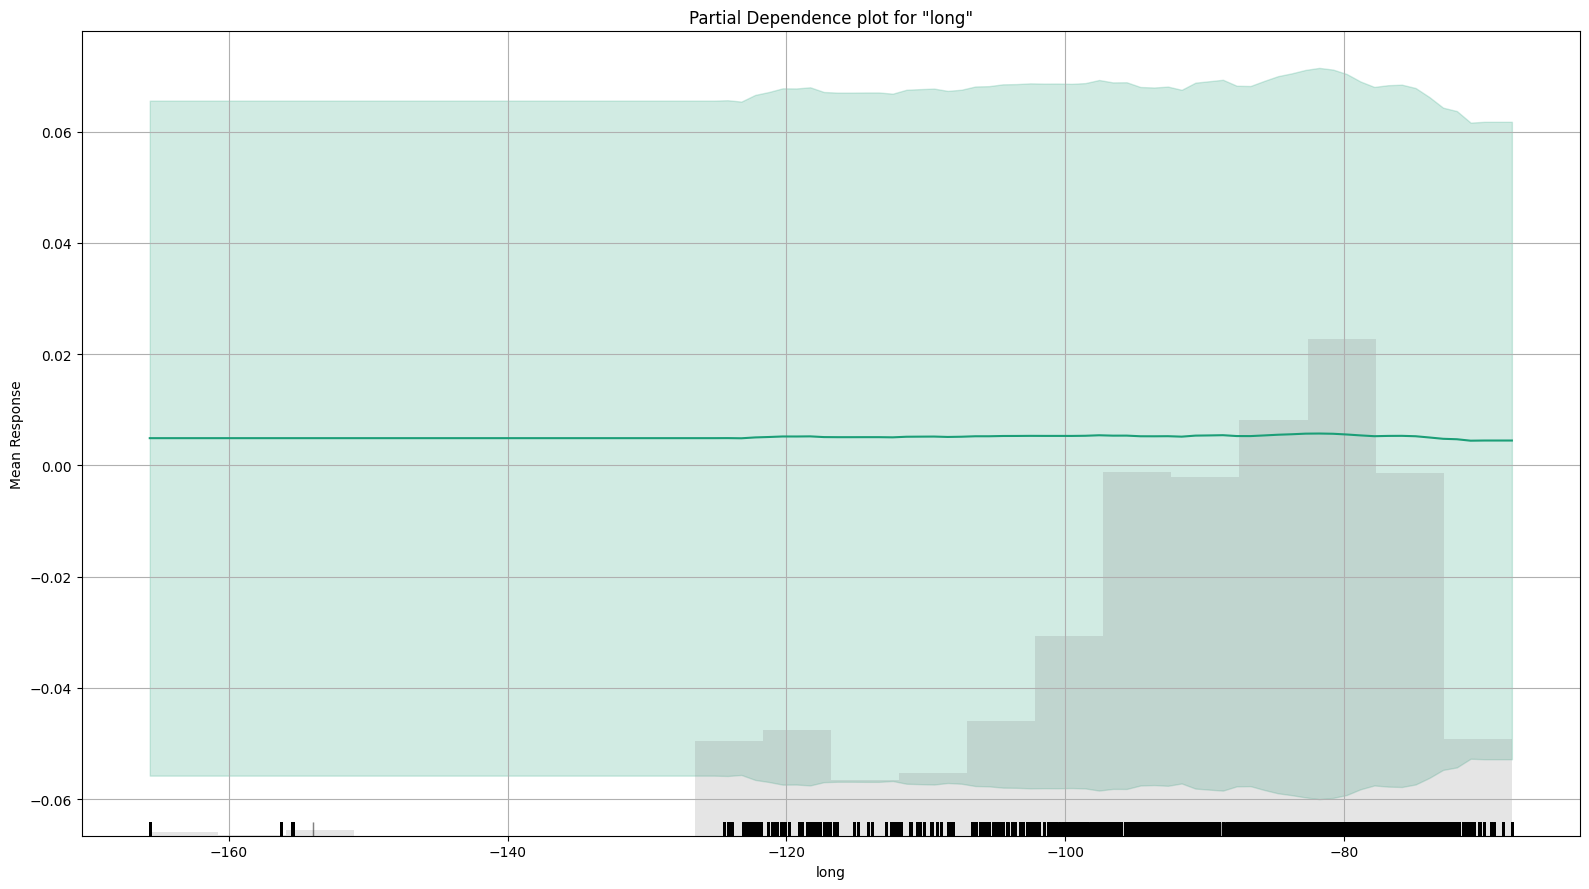

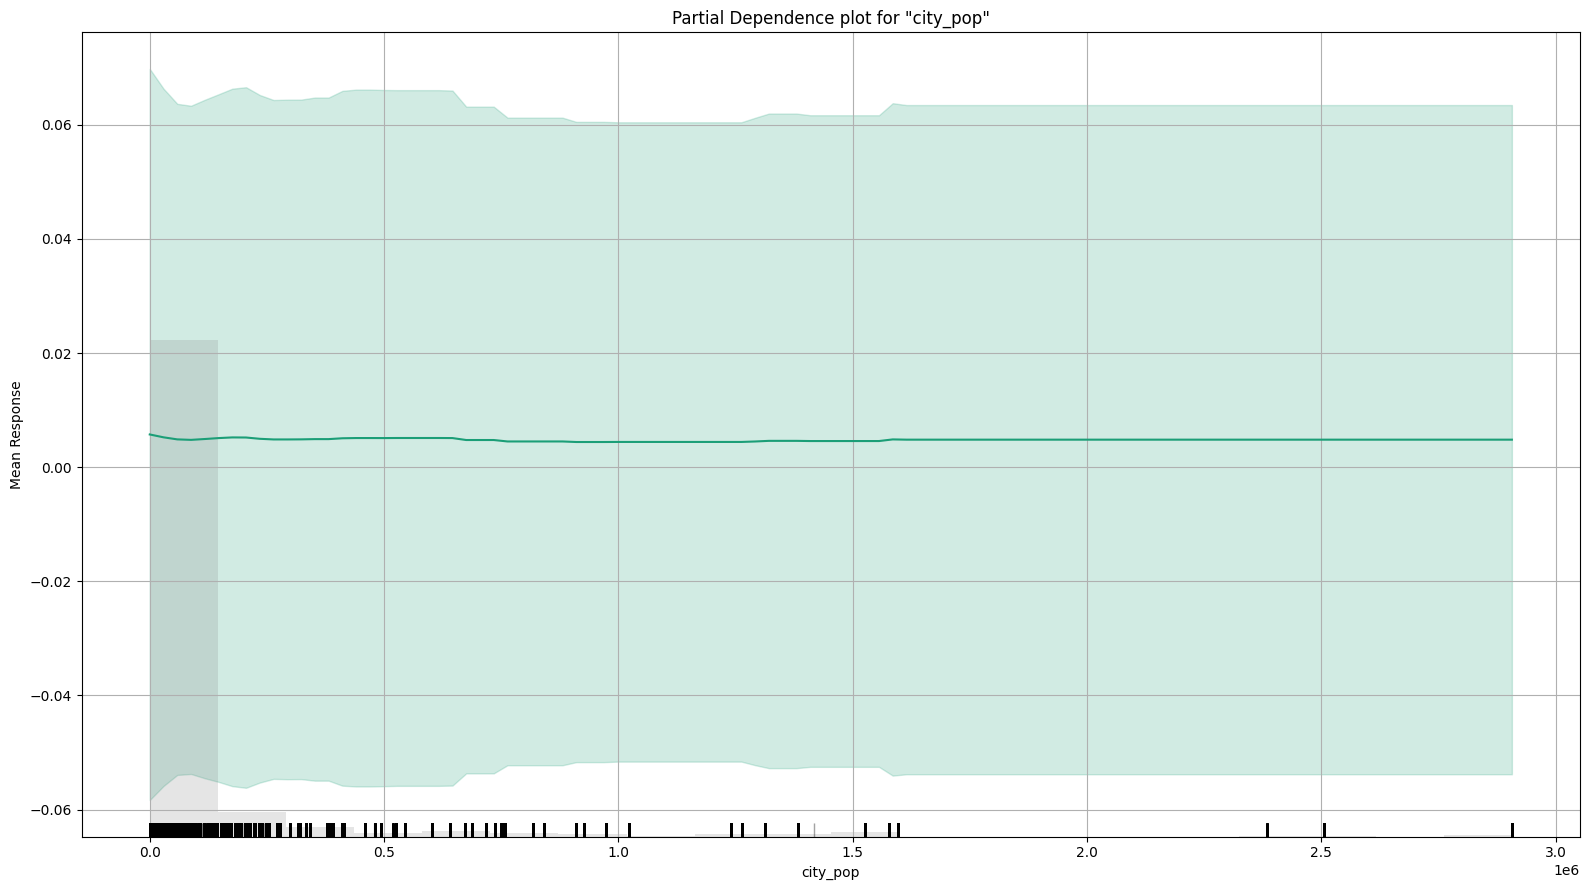

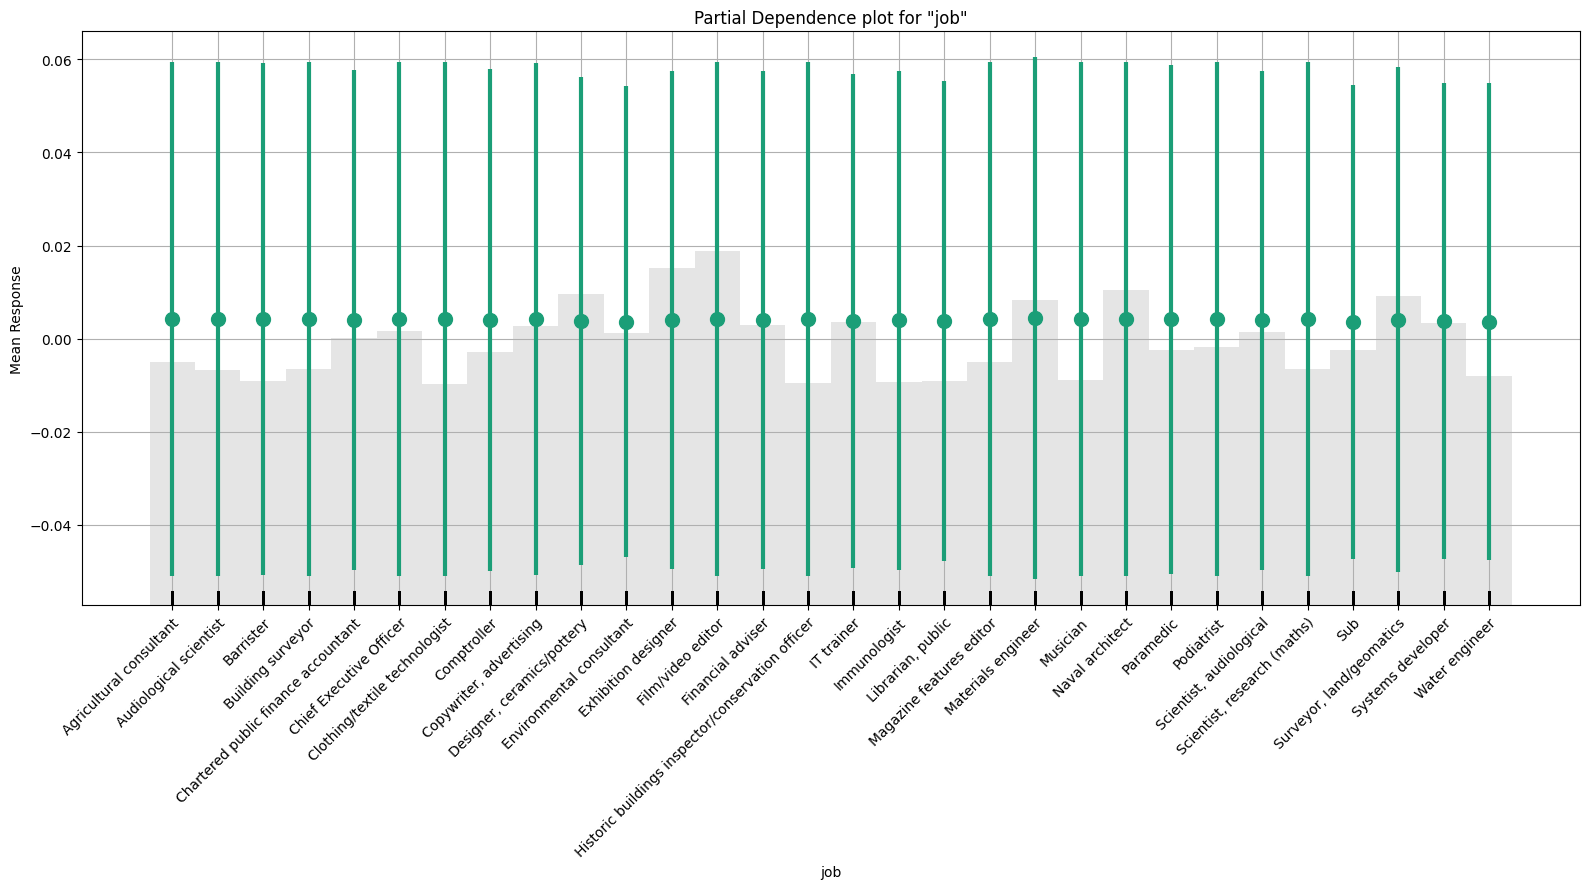

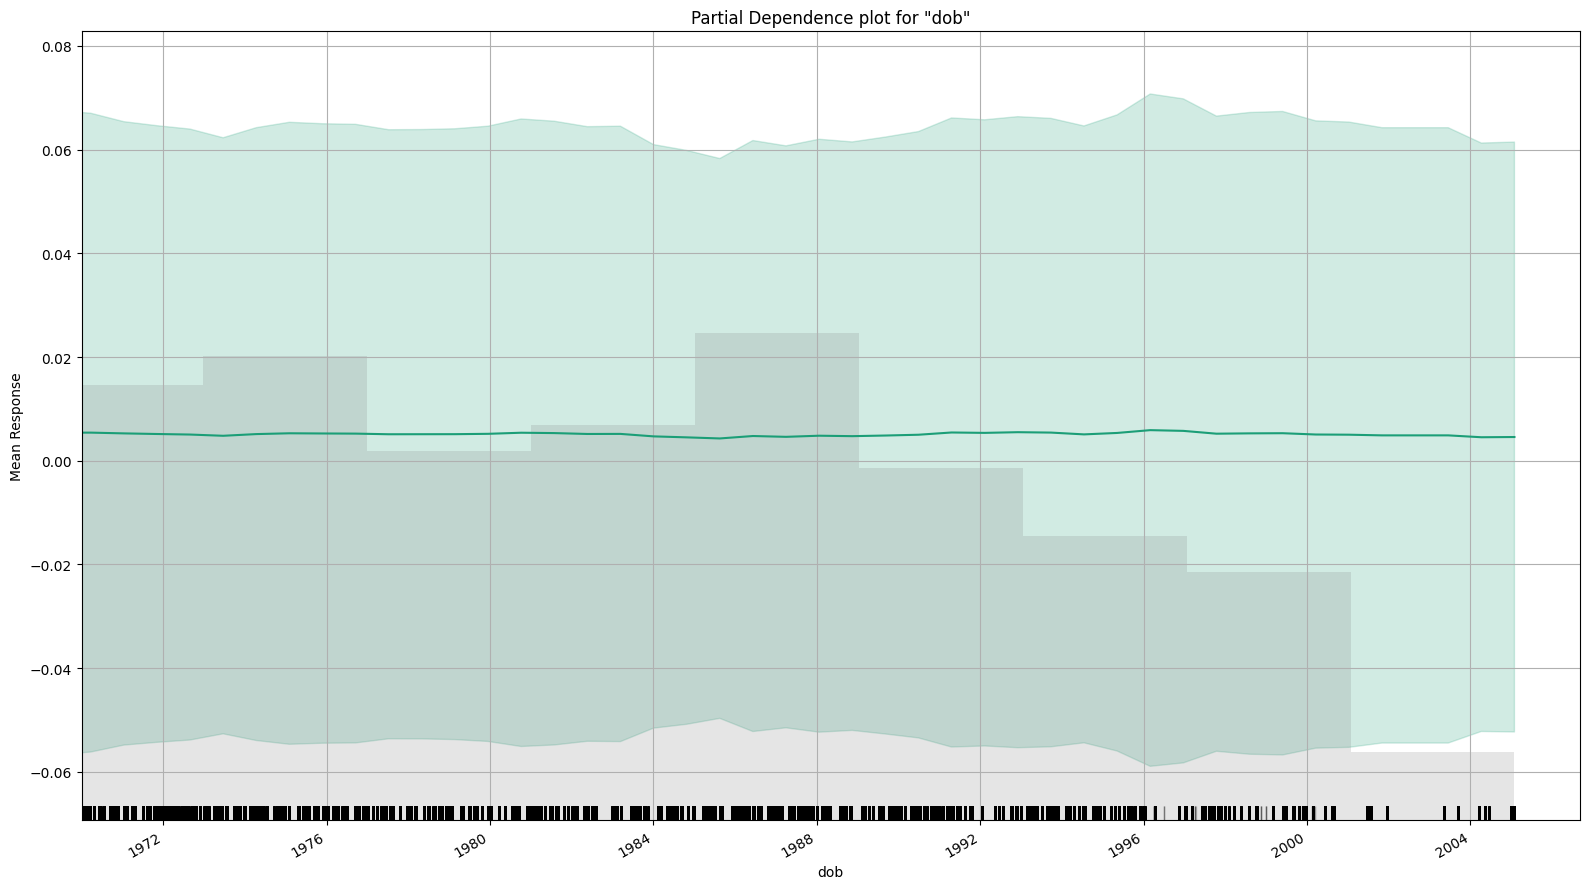

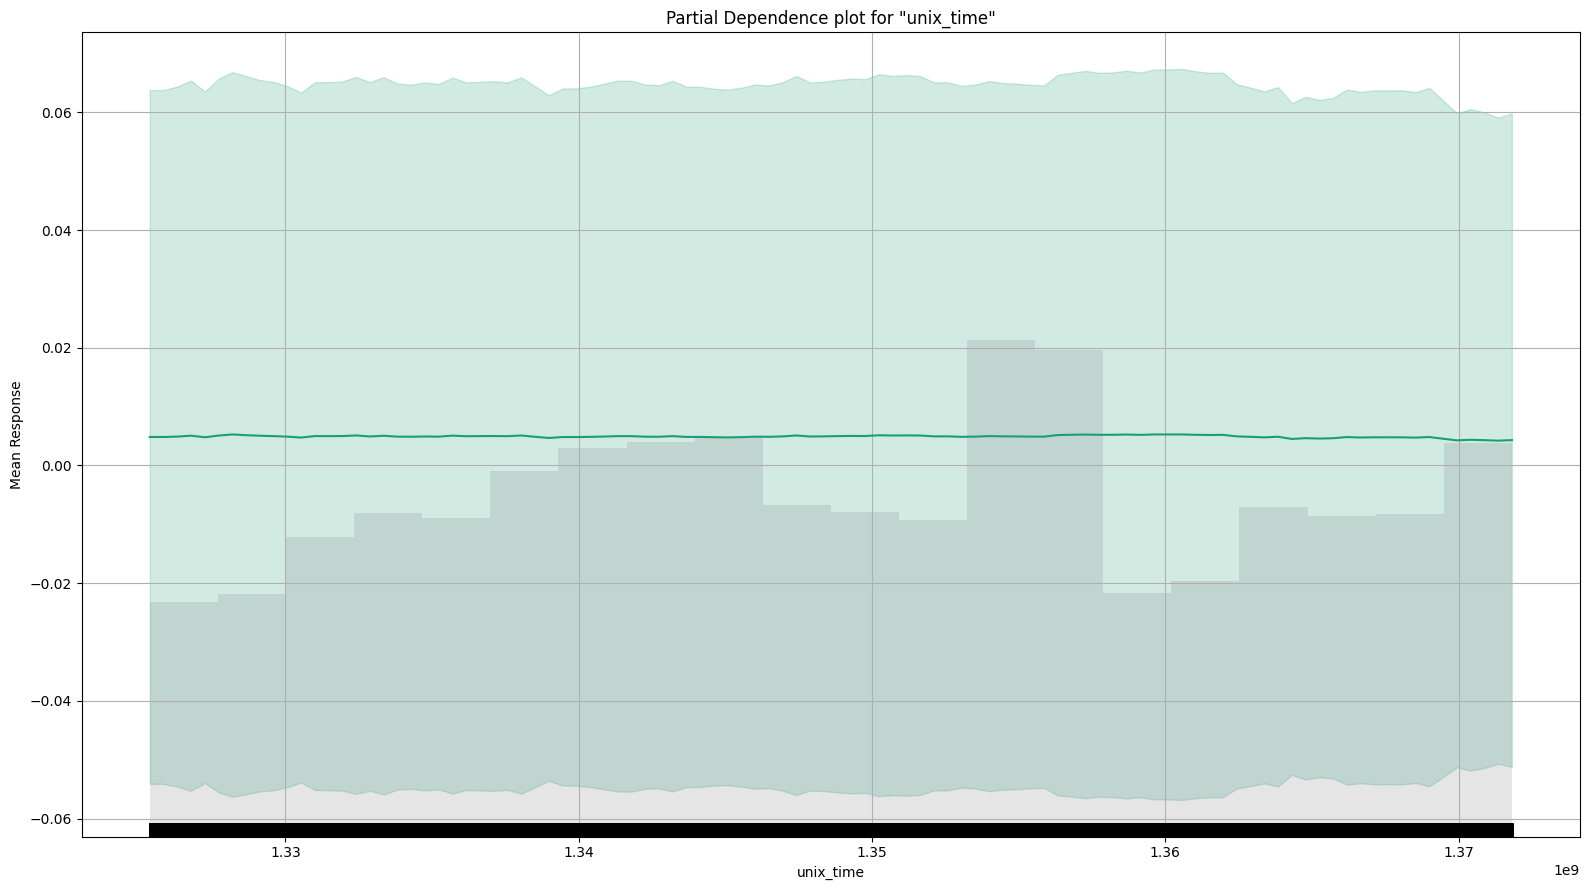

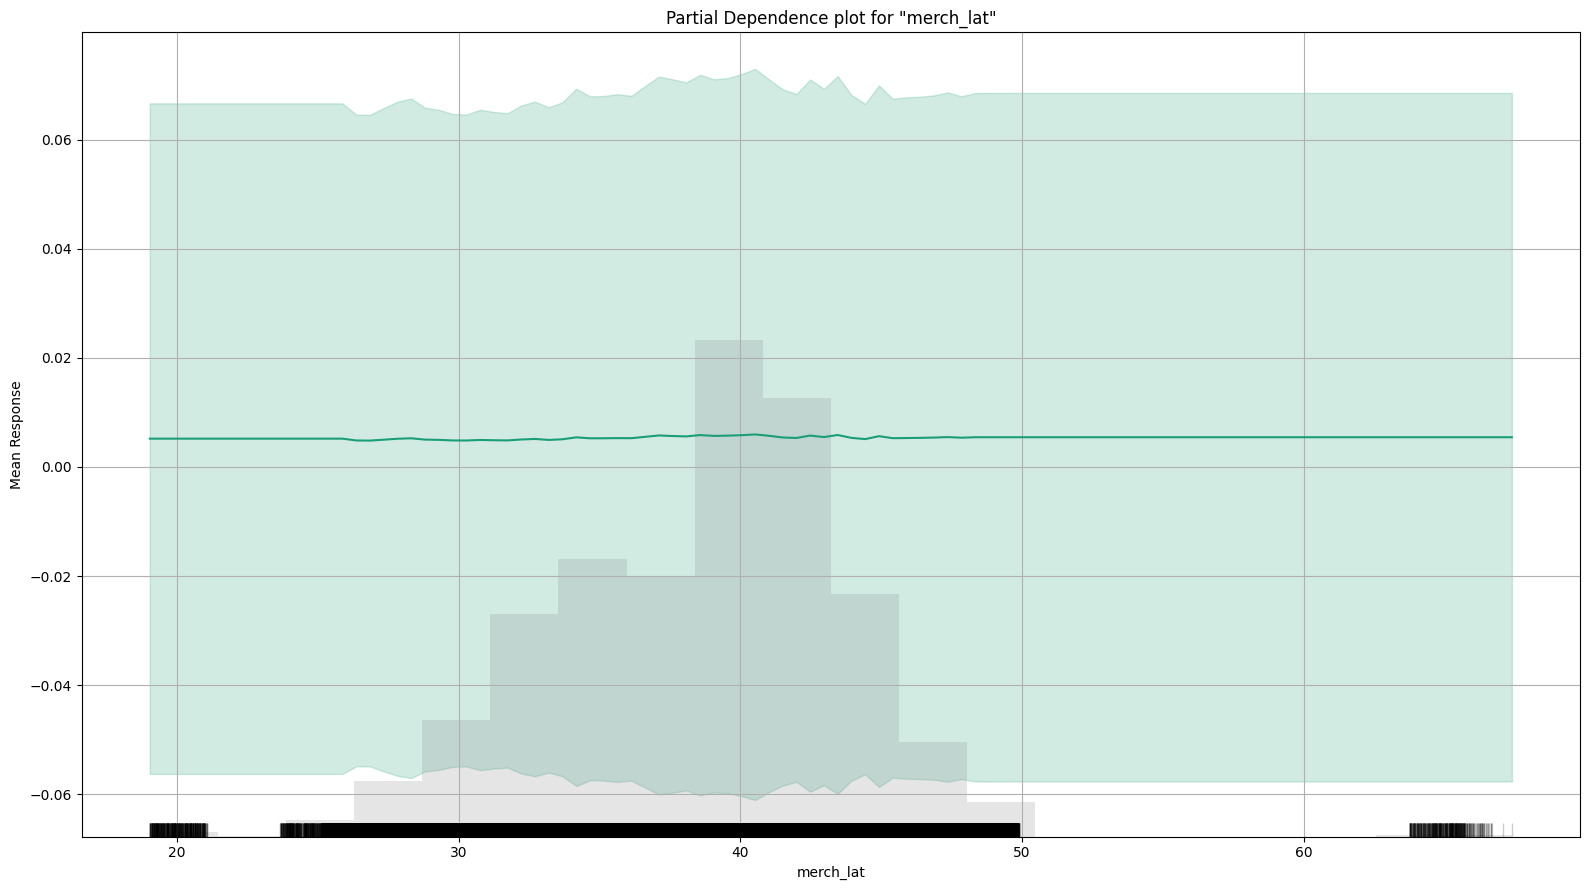

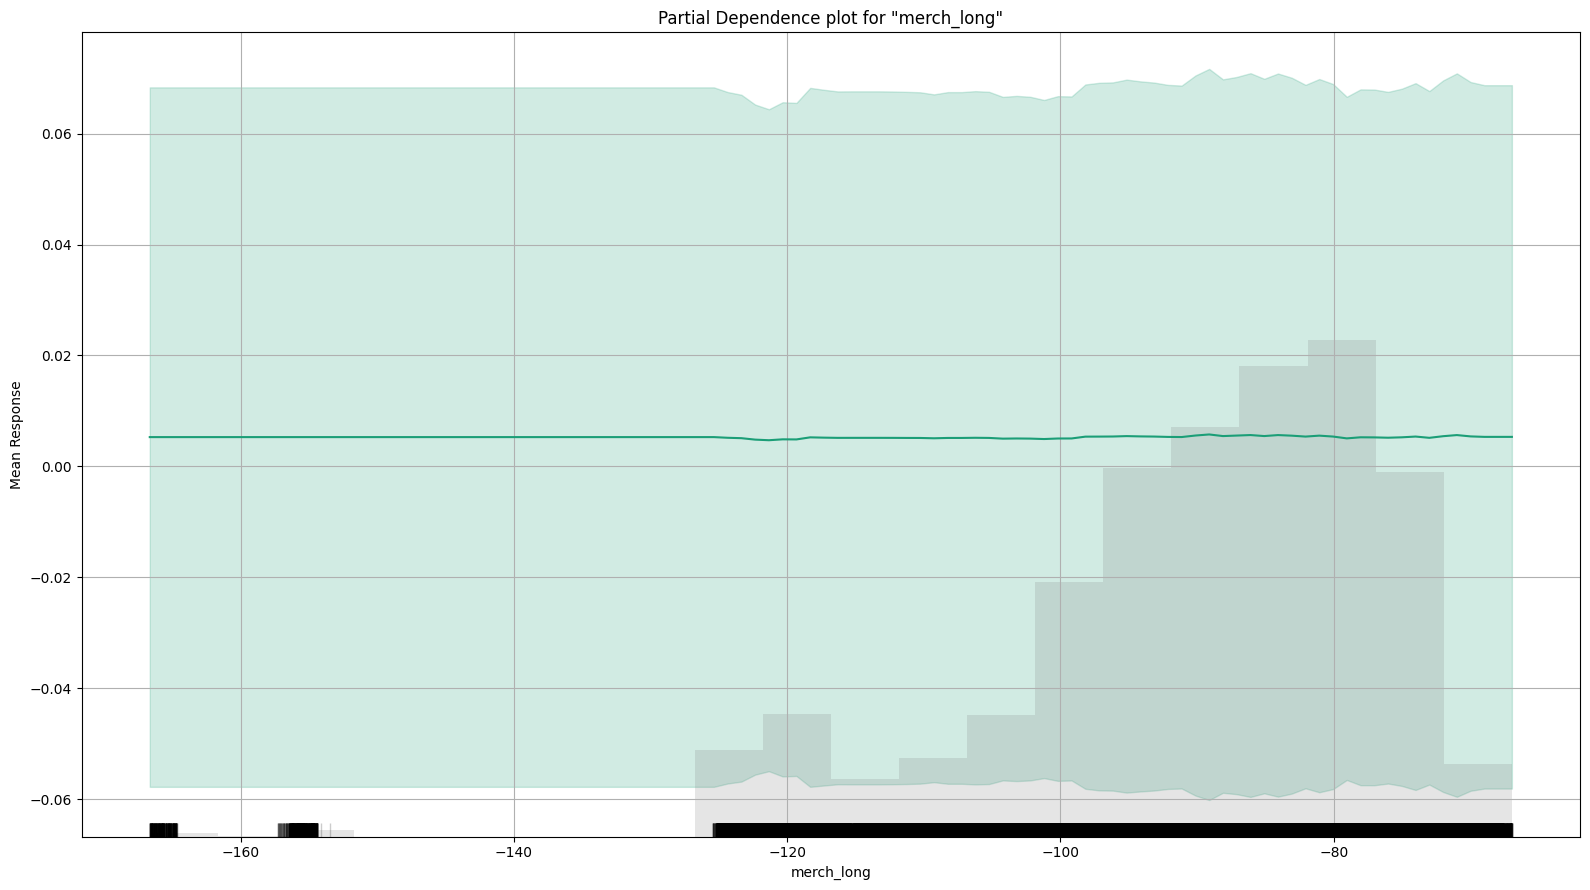

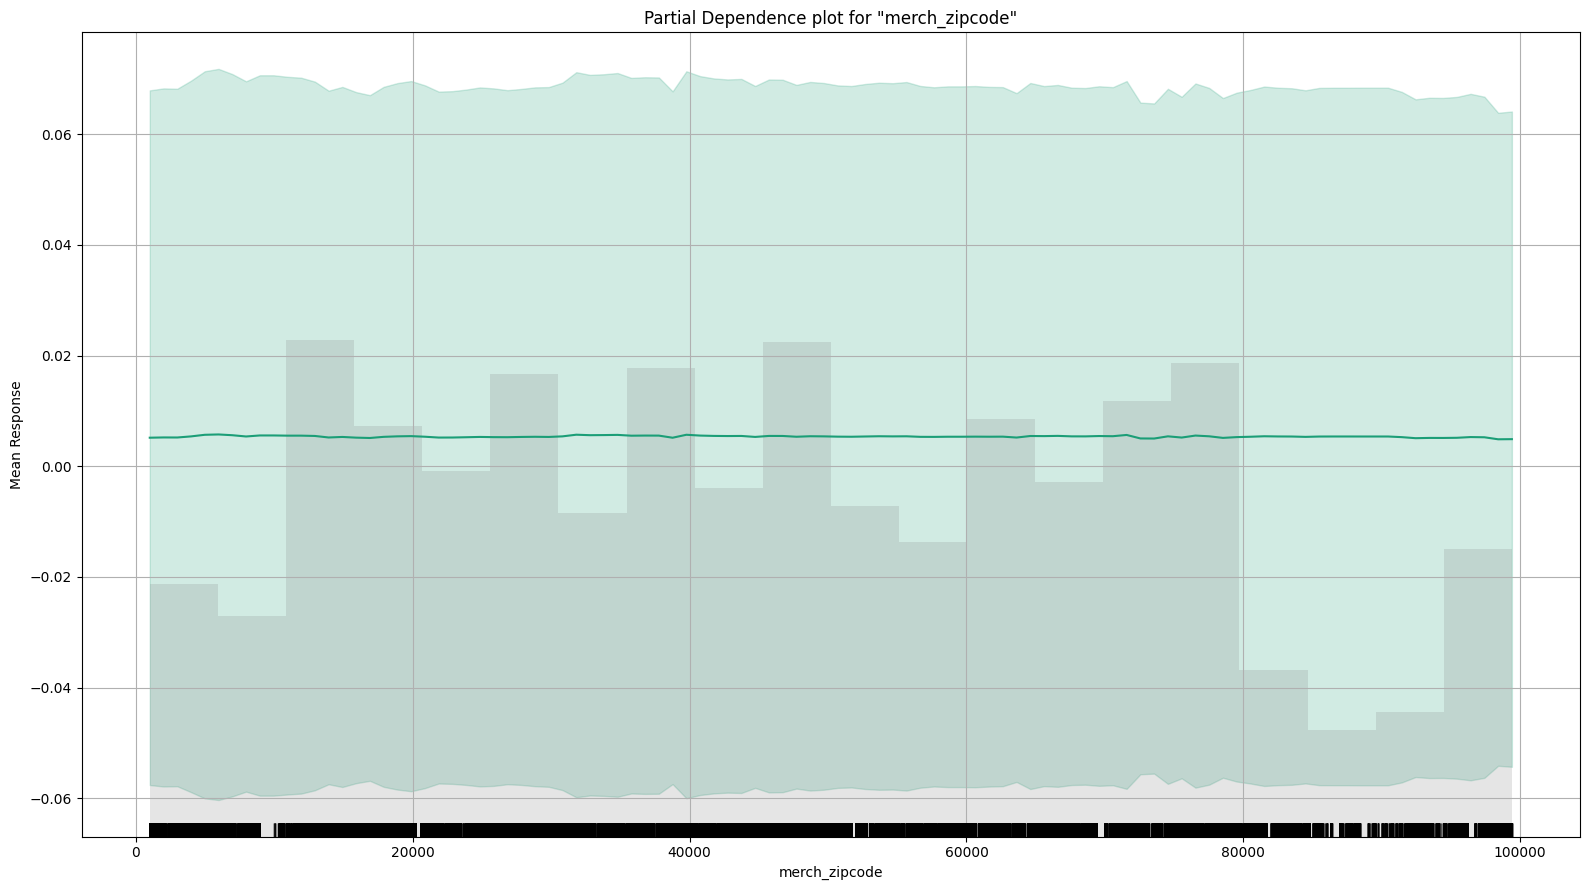

In [6]:
# 리더 모델만 단독 설명
leader = aml.leader
leader.explain(test)

---
## 3. 특정 모델 비교

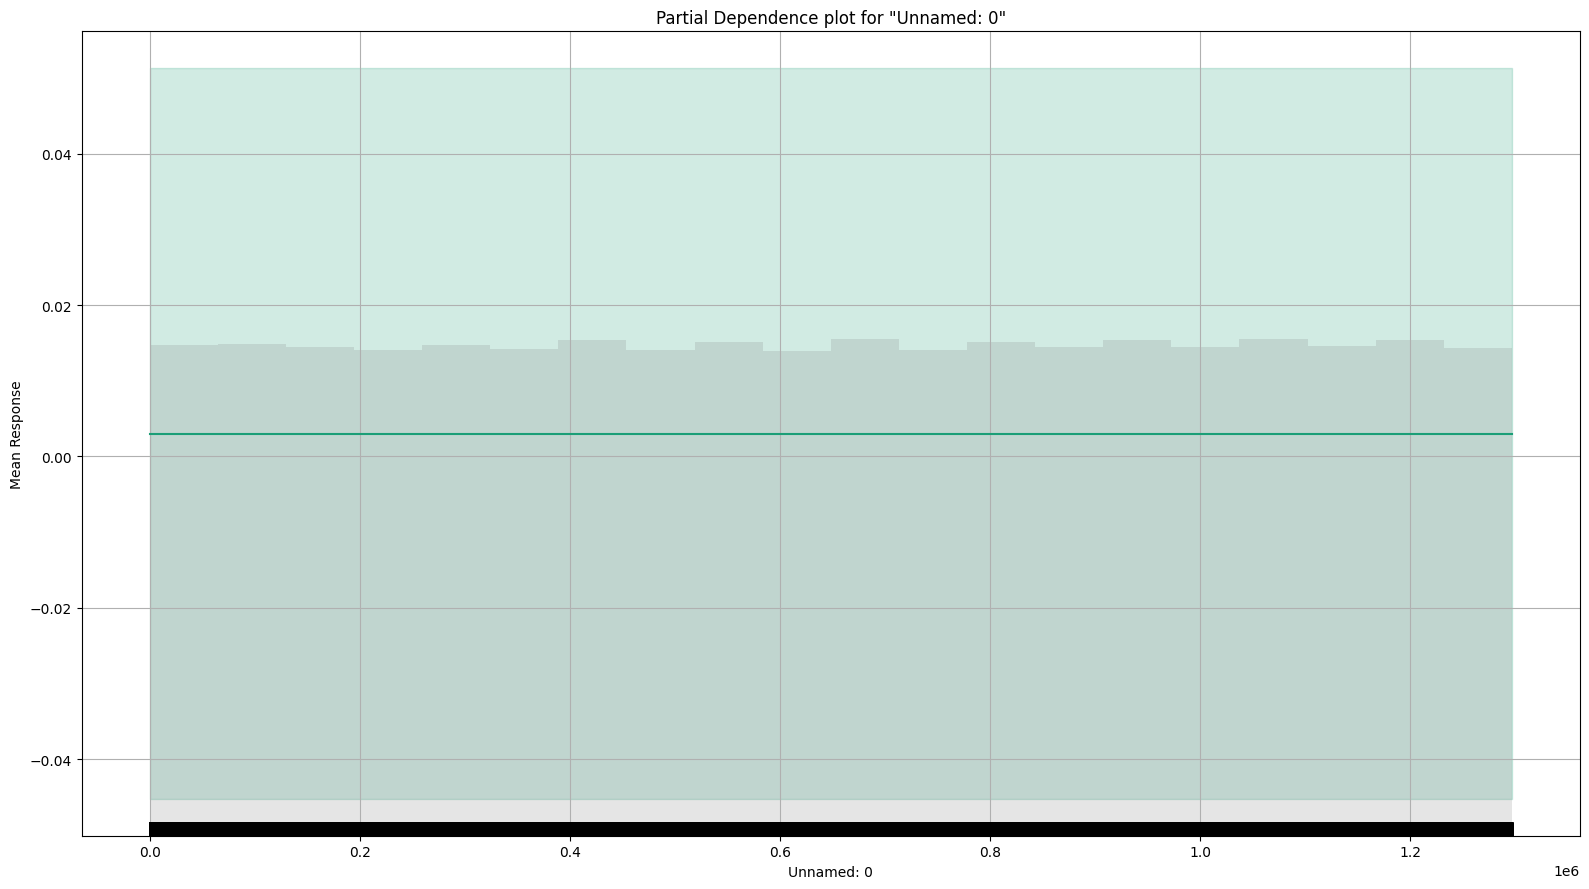

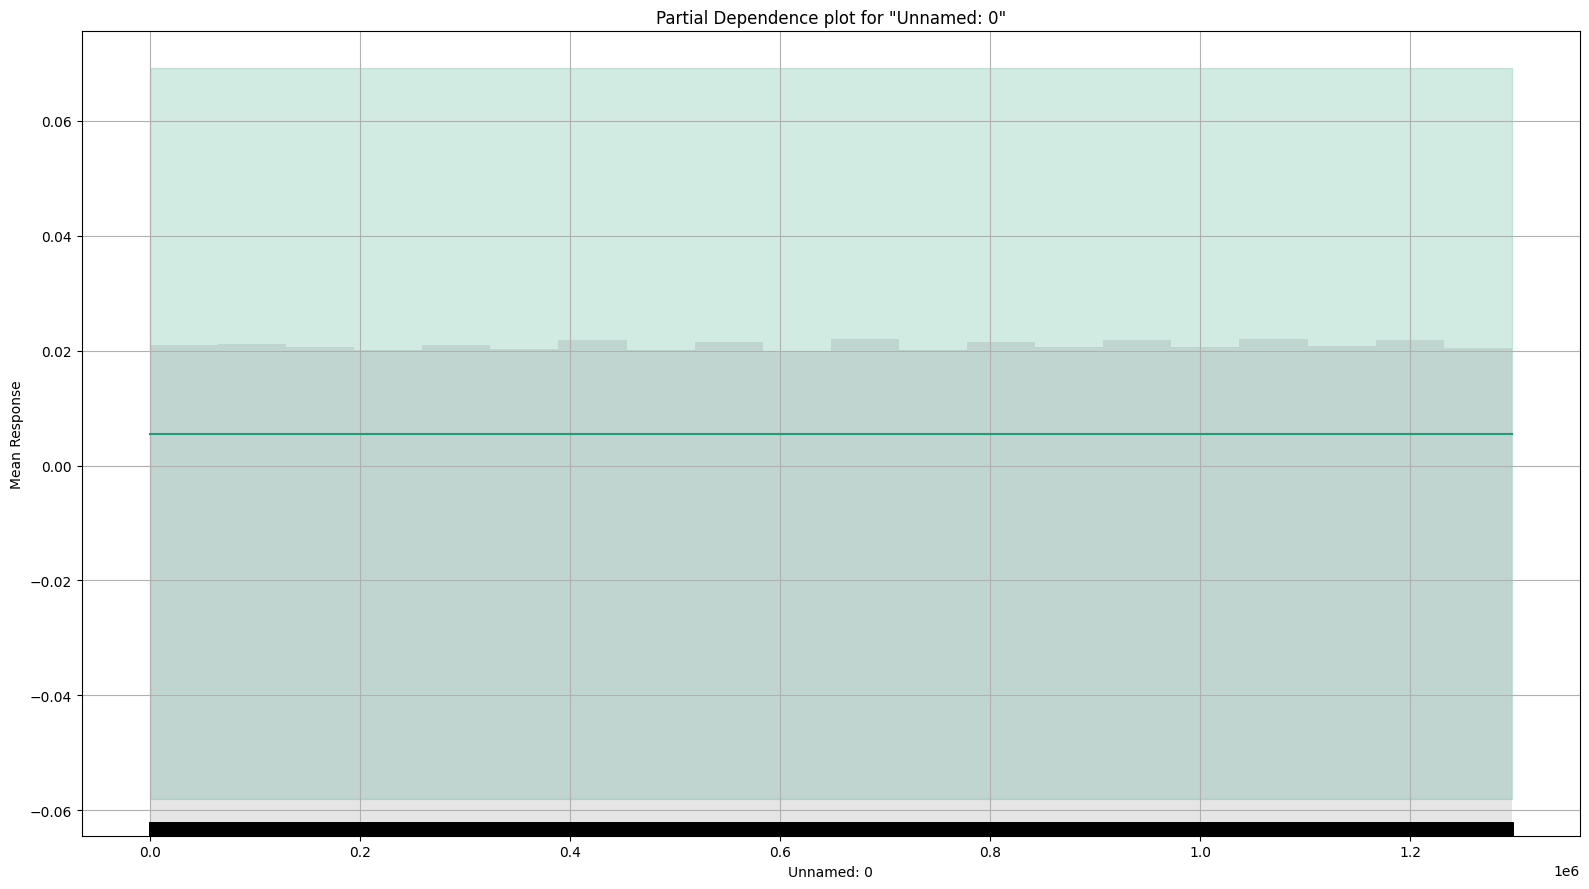

In [7]:
# 특정 알고리즘별 best model 비교
try:
    gbm = aml.get_best_model(algorithm="gbm")
    xgb = aml.get_best_model(algorithm="xgboost")
    
    # Partial Dependence Plot 비교
    gbm.pd_plot(test, column=train.columns[0])
    xgb.pd_plot(test, column=train.columns[0])
except Exception as e:
    print(f"일부 알고리즘이 학습되지 않았을 수 있습니다: {e}")

---
## 정리

H2O Explainability가 제공하는 것:

| 시각화 | 대상 | 용도 |
|--------|------|------|
| Leaderboard | 다중 모델 | 성능 순위 비교 |
| Variable Importance Heatmap | 다중 모델 | 공통 중요 변수 식별 |
| Model Correlation | 다중 모델 | 앙상블 다양성 확인 |
| Partial Dependence | 단일/다중 | 변수-예측 관계 시각화 |
| SHAP Summary | 단일 모델 | 개별 예측에 대한 변수 기여도 |

> **"모델을 자동으로 학습할 뿐 아니라, 왜 그런 예측을 하는지도 자동으로 설명"**
> — 이것이 H2O AutoML의 Explainability입니다.

In [ ]:
# h2o.cluster().shutdown()